# Customer Churn Prediction with Gradient Boosting

## Project Overview
Customer churn is one of the most important business challenges in subscription-based and service-driven industries. When customers leave, companies lose recurring revenue, increase customer acquisition pressure, and often reveal underlying issues in pricing, service quality, support, or engagement.

In this project, I develop a machine learning pipeline to predict whether a telecom customer is likely to churn using the **Telco Customer Churn** dataset. The goal is to identify patterns associated with customer attrition and build a predictive model that can help businesses take proactive retention actions.

The modeling workflow includes:
- data cleaning and preprocessing
- exploratory data analysis
- baseline model benchmarking
- gradient boosting model development
- hyperparameter tuning
- threshold optimization
- feature importance analysis
- business-focused interpretation of results

By the end of the project, I aim not only to build an accurate churn prediction model, but also to translate the results into actionable business recommendations for customer retention strategy.

---

## Business Objective
The primary objective of this project is to build a binary classification model that predicts whether a customer will churn (`Yes`) or stay (`No`).

From a business perspective, such a model can help a company:
- identify high-risk customers before they leave
- improve retention campaign targeting
- reduce revenue loss from attrition
- allocate customer success resources more efficiently

Because the cost of retaining a customer is often lower than the cost of acquiring a new one, churn prediction has direct strategic value.

---

## Dataset
The dataset used in this project is the **Telco Customer Churn** dataset, where:
- each row represents a customer
- each column describes customer attributes, services, account information, or billing details
- the target variable is **`Churn`**

The dataset contains information such as:
- customer tenure
- contract type
- payment method
- monthly and total charges
- internet and phone services
- support and security add-ons

These features allow to study the behavioral and contractual factors most associated with customer churn.

---

## Machine Learning Goal
This project is framed as a **supervised binary classification** task.

So i will:
1. prepare and clean the dataset
2. explore churn patterns across customer segments
3. establish baseline classification models
4. train and tune a **gradient boosting** model
5. evaluate predictive performance using appropriate classification metrics
6. interpret the model to understand the key drivers of churn

Special attention will be given to **recall**, **F1-score**, and **ROC-AUC**, since correctly identifying likely churners is often more valuable than maximizing accuracy alone.

---

## Why This Project Matters
This project is designed to strengthen an applied machine learning portfolio by demonstrating:
- practical tabular data preprocessing
- structured exploratory analysis
- modern classification modeling
- model comparison and tuning
- business-aware evaluation
- interpretable machine learning insights



## Notebook Roadmap

This notebook is organized into the following sections:

1. **Imports and Setup**  
   Load libraries, configure display settings, and prepare the environment.

2. **Data Loading and Inspection**  
   Load the dataset and examine its structure, data types, and initial quality.

3. **Data Cleaning and Preprocessing**  
   Resolve data issues, prepare the target variable, and build preprocessing foundations.

4. **Exploratory Data Analysis**  
   Analyze churn distribution and investigate relationships between customer attributes and churn.

5. **Modeling Strategy**  
   Define the train-test split, preprocessing pipeline, and evaluation metrics.

6. **Baseline Models**  
   Benchmark simpler classification models for comparison.

7. **Gradient Boosting Modeling**  
   Train and evaluate the main gradient boosting model.

8. **Hyperparameter Tuning and Threshold Optimization**  
   Improve predictive performance and align model behavior with business priorities.

9. **Model Interpretation**  
   Examine feature importance and key churn drivers.

10. **Business Recommendations and Final Conclusion**  
    Translate modeling results into actionable retention insights.

# 1. Imports and Setup

In this section, we import the libraries required for data manipulation, visualization, preprocessing, modeling, and evaluation. We also configure the notebook environment to improve readability and reproducibility.

The project relies on:
- **pandas** and **NumPy** for data handling
- **Matplotlib** and **Seaborn** for visualization
- **scikit-learn** for preprocessing, pipelines, model evaluation, and baseline models
- **XGBoost** for advanced gradient boosting classification

To keep results reproducible, we also define a fixed random seed and set display options for cleaner notebook output.

In [5]:
# Optional: install XGBoost in Colab if needed
# !pip install xgboost -q

In [6]:
# ============================================================
# Block 1: Imports and Setup
# ============================================================

# Core libraries
import warnings
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: preprocessing and pipelines
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    cross_validate,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV
)

# Scikit-learn: baseline models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Scikit-learn: metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Gradient boosting model
from xgboost import XGBClassifier

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

# Plot settings
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Warning control
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")
print(f"Random state set to: {RANDOM_STATE}")

Libraries imported successfully.
Random state set to: 42


### Reproducibility Note
A fixed random seed is used throughout the notebook to ensure that train-test splitting, model training, and evaluation results remain consistent across runs. This is an important practice in applied machine learning, especially when comparing models and tuning hyperparameters.

## Environment and Project Paths

Since this notebook is developed in Google Colab and the project files are stored in Google Drive, we first mount Drive and define reusable project paths. This ensures that the dataset, exported figures, and other project assets can be accessed consistently throughout the workflow.

Using centralized paths improves notebook organization, reduces path-related errors, and makes the project easier to maintain and reproduce.

In [7]:
# ============================================================
# Google Drive Mount
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# ============================================================
# Project Paths
# ============================================================

PROJECT_DIR = "/content/drive/MyDrive/ML Portfolio/customer-churn-prediction-gradient-boosting"
DATA_DIR = f"{PROJECT_DIR}/data"
FIGURES_DIR = f"{PROJECT_DIR}/figures"
NOTEBOOKS_DIR = f"{PROJECT_DIR}/notebooks"

file_path = f"{DATA_DIR}/WA_Fn-UseC_-Telco-Customer-Churn.csv"

print("Project directories configured successfully.")
print(f"Project directory: {PROJECT_DIR}")
print(f"Data directory: {DATA_DIR}")
print(f"Figures directory: {FIGURES_DIR}")
print(f"Notebook directory: {NOTEBOOKS_DIR}")
print(f"Dataset path: {file_path}")

Project directories configured successfully.
Project directory: /content/drive/MyDrive/ML Portfolio/customer-churn-prediction-gradient-boosting
Data directory: /content/drive/MyDrive/ML Portfolio/customer-churn-prediction-gradient-boosting/data
Figures directory: /content/drive/MyDrive/ML Portfolio/customer-churn-prediction-gradient-boosting/figures
Notebook directory: /content/drive/MyDrive/ML Portfolio/customer-churn-prediction-gradient-boosting/notebooks
Dataset path: /content/drive/MyDrive/ML Portfolio/customer-churn-prediction-gradient-boosting/data/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [9]:
# Verify that the dataset file exists
import os

print("Does dataset file exist?", os.path.exists(file_path))

Does dataset file exist? True


# 2. Data Loading and Initial Inspection

In this section, we load the Telco Customer Churn dataset and perform an initial structural inspection. The goal is to verify the shape of the dataset, review feature names and data types, preview representative records, and detect any early data quality issues that may affect preprocessing and modeling.

A disciplined first inspection helps identify:
- the target variable and feature space
- identifier columns that should not be modeled
- the mix of numerical and categorical variables
- missing values, duplicate records, or formatting inconsistencies

This step establishes the analytical foundation for the data cleaning and exploratory analysis stages that follow.

In [10]:
# ============================================================
# Block 2: Data Loading and Initial Inspection
# ============================================================

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded successfully.
Dataset shape: 7043 rows, 21 columns


In [11]:
# Preview the first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
# Inspect column names and data types
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:


,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [13]:
# General dataset information
print("Dataset info:")
df.info()

# Standard missing value check
print("\nMissing values by column:")
missing_values = df.isnull().sum().sort_values(ascending=False)
display(missing_values[missing_values > 0])

# Duplicate row check
duplicate_count = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicate_count}")

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

,0



Duplicate rows: 0


In [14]:
# Descriptive statistics for numerical and categorical variables
print("Numerical feature summary:")
display(df.describe())

print("\nCategorical feature summary:")
display(df.describe(include="object"))

Numerical feature summary:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75



Categorical feature summary:


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [15]:
# Structural overview of feature types
categorical_cols = df.select_dtypes(include="object").columns.tolist()
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Structural summary:")
print(f"- Number of rows: {df.shape[0]}")
print(f"- Number of columns: {df.shape[1]}")
print(f"- Categorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"- Numerical columns ({len(numerical_cols)}): {numerical_cols}")

Structural summary:
- Number of rows: 7043
- Number of columns: 21
- Categorical columns (18): ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']
- Numerical columns (3): ['SeniorCitizen', 'tenure', 'MonthlyCharges']


In [16]:
# Inspect target variable distribution
print("Target distribution preview:")
display(df["Churn"].value_counts(dropna=False))

Target distribution preview:


,count
Churn,
No,5174
Yes,1869


In [17]:
# Check for blank-string entries in TotalCharges
blank_total_charges = (df["TotalCharges"].str.strip() == "").sum()
print(f"Blank-string entries in 'TotalCharges': {blank_total_charges}")

Blank-string entries in 'TotalCharges': 11


### Initial Observations

The initial inspection confirms that the dataset is well-structured for a binary classification task, containing **7,043 customer records** and **21 columns**. The target variable is **`Churn`**, which indicates whether a customer left the telecom service.

Several important findings emerge from this first review:

- The dataset contains **no duplicate rows**, which suggests that each record represents a unique customer observation.
- A standard null-value check shows **no explicit missing values**, but this does **not** mean the dataset is fully clean.
- The column **`TotalCharges`** is currently stored as **`object`** rather than a numeric type, which is inconsistent with its meaning as a billing variable.
- The categorical summary indicates that **blank strings are present in `TotalCharges`**, suggesting the existence of **hidden missing values** that were not captured by the standard null check.
- The column **`customerID`** is unique for each row and therefore functions as an identifier rather than a meaningful predictive feature.
- The dataset contains a mixture of **categorical** and **numerical** variables, meaning that preprocessing will need to handle mixed data types appropriately.
- The target variable is **moderately imbalanced**, with substantially more non-churning customers than churning customers. This means model evaluation should go beyond accuracy and place emphasis on metrics such as **recall**, **F1-score**, and **ROC-AUC**.

Overall, the dataset appears suitable for churn modeling, but several preprocessing steps are required before analysis and model development. In particular, the next stage should focus on handling hidden missing values in **`TotalCharges`**, converting it to a numeric format, removing the customer identifier column, and preparing the target variable for modeling.

# 3. Data Cleaning and Preprocessing Foundations

In this section, we address the key data quality and preprocessing issues identified during the initial inspection. Although the dataset appears complete under a standard null-value check, a closer review suggests that some missing information may be encoded as blank strings rather than explicit nulls.

The main objectives of this stage are to:
- identify and quantify hidden missing values
- convert incorrectly typed variables into appropriate numerical formats
- remove identifier columns that should not be used for prediction
- prepare the target variable for binary classification modeling

A careful cleaning step is essential because even small inconsistencies in data types or missing-value representation can affect exploratory analysis, model training, and evaluation.

In [18]:
# ============================================================
# Block 3: Data Cleaning and Preprocessing Foundations
# ============================================================

# Create a working copy of the dataset
df_clean = df.copy()

print("Working copy created successfully.")
print(f"Initial shape: {df_clean.shape}")

Working copy created successfully.
Initial shape: (7043, 21)


In [19]:
# Inspect blank-string entries in TotalCharges
blank_total_charges = (df_clean["TotalCharges"].astype(str).str.strip() == "").sum()

print(f"Blank-string entries in 'TotalCharges': {blank_total_charges}")

Blank-string entries in 'TotalCharges': 11


In [20]:
# Display rows where TotalCharges is blank
blank_total_charges_rows = df_clean[df_clean["TotalCharges"].astype(str).str.strip() == ""]

print("Rows with blank 'TotalCharges':")
display(blank_total_charges_rows.head())

print(f"Number of rows with blank 'TotalCharges': {blank_total_charges_rows.shape[0]}")

Rows with blank 'TotalCharges':


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No


Number of rows with blank 'TotalCharges': 11


In [21]:
# Convert TotalCharges to numeric, coercing blank strings to NaN
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")

print("Conversion completed.")
print("\nUpdated data types:")
display(df_clean.dtypes)

Conversion completed.

Updated data types:


,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [22]:
# Check missing values after converting TotalCharges
missing_after_conversion = df_clean.isnull().sum().sort_values(ascending=False)

print("Missing values after converting 'TotalCharges' to numeric:")
display(missing_after_conversion[missing_after_conversion > 0])

Missing values after converting 'TotalCharges' to numeric:


,0
TotalCharges,11


### Missing-Value Handling Strategy

After converting **`TotalCharges`** to a numeric type, previously hidden blank-string entries become explicit missing values (`NaN`). These rows represent a very small portion of the dataset.

Because the number of affected observations is minimal relative to the full dataset, and because `TotalCharges` is an important billing feature for churn analysis, the most practical approach is to remove these incomplete records rather than introduce unnecessary imputation noise at this early stage.

This decision keeps the dataset clean while preserving the integrity of downstream analysis and modeling.

In [23]:
# Drop rows with missing TotalCharges
rows_before = df_clean.shape[0]

df_clean = df_clean.dropna(subset=["TotalCharges"]).copy()

rows_after = df_clean.shape[0]
rows_removed = rows_before - rows_after

print(f"Rows before dropping missing TotalCharges: {rows_before}")
print(f"Rows after dropping missing TotalCharges: {rows_after}")
print(f"Rows removed: {rows_removed}")

Rows before dropping missing TotalCharges: 7043
Rows after dropping missing TotalCharges: 7032
Rows removed: 11


In [24]:
# Optional: inspect characteristics of rows with missing TotalCharges
print("Summary of rows removed due to missing TotalCharges:")
display(blank_total_charges_rows[["tenure", "MonthlyCharges", "Contract", "Churn"]].head(10))

Summary of rows removed due to missing TotalCharges:


,tenure,MonthlyCharges,Contract,Churn
488,0,52.55,Two year,No
753,0,20.25,Two year,No
936,0,80.85,Two year,No
1082,0,25.75,Two year,No
1340,0,56.05,Two year,No
3331,0,19.85,Two year,No
3826,0,25.35,Two year,No
4380,0,20.00,Two year,No
5218,0,19.70,One year,No
6670,0,73.35,Two year,No


In [25]:
# Remove customerID because it is a unique identifier, not a predictive feature
df_clean = df_clean.drop(columns=["customerID"])

print("'customerID' column removed successfully.")
print(f"Updated shape: {df_clean.shape}")

'customerID' column removed successfully.
Updated shape: (7032, 20)


In [26]:
# Encode target variable: Yes -> 1, No -> 0
df_clean["Churn"] = df_clean["Churn"].map({"Yes": 1, "No": 0})

print("Target variable encoded successfully.")
print("\nEncoded target distribution:")
display(df_clean["Churn"].value_counts())

Target variable encoded successfully.

Encoded target distribution:


,count
Churn,
0,5163
1,1869


In [27]:
# Final quality check after cleaning
print("Final dataset info after cleaning:")
df_clean.info()

print("\nRemaining missing values:")
remaining_missing = df_clean.isnull().sum().sort_values(ascending=False)
display(remaining_missing[remaining_missing > 0])

print("\nPreview of cleaned dataset:")
display(df_clean.head())

#df_clean = df_clean.reset_index(drop=True)

Final dataset info after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMetho

,0



Preview of cleaned dataset:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [28]:
# Compare dataset dimensions before and after cleaning
print("Dataset comparison:")
print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape: {df_clean.shape}")

Dataset comparison:
Original dataset shape: (7043, 21)
Cleaned dataset shape: (7032, 20)


### Cleaning Results and Preprocessing Readiness

The cleaning stage revealed a small but important data quality issue that required correction before analysis and modeling.

Key preprocessing outcomes:

- The variable **`TotalCharges`** was originally stored as a text field, despite representing a continuous billing-related feature.
- A closer inspection identified **11 blank-string entries** in **`TotalCharges`**, which were not captured by the standard null-value check.
- After converting **`TotalCharges`** to numeric format, these blank entries became explicit missing values.
- Because the number of affected observations was very small relative to the full dataset, these **11 incomplete rows** were removed without materially affecting the dataset.
- The removed records were associated with customers having **zero tenure**, which is consistent with newly joined customers whose total charges had not yet accumulated.
- The identifier column **`customerID`** was dropped because it does not provide meaningful predictive information.
- The target variable **`Churn`** was encoded into binary format, with **`1` representing churn** and **`0` representing non-churn**.

After cleaning, the dataset contains **7,032 rows and 20 columns**, with no remaining missing values. At this point, the data is structurally consistent and ready for exploratory data analysis and machine learning modeling.

# 4. Exploratory Data Analysis

In this section, we explore the cleaned dataset to better understand the patterns associated with customer churn. The goal of exploratory data analysis is not only to summarize the data, but also to uncover relationships that may be useful for feature interpretation, model development, and business decision-making.

This stage focuses on:
- the distribution of the target variable
- the behavior of key numerical features
- the relationship between categorical customer attributes and churn
- early business insights that may help explain why customers leave

A strong exploratory analysis is especially important in churn prediction because it helps connect model outputs to real customer behavior, making the final results more interpretable and actionable.

In [29]:
# ============================================================
# Block 4: Exploratory Data Analysis
# ============================================================

# Create a reusable churn label mapping for clearer plots
churn_label_map = {0: "No Churn", 1: "Churn"}
df_eda = df_clean.copy()
df_eda["ChurnLabel"] = df_eda["Churn"].map(churn_label_map)

print("EDA dataset prepared successfully.")
print(f"EDA dataset shape: {df_eda.shape}")

EDA dataset prepared successfully.
EDA dataset shape: (7032, 21)


In [30]:
# Figure saving configuration
SAVE_FIGURES = True

print(f"Figure saving enabled: {SAVE_FIGURES}")
print(f"Figures will be saved to: {FIGURES_DIR}")

Figure saving enabled: True
Figures will be saved to: /content/drive/MyDrive/ML Portfolio/customer-churn-prediction-gradient-boosting/figures


## 4.1 Target Variable Distribution

We begin by examining the class distribution of the target variable. In churn prediction, understanding whether the classes are balanced is important because an imbalanced target can make accuracy misleading and may require greater emphasis on metrics such as recall, F1-score, and ROC-AUC.

In [31]:
# Target distribution: counts and proportions
churn_counts = df_eda["ChurnLabel"].value_counts()
churn_percentages = df_eda["ChurnLabel"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "Count": churn_counts,
    "Percentage": churn_percentages.round(2)
})

display(target_summary)

,Count,Percentage
ChurnLabel,,
No Churn,5163,73.42
Churn,1869,26.58


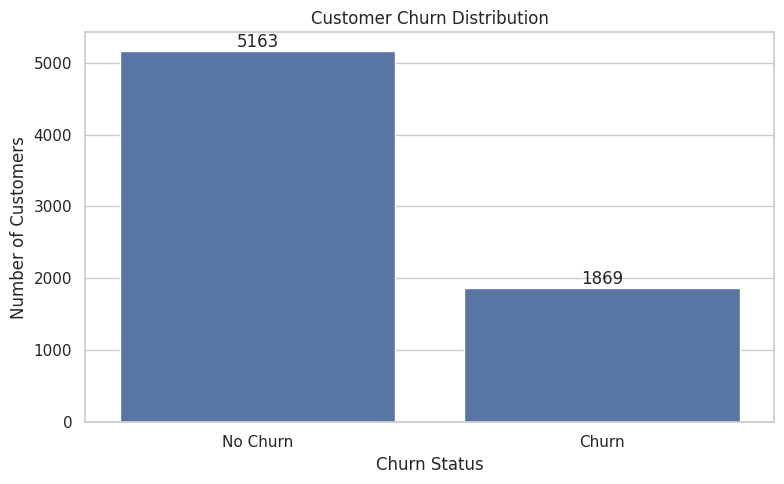

In [32]:
# Plot target distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_eda, x="ChurnLabel")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

if SAVE_FIGURES:
    plt.savefig(f"{FIGURES_DIR}/target_distribution.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

### Interpretation

The target distribution shows that the dataset contains **5,163 non-churning customers (73.42%)** and **1,869 churning customers (26.58%)**. This confirms that the target variable is **moderately imbalanced**, with the majority class corresponding to customers who remained with the company.

This class structure has important implications for modeling. A classifier could achieve relatively high accuracy by favoring the majority class, but such a model would be less useful from a business standpoint if it fails to identify customers who are actually at risk of leaving. For that reason, model evaluation in later stages should emphasize not only **accuracy**, but also **recall**, **F1-score**, **ROC-AUC**, and potentially **precision-recall trade-offs**.

From a business perspective, the imbalance is also realistic: in most telecom settings, only a minority of customers churn within a given observation window. This makes churn prediction a meaningful early-warning problem rather than a simple balanced classification task.

## 4.2 Numerical Feature Analysis

Next, we examine the main numerical features in the dataset: **tenure**, **MonthlyCharges**, and **TotalCharges**. These variables are especially important because they capture customer lifetime, recurring billing intensity, and accumulated revenue contribution.

Analyzing their distributions and comparing them across churn groups can reveal whether churn is concentrated among newer customers, higher-paying customers, or customers with lower long-term engagement.

In [33]:
# Summary statistics for numerical features by churn status
numerical_features = ["tenure", "MonthlyCharges", "TotalCharges"]

numerical_summary_by_churn = df_eda.groupby("ChurnLabel")[numerical_features].agg(["mean", "median", "std"])
display(numerical_summary_by_churn.round(2))

tenure              MonthlyCharges              TotalCharges  \
             mean median   std           mean median   std         mean   
ChurnLabel                                                                
Churn       17.98  10.00 19.53          74.44  79.65 24.67      1531.80   
No Churn    37.65  38.00 24.08          61.31  64.45 31.09      2555.34   

                            
            median     std  
ChurnLabel                  
Churn       703.55 1890.82  
No Churn   1683.60 2329.46

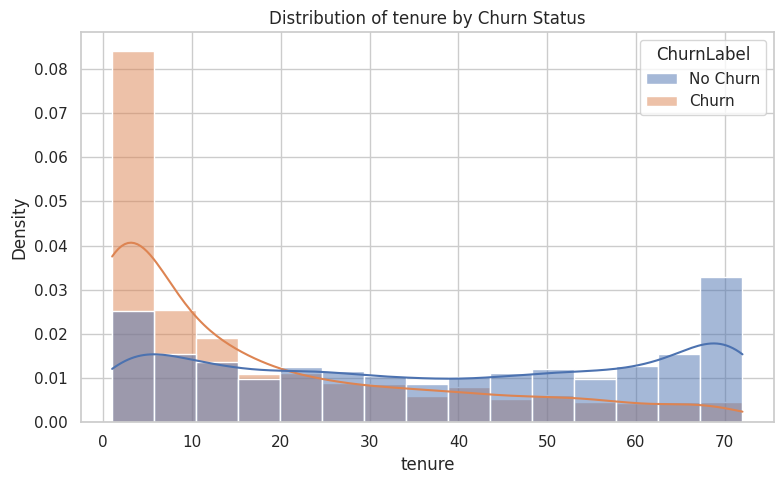

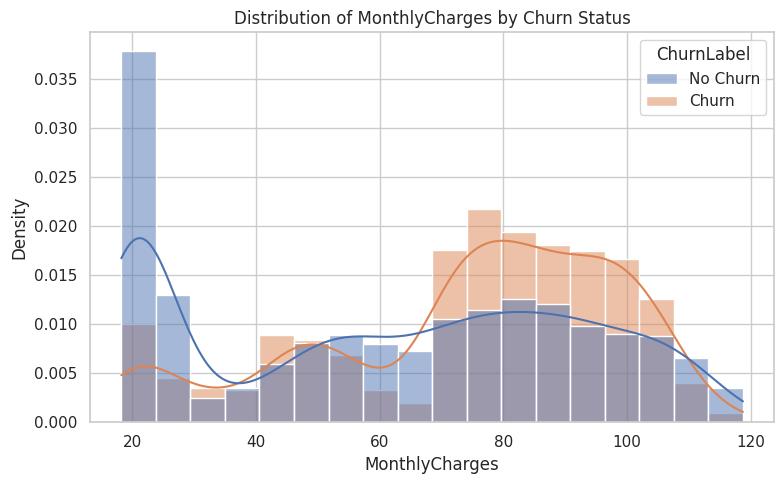

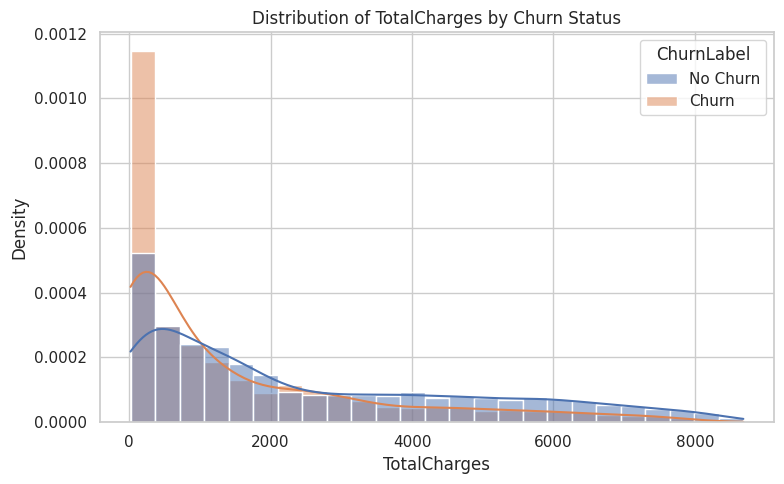

In [34]:
# Histograms for key numerical features
for feature in numerical_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(
        data=df_eda,
        x=feature,
        hue="ChurnLabel",
        kde=True,
        stat="density",
        common_norm=False
    )
    plt.title(f"Distribution of {feature} by Churn Status")
    plt.xlabel(feature)
    plt.ylabel("Density")

    if SAVE_FIGURES and feature == "tenure":
        plt.savefig(f"{FIGURES_DIR}/tenure_distribution_by_churn.png", dpi=300, bbox_inches="tight")
    elif SAVE_FIGURES and feature == "MonthlyCharges":
        plt.savefig(f"{FIGURES_DIR}/monthly_charges_distribution_by_churn.png", dpi=300, bbox_inches="tight")
    elif SAVE_FIGURES and feature == "TotalCharges":
        plt.savefig(f"{FIGURES_DIR}/total_charges_distribution_by_churn.png", dpi=300, bbox_inches="tight")

    plt.tight_layout()
    plt.show()

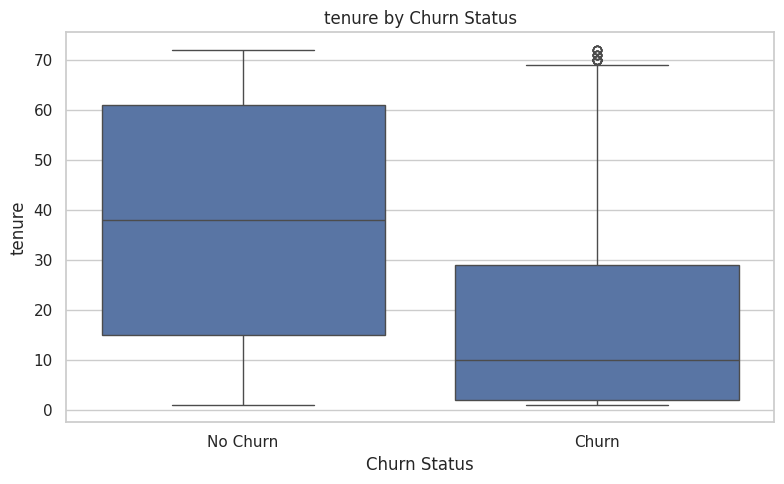

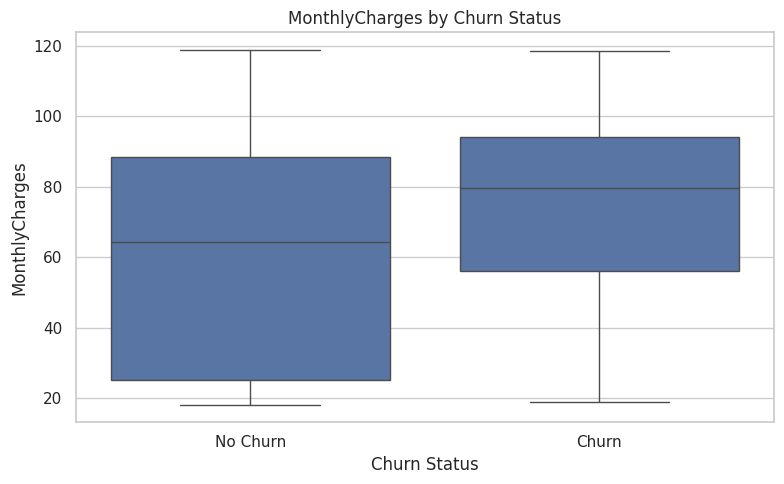

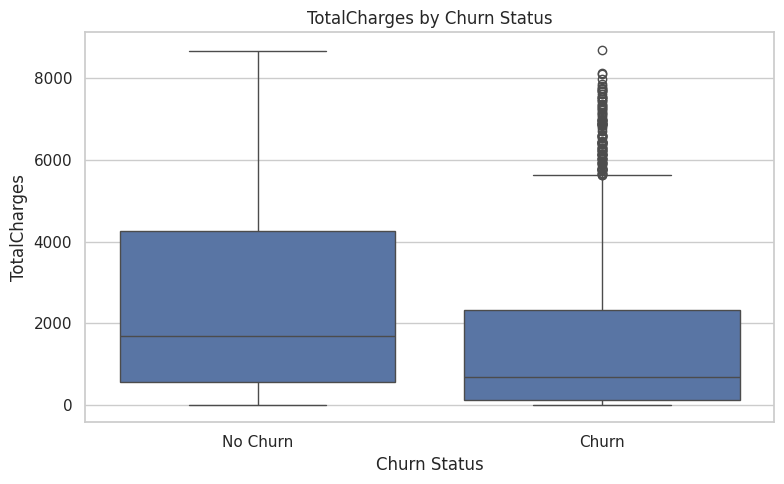

In [35]:
# Boxplots for numerical features by churn status
for feature in numerical_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df_eda, x="ChurnLabel", y=feature)
    plt.title(f"{feature} by Churn Status")
    plt.xlabel("Churn Status")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

### Interpretation

The numerical analysis reveals clear differences between churned and retained customers.

Several patterns stand out:

- Customers who churned have a **much lower average tenure** (**17.98 months**) than customers who stayed (**37.65 months**), strongly suggesting that early-life customers are significantly more vulnerable to attrition.
- Churned customers show a **higher average monthly charge** (**74.44**) than non-churned customers (**61.31**), which may indicate that pricing pressure, perceived value mismatch, or premium-service dissatisfaction plays a role in churn behavior.
- Churned customers have a **substantially lower average total charge** (**1531.80**) than retained customers (**2555.34**). This is consistent with the tenure pattern: customers who leave tend to do so earlier, before accumulating substantial lifetime revenue.

The visual distributions reinforce these findings. The tenure plots show a strong concentration of churn among customers with short service duration, while the charge distributions suggest that churn is more common among customers facing relatively higher monthly costs but with shorter long-term billing histories.

Taken together, these features appear to carry strong predictive signal. In particular, **tenure** appears to be one of the most important business and modeling variables in the dataset.

## 4.3 Categorical Feature Overview

The dataset contains a large number of categorical variables related to service configuration, customer profile, contract structure, and payment behavior. These variables are central to churn analysis because they often capture the business conditions under which customers are more likely to leave.

In this subsection, we inspect the distribution of selected high-value categorical features and then compare churn rates across categories.

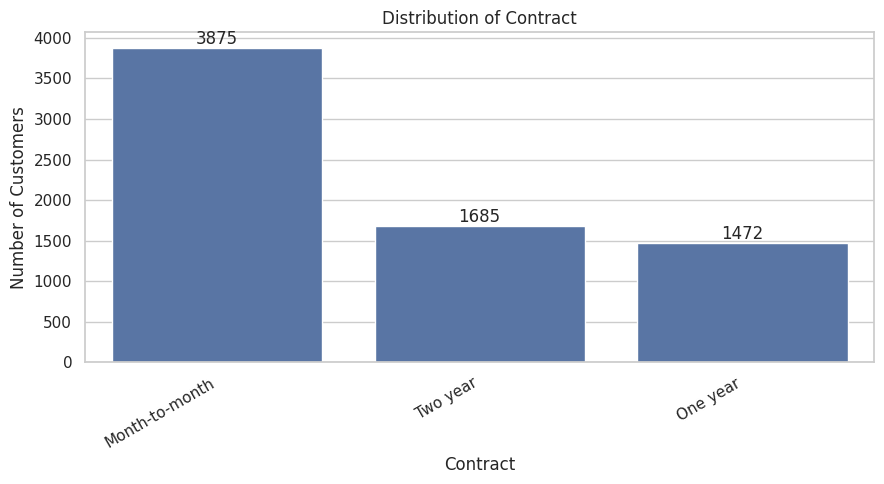

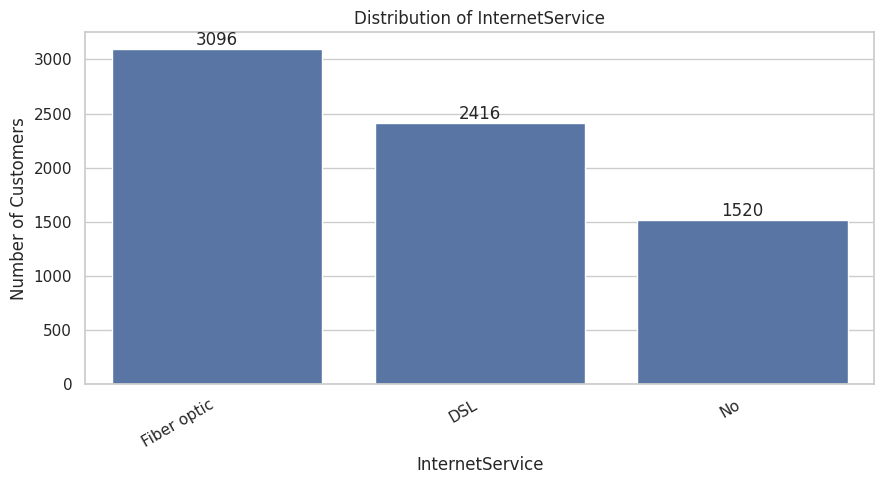

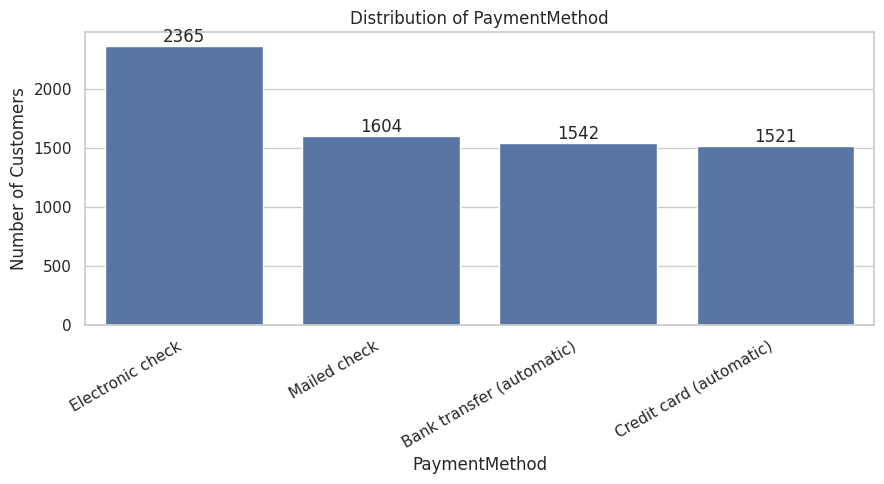

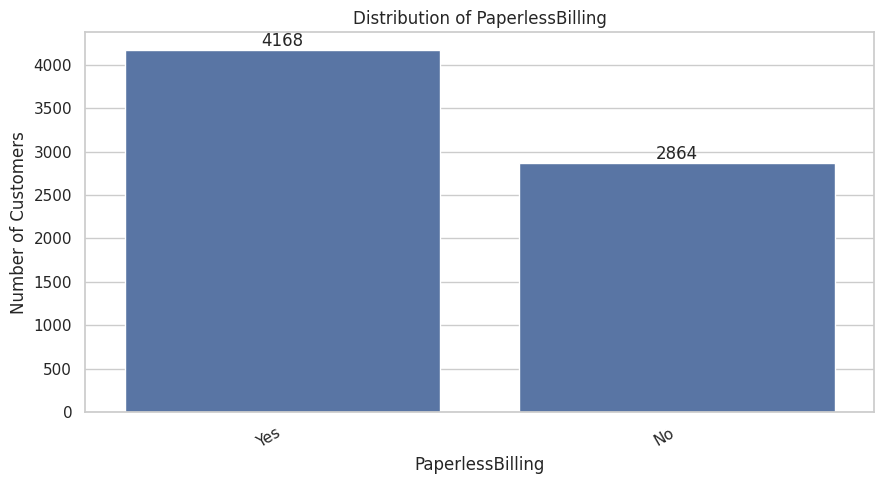

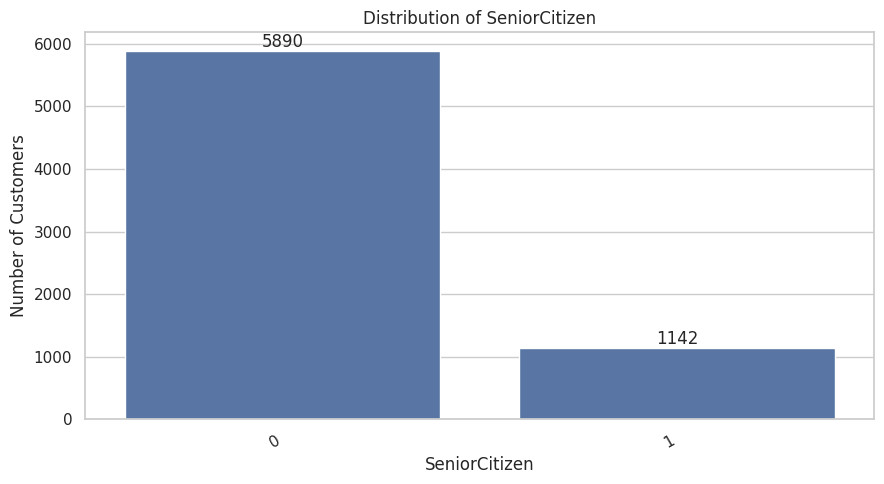

In [36]:
# Selected categorical features for distribution analysis
selected_categorical_features = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "PaperlessBilling",
    "SeniorCitizen"
]

for feature in selected_categorical_features:
    plt.figure(figsize=(9, 5))
    ax = sns.countplot(data=df_eda, x=feature, order=df_eda[feature].value_counts().index)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Number of Customers")
    plt.xticks(rotation=30, ha="right")

    for container in ax.containers:
        ax.bar_label(container, fmt="%d")

    plt.tight_layout()
    plt.show()

### Interpretation

The categorical distributions provide useful context about the composition of the customer base before examining churn risk directly.

Several structural patterns are immediately visible:

- The largest contract segment is **month-to-month** (**3,875 customers**), substantially exceeding the counts for **two-year** (**1,685**) and **one-year** (**1,472**) contracts.
- For internet service, **fiber optic** is the largest category (**3,096 customers**), followed by **DSL** (**2,416**) and customers with **no internet service** (**1,520**).
- The most common payment method is **electronic check** (**2,365 customers**), while the other payment methods are distributed more evenly.
- **Paperless billing** is more common (**4,168 customers**) than non-paperless billing (**2,864**).
- The dataset is dominated by non-senior customers, with **5,890 non-senior** customers and **1,142 senior citizens**.

These frequency patterns are important because they show which customer groups dominate the portfolio. However, raw counts alone do not indicate which segments are more churn-prone. A large group may have high churn simply because it is large, not necessarily because it is risky. For this reason, the next step focuses on **churn rates within each category**, which provides a much more meaningful business view of customer attrition risk.

## 4.4 Churn Rate by Key Categorical Features

This subsection compares the proportion of churning customers across selected categorical features. Churn-rate analysis is often more informative than simple category counts because it reveals which customer segments are disproportionately associated with attrition.

We focus on variables that are especially relevant from a business standpoint:
- **Contract**
- **InternetService**
- **PaymentMethod**
- **PaperlessBilling**
- **TechSupport**
- **OnlineSecurity**
- **SeniorCitizen**

In [37]:
# Function to plot churn rate by categorical feature
def plot_churn_rate(data, feature, target="Churn", save_path=None):
    churn_rate = data.groupby(feature)[target].mean().sort_values(ascending=False) * 100

    plt.figure(figsize=(9, 5))
    ax = sns.barplot(x=churn_rate.index, y=churn_rate.values)

    plt.title(f"Churn Rate by {feature}")
    plt.xlabel(feature)
    plt.ylabel("Churn Rate (%)")
    plt.xticks(rotation=30, ha="right")

    for i, value in enumerate(churn_rate.values):
        ax.text(i, value + 0.5, f"{value:.1f}%", ha="center", va="bottom")

    if SAVE_FIGURES and save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.tight_layout()
    plt.show()

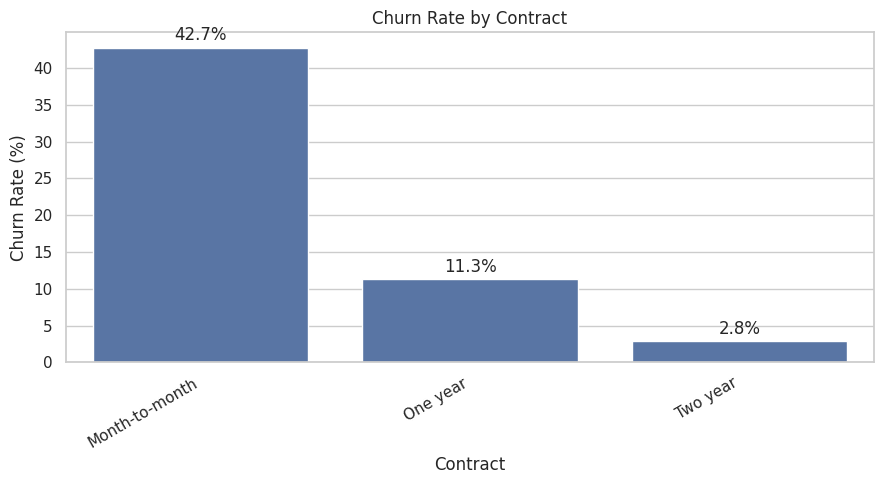

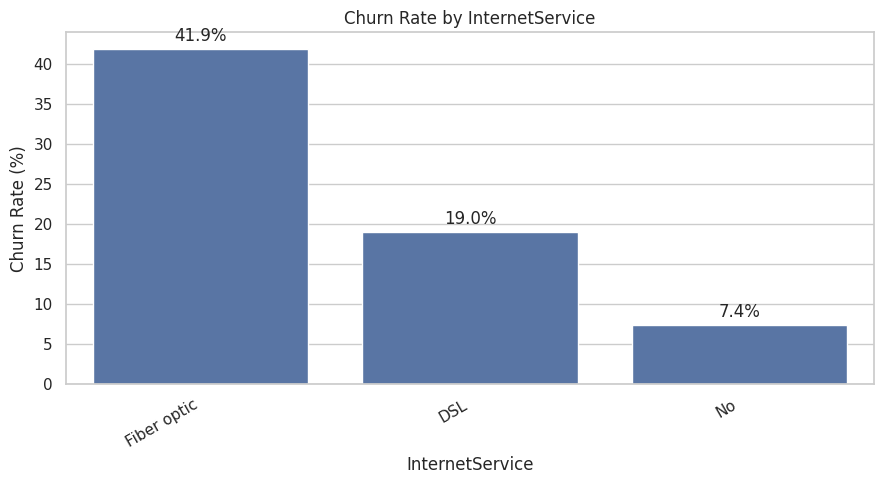

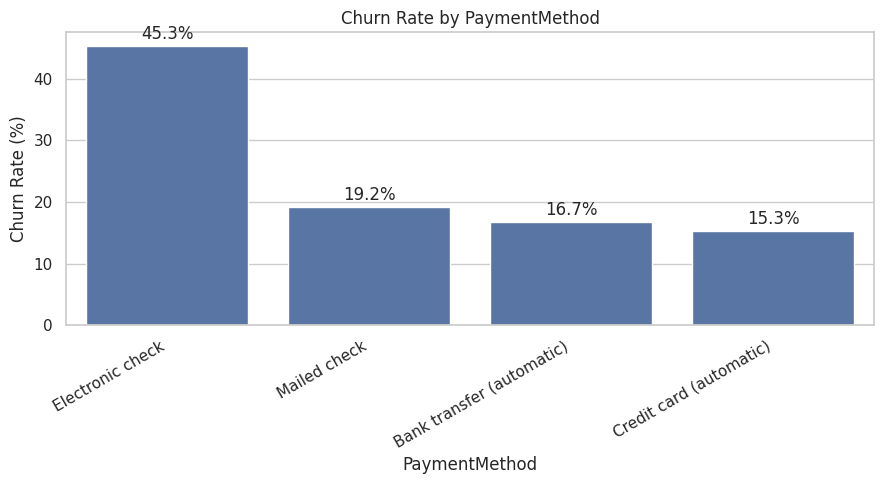

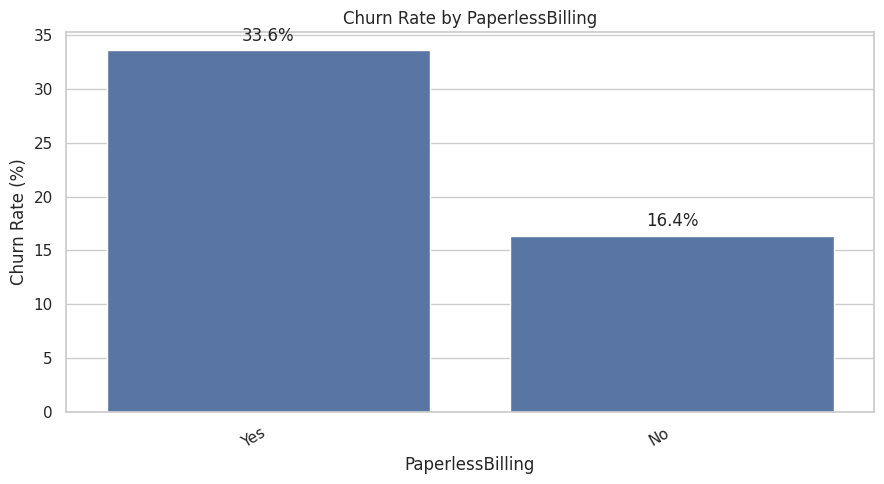

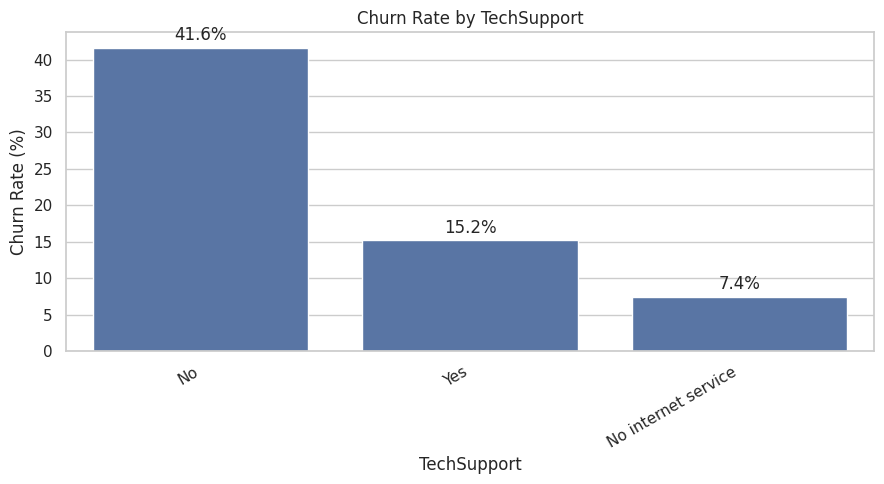

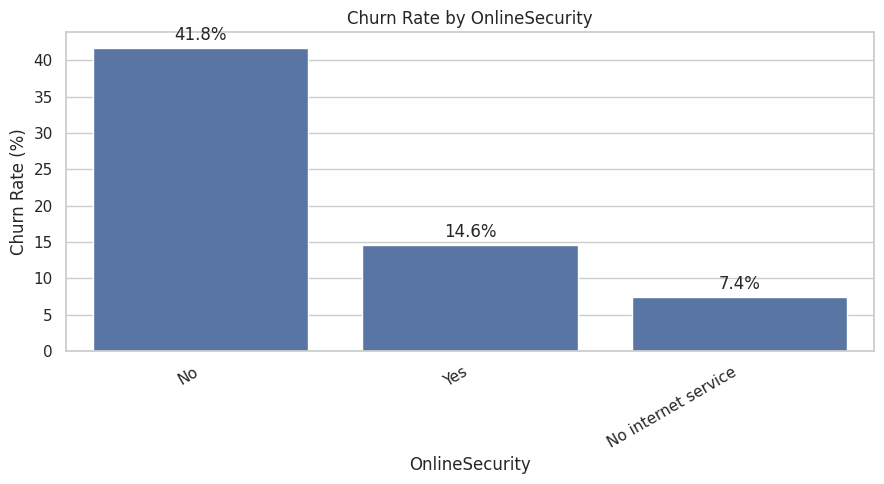

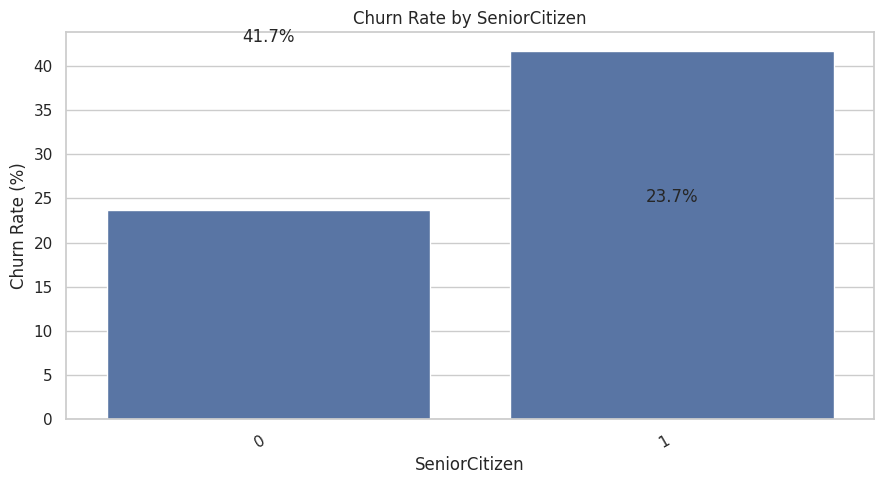

In [38]:
# Plot churn rates for selected categorical features
plot_churn_rate(
    df_eda,
    "Contract",
    save_path=f"{FIGURES_DIR}/churn_rate_by_contract.png"
)

plot_churn_rate(
    df_eda,
    "InternetService"
)

plot_churn_rate(
    df_eda,
    "PaymentMethod",
    save_path=f"{FIGURES_DIR}/churn_rate_by_payment_method.png"
)

plot_churn_rate(
    df_eda,
    "PaperlessBilling"
)

plot_churn_rate(
    df_eda,
    "TechSupport",
    save_path=f"{FIGURES_DIR}/churn_rate_by_tech_support.png"
)

plot_churn_rate(
    df_eda,
    "OnlineSecurity",
    save_path=f"{FIGURES_DIR}/churn_rate_by_online_security.png"
)

plot_churn_rate(
    df_eda,
    "SeniorCitizen"
)

### Interpretation

The churn-rate analysis reveals several strong and business-relevant segment patterns.

The most striking result is contract structure:

- Customers on **month-to-month contracts** have a churn rate of **42.71%**
- Customers on **one-year contracts** churn at **11.28%**
- Customers on **two-year contracts** churn at only **2.85%**

This suggests that long-term contractual commitment is one of the strongest retention stabilizers in the dataset.

Other major patterns also stand out:

- Customers using **fiber optic internet** have the highest churn rate by internet type (**41.89%**), compared with **19.00%** for DSL and **7.43%** for customers without internet service.
- Customers paying by **electronic check** have the highest churn rate among payment methods (**45.29%**), far above customers using automatic bank transfer (**16.73%**) or automatic credit card payment (**15.25%**).
- Customers with **paperless billing** churn at **33.59%**, compared with **16.38%** among those without paperless billing.
- Customers without **TechSupport** show a churn rate of **41.65%**, while those with TechSupport churn at only **15.20%**.
- Customers without **OnlineSecurity** have a churn rate of **41.78%**, compared with **14.64%** among customers who have that service.
- **Senior citizens** churn at a markedly higher rate (**41.68%**) than non-senior customers (**23.65%**).

These results suggest that churn is strongly associated with a mix of **contract flexibility**, **billing behavior**, **service add-ons**, and **customer segment characteristics**. In particular, customers on short-term contracts, customers using electronic checks, and customers lacking support/security services appear to form especially high-risk groups.

From a business perspective, these findings are highly actionable. They suggest that churn mitigation may benefit from:
- encouraging longer-term contracts
- improving value perception among fiber optic customers
- targeting electronic-check customers with retention outreach
- promoting support and security add-ons as retention tools

## 4.5 Encoded Feature Relationship Overview

Because the dataset contains many categorical variables, a traditional correlation matrix is not directly informative without some encoding. As a lightweight exploratory step, we create a one-hot encoded version of the dataset to examine which transformed features show the strongest linear association with churn.

This analysis is intended only as a directional signal and should not be interpreted as causal evidence.

In [41]:
# One-hot encode the dataset for exploratory correlation analysis
df_encoded = pd.get_dummies(df_clean, drop_first=True)

# Correlation of encoded features with churn
churn_correlations = df_encoded.corr()["Churn"].drop("Churn").sort_values(key=abs, ascending=False)

print("Top 15 encoded features most strongly associated with churn:")
display(churn_correlations.head(15).to_frame(name="CorrelationWithChurn"))

Top 15 encoded features most strongly associated with churn:


,CorrelationWithChurn
tenure,-0.35
InternetService_Fiber optic,0.31
Contract_Two year,-0.30
PaymentMethod_Electronic check,0.30
InternetService_No,-0.23
OnlineSecurity_No internet service,-0.23
DeviceProtection_No internet service,-0.23
TechSupport_No internet service,-0.23
StreamingMovies_No internet service,-0.23
StreamingTV_No internet service,-0.23


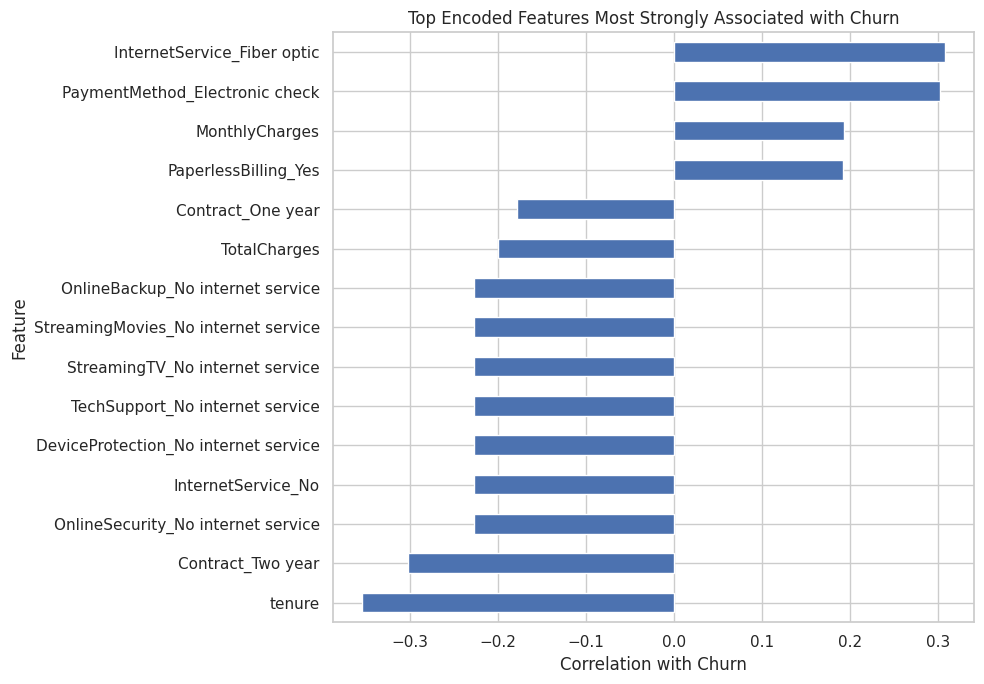

In [42]:
# Plot top correlations with churn
top_corr = churn_correlations.head(15).sort_values()

plt.figure(figsize=(10, 7))
top_corr.plot(kind="barh")
plt.title("Top Encoded Features Most Strongly Associated with Churn")
plt.xlabel("Correlation with Churn")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Interpretation

The encoded-feature correlation overview provides an additional directional signal about which transformed variables are most strongly associated with churn.

The strongest observed relationships include:

- **`tenure`** with a correlation of **-0.35**, indicating that longer customer tenure is associated with lower churn
- **`InternetService_Fiber optic`** with **0.31**, suggesting a positive association between fiber optic service and churn
- **`Contract_Two year`** with **-0.30**, reinforcing the strong retention effect of long-term contracts
- **`PaymentMethod_Electronic check`** with **0.30**, consistent with the high churn rate observed for that payment group
- **`MonthlyCharges`** with **0.19**, suggesting that higher recurring charges are modestly associated with greater churn
- **`PaperlessBilling_Yes`** with **0.19**, indicating that paperless billing is associated with a higher tendency to churn in this dataset
- **`TotalCharges`** with **-0.20**, which aligns with the idea that longer-lasting, higher-lifetime-value customers are less likely to churn

Several “No internet service” encoded features also show moderately negative correlations with churn. This likely reflects a broader customer profile effect rather than the isolated impact of each variable independently.

These results are consistent with the earlier visual analysis and provide useful preliminary confirmation that the most important churn drivers are likely related to:
- customer longevity
- contract duration
- payment behavior
- internet service type
- billing intensity
- support-related service structure

This analysis is only exploratory and should not be interpreted as causal evidence. However, it gives an early indication that the dataset contains coherent predictive structure that the machine learning models can exploit.

## Exploratory Analysis Summary

The exploratory analysis shows that customer churn in this dataset is not random. Instead, it is associated with clear and interpretable patterns across customer lifetime, billing structure, service configuration, and contract type.

The main findings are as follows:

- The target variable is **moderately imbalanced**, with **26.58%** of customers classified as churners.
- **Tenure** appears to be one of the strongest numerical indicators of churn: customers who churn have much shorter service histories on average.
- Churned customers also tend to have **higher monthly charges** but **lower total accumulated charges**, suggesting that many customers leave relatively early while still facing comparatively high recurring costs.
- Contract structure is one of the most important business signals: **month-to-month customers** exhibit dramatically higher churn than customers on one-year or two-year agreements.
- High churn is also associated with **fiber optic service**, **electronic check payment**, **paperless billing**, and the absence of **TechSupport** or **OnlineSecurity**.
- **Senior citizens** appear to be a higher-risk segment than the rest of the customer base.

Overall, the EDA indicates that churn risk is especially concentrated among customers with **short tenure, flexible contracts, higher recurring charges, weaker support coverage, and certain billing behaviors**. These insights provide a strong analytical foundation for the next stage of the workflow, where we will formalize the modeling task, define evaluation strategy, and prepare the data for machine learning pipelines.

# 5. Problem Formulation and Evaluation Strategy

In this section, we formally define the machine learning task and establish the evaluation framework that will guide model development.

The objective of the project is to predict whether a telecom customer will churn based on demographic, contractual, service-related, and billing features. This is a **supervised binary classification problem**, where the target variable has already been encoded as:

- **1** → customer churned
- **0** → customer did not churn

A strong modeling setup requires more than selecting an algorithm. It also requires:
- a clear separation between features and target
- an appropriate train-test split strategy
- careful handling of mixed feature types
- evaluation metrics aligned with business priorities

Because churn prediction is a retention-focused problem, model quality should be judged not only by overall accuracy, but also by how effectively the model identifies customers who are actually at risk of leaving.

## 5.1 Modeling Objective

The goal of this project is to develop a classification model that can estimate the probability that a customer will churn. In a real business setting, such a model could be used to:

- flag high-risk customers for retention campaigns
- prioritize outreach resources more efficiently
- improve contract and pricing strategies
- support customer success and service intervention decisions

From an operational perspective, missing a true churner may be more costly than incorrectly flagging a customer who would have stayed. For this reason, the modeling process should pay particular attention to metrics that capture the model’s ability to identify churners effectively.

## 5.2 Evaluation Metrics

Because the target distribution is **moderately imbalanced** — with **73.42% non-churners** and **26.58% churners** — accuracy alone is not sufficient for evaluating model quality. A model could achieve a superficially strong accuracy score by overpredicting the majority class while still failing to identify many customers who are genuinely at risk of leaving.

The following metrics will therefore be used throughout the modeling process:

- **Accuracy**: overall proportion of correct predictions
- **Precision**: of the customers predicted to churn, how many actually churned
- **Recall**: of the customers who actually churned, how many were correctly identified
- **F1-score**: harmonic mean of precision and recall
- **ROC-AUC**: the model’s ability to separate churners from non-churners across thresholds
- **Average Precision / PR-AUC**: especially informative when focusing on the minority class

In the context of churn prediction, **recall** is especially important because failing to identify a true churner means missing an opportunity for retention intervention. At the same time, **precision** also matters, since a very low-precision model could lead to inefficient or unnecessarily costly retention campaigns. For that reason, later stages of the project will also include **threshold tuning** to better align predictive decisions with business trade-offs.

## 5.3 Train-Test Split Strategy

To evaluate generalization performance properly, the cleaned dataset was split into separate training and test sets using a **stratified 80/20 split**.

This resulted in:

- **Training set:** 5,625 observations
- **Test set:** 1,407 observations

Stratification was used to preserve the class proportions across the full dataset and both subsets. As shown in the split comparison, the churn distribution remains perfectly aligned:

- **Full dataset:** 73.42% non-churn, 26.58% churn
- **Training set:** 73.42% non-churn, 26.58% churn
- **Test set:** 73.42% non-churn, 26.58% churn

This is an ideal result because it ensures that both model development and final out-of-sample evaluation are based on representative class structure. It also reduces the risk of misleading performance estimates caused by accidental class distortion during splitting.

In [43]:
# ============================================================
# Block 5: Problem Formulation and Evaluation Strategy
# ============================================================

# Define features and target
X = df_clean.drop(columns=["Churn"])
y = df_clean["Churn"]

print("Features and target defined successfully.")
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Features and target defined successfully.
Feature matrix shape: (7032, 19)
Target vector shape: (7032,)


In [44]:
# Confirm target balance before splitting
target_distribution = y.value_counts().sort_index()
target_percentage = y.value_counts(normalize=True).sort_index() * 100

target_balance_summary = pd.DataFrame({
    "Count": target_distribution,
    "Percentage": target_percentage.round(2)
})

target_balance_summary.index = ["No Churn (0)", "Churn (1)"]
display(target_balance_summary)

,Count,Percentage
No Churn (0),5163,73.42
Churn (1),1869,26.58


In [45]:
# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train-test split completed successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Train-test split completed successfully.
X_train shape: (5625, 19)
X_test shape: (1407, 19)
y_train shape: (5625,)
y_test shape: (1407,)


In [46]:
# Compare class distribution across full dataset, training set, and test set
split_balance = pd.DataFrame({
    "Full Dataset": y.value_counts(normalize=True).sort_index() * 100,
    "Training Set": y_train.value_counts(normalize=True).sort_index() * 100,
    "Test Set": y_test.value_counts(normalize=True).sort_index() * 100
}).round(2)

split_balance.index = ["No Churn (0)", "Churn (1)"]
display(split_balance)

,Full Dataset,Training Set,Test Set
No Churn (0),73.42,73.42,73.42
Churn (1),26.58,26.58,26.58


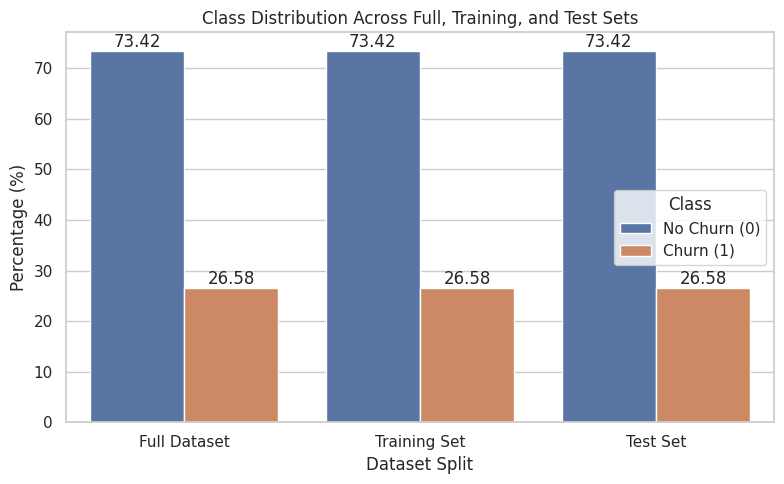

In [47]:
# Plot class balance comparison across splits
split_balance_plot = split_balance.T.reset_index().rename(columns={"index": "Dataset"})
split_balance_melted = split_balance_plot.melt(id_vars="Dataset", var_name="Class", value_name="Percentage")

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=split_balance_melted, x="Dataset", y="Percentage", hue="Class")

plt.title("Class Distribution Across Full, Training, and Test Sets")
plt.xlabel("Dataset Split")
plt.ylabel("Percentage (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

if SAVE_FIGURES:
    plt.savefig(f"{FIGURES_DIR}/class_distribution_across_splits.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

## 5.4 Preprocessing Philosophy

The feature matrix contains **19 predictive variables**, consisting of a mixture of numerical and categorical data types. Specifically:

- **4 numerical features**: `SeniorCitizen`, `tenure`, `MonthlyCharges`, and `TotalCharges`
- **15 categorical features** related to demographics, account structure, telecom services, support options, contract type, and payment behavior

This mixed feature structure reinforces the need for a **pipeline-based preprocessing workflow**. Numerical and categorical variables require different transformations, and applying them consistently is essential for robust machine learning practice.

In the next stage, preprocessing will be implemented using a structured pipeline so that:
- numerical features can be scaled where appropriate
- categorical features can be encoded systematically
- all transformations are fit only on the training data
- the same logic can later be applied to the test set and future inference data without leakage

This approach improves reproducibility, cleanliness, and modeling integrity.

In [48]:
# Identify numerical and categorical feature columns
numerical_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [49]:
# Create feature type summary
feature_type_summary = pd.DataFrame({
    "Feature": X_train.columns,
    "DataType": X_train.dtypes.astype(str).values,
    "FeatureType": [
        "Numerical" if col in numerical_features else "Categorical"
        for col in X_train.columns
    ]
})

display(feature_type_summary)

,Feature,DataType,FeatureType
0,gender,object,Categorical
1,SeniorCitizen,int64,Numerical
2,Partner,object,Categorical
3,Dependents,object,Categorical
4,tenure,int64,Numerical
5,PhoneService,object,Categorical
6,MultipleLines,object,Categorical
7,InternetService,object,Categorical
8,OnlineSecurity,object,Categorical
9,OnlineBackup,object,Categorical


## 5.5 Cross-Validation Strategy

Within the training set, model comparison and hyperparameter tuning will rely on **5-fold stratified cross-validation**.

The cross-validation strategy is defined as:

- **5 folds**
- **shuffle = True**
- **random_state = 42**

A stratified scheme is especially appropriate here because it preserves the churn / non-churn ratio across validation folds. This makes model selection more stable and reduces the risk that performance conclusions depend too heavily on a single train-validation partition.

Using cross-validation at this stage will provide a more reliable basis for comparing baseline models and tuning the gradient boosting model later in the notebook.

In [50]:
# Define cross-validation strategy
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("Cross-validation strategy initialized successfully.")
print(cv_strategy)

Cross-validation strategy initialized successfully.
StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


## 5.6 Metric Prioritization Overview

The relative importance of classification metrics depends on business objectives. In churn prediction, the goal is not simply to maximize the number of correct classifications overall, but to identify customers at meaningful risk of leaving while keeping intervention efforts efficient.

For that reason:

- **Recall** is highly important because missed churners represent lost retention opportunities
- **F1-score** is highly important because it balances recall and precision
- **ROC-AUC** is highly important because it evaluates ranking quality across thresholds
- **Precision** and **Average Precision** remain valuable because retention resources are limited
- **Accuracy** is still useful, but should be treated as a secondary metric in an imbalanced churn setting

The chart below summarizes the conceptual role of these evaluation metrics in the context of churn prediction.

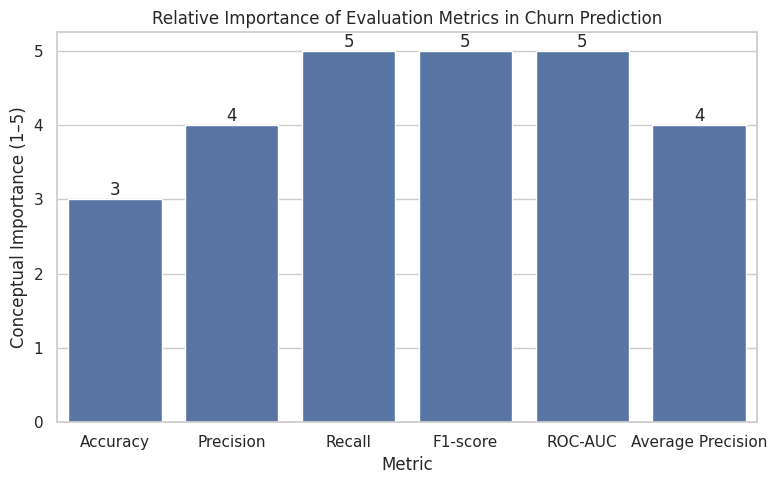

In [51]:
# Conceptual metric importance chart
metric_priority = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "Average Precision"],
    "ImportanceScore": [3, 4, 5, 5, 5, 4]
})

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=metric_priority, x="Metric", y="ImportanceScore")

plt.title("Relative Importance of Evaluation Metrics in Churn Prediction")
plt.xlabel("Metric")
plt.ylabel("Conceptual Importance (1–5)")

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

if SAVE_FIGURES:
    plt.savefig(f"{FIGURES_DIR}/metric_importance_overview.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

### Interpretation

The problem is now formally defined as a **binary classification task** in which the objective is to predict customer churn using **19 input features** derived from customer profile, service usage, contract, and billing information.

The cleaned dataset of **7,032 observations** was split into:
- **5,625 training observations**
- **1,407 test observations**

The split was performed using **stratification**, and the class proportions were preserved exactly across the full dataset, training set, and test set. This is an important result because it ensures that both model development and final evaluation remain representative of the underlying churn distribution.

The feature space contains a mix of:
- **4 numerical variables**
- **15 categorical variables**

This confirms that the next stage should use a preprocessing pipeline capable of handling mixed data types in a clean, reproducible, and leakage-safe way.

From an evaluation standpoint, this project will emphasize not only **accuracy**, but also **precision**, **recall**, **F1-score**, **ROC-AUC**, and **average precision**. This metric choice reflects the business reality of churn prediction, where correctly identifying likely churners is often more valuable than maximizing overall classification accuracy alone.

With the dataset split, the feature structure identified, and the evaluation framework established, the notebook is now ready to move into preprocessing pipeline design and baseline model development.

# 6. Preprocessing Pipeline Design

In this section, we design the preprocessing workflow that will be used for model training and evaluation. Because the dataset contains both numerical and categorical variables, the transformation logic must handle each feature type appropriately while remaining fully reproducible and leakage-safe.

A pipeline-based preprocessing design offers several important advantages:

- it keeps transformations consistent across training and test data
- it prevents data leakage by fitting preprocessing steps only on the training set
- it integrates naturally with cross-validation and hyperparameter tuning
- it creates a cleaner and more maintainable machine learning workflow

The preprocessing strategy in this project will be based on a **`ColumnTransformer`**, which allows numerical and categorical features to be processed in parallel within a single modeling pipeline.

## 6.1 Preprocessing Strategy

The feature matrix contains a mixed-type structure composed of:

- **4 numerical features**: `SeniorCitizen`, `tenure`, `MonthlyCharges`, and `TotalCharges`
- **15 categorical features** related to demographics, account structure, telecom services, support options, contract type, and payment method

Because these two groups require different transformation logic, preprocessing must be handled in a structured and type-aware way. A unified pipeline-based approach is especially appropriate here because it ensures that all transformations are learned from the training data only and then applied consistently to validation folds, the holdout test set, and any future inference data.

This design is important not only for correctness, but also for reproducibility and leakage prevention. It creates a modeling foundation that is much closer to real applied machine learning practice than manual preprocessing performed outside the pipeline.

In [52]:
# ============================================================
# Block 6: Preprocessing Pipeline Design
# ============================================================

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print(f"\nNumber of numerical features: {len(numerical_features)}")
print(f"Number of categorical features: {len(categorical_features)}")

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Number of numerical features: 4
Number of categorical features: 15


## 6.2 Numerical Pipeline

The numerical preprocessing pipeline applies two sequential steps:

1. **Median imputation**
2. **Standard scaling**

Although the cleaned dataset currently has no remaining missing values, median imputation is included as a defensive design choice. This makes the preprocessing workflow more robust to future data or deployment-style inference scenarios in which missing numerical values may appear.

Standard scaling transforms the numerical variables into a comparable standardized range. This is particularly useful for models such as logistic regression, which are sensitive to feature magnitude. Even though tree-based models do not strictly require scaling, keeping the numerical transformation consistent across all candidate models improves comparability and workflow discipline.

In [53]:
# Numerical preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

print("Numerical preprocessing pipeline created successfully.")
numeric_transformer

Numerical preprocessing pipeline created successfully.


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

## 6.3 Categorical Pipeline

The categorical preprocessing pipeline applies:

1. **Most-frequent imputation**
2. **One-hot encoding with `handle_unknown="ignore"`**

As with the numerical pipeline, categorical imputation serves as a robustness safeguard even though the cleaned dataset currently contains no missing categorical values. This choice makes the transformation logic more durable in case incomplete records appear in future data.

The one-hot encoder expands each categorical level into a separate binary indicator. This is a standard and appropriate choice for this dataset because the categorical variables represent nominal business categories rather than ordered values. The use of `handle_unknown="ignore"` is especially important because it allows the pipeline to process unseen categories safely without breaking during inference.

In [54]:
# Categorical preprocessing pipeline
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

print("Categorical preprocessing pipeline created successfully.")
categorical_transformer

Categorical preprocessing pipeline created successfully.


Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

## 6.4 Combined Preprocessing with ColumnTransformer

The numerical and categorical preprocessing pipelines are combined into a single **`ColumnTransformer`**, creating a centralized transformation workflow for the full feature matrix.

This design has several practical advantages:

- it ensures that numerical and categorical variables are processed appropriately within one unified framework
- it avoids manual preprocessing outside the modeling pipeline
- it allows the same preprocessing logic to be reused consistently across baseline models and the final gradient boosting model
- it integrates naturally with cross-validation and hyperparameter tuning

In effect, the `ColumnTransformer` becomes the preprocessing backbone of the project, making the workflow cleaner, safer, and more scalable.

In [55]:
# Combined preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Combined preprocessing transformer created successfully.")
preprocessor

Combined preprocessing transformer created successfully.


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'])])

## 6.5 Fitting the Preprocessor on the Training Data

The combined preprocessor was fit on the training set and then applied to both the training and test feature matrices.

The transformation completed successfully and produced:

- a processed training matrix of shape **(5,625, 45)**
- a processed test matrix of shape **(1,407, 45)**

This confirms that the preprocessing workflow behaves consistently across both data splits and that the transformed feature space is aligned correctly between training and test data.

This verification step is important because it confirms that categorical encoding, numerical scaling, and feature-space expansion all function as expected before model training begins.

In [56]:
# Fit the preprocessor on training data and transform both splits
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing fit and transformation completed successfully.")
print(f"Processed training feature matrix shape: {X_train_processed.shape}")
print(f"Processed test feature matrix shape: {X_test_processed.shape}")

Preprocessing fit and transformation completed successfully.
Processed training feature matrix shape: (5625, 45)
Processed test feature matrix shape: (1407, 45)


In [57]:
# Inspect the dimensional expansion after one-hot encoding
num_feature_count = len(numerical_features)

encoded_cat_feature_names = preprocessor.named_transformers_["cat"] \
    .named_steps["encoder"] \
    .get_feature_names_out(categorical_features)

cat_feature_count = len(encoded_cat_feature_names)
total_processed_features = X_train_processed.shape[1]

print("Processed feature space summary:")
print(f"- Original numerical features: {num_feature_count}")
print(f"- Original categorical features: {len(categorical_features)}")
print(f"- Encoded categorical features: {cat_feature_count}")
print(f"- Total processed features: {total_processed_features}")

Processed feature space summary:
- Original numerical features: 4
- Original categorical features: 15
- Encoded categorical features: 41
- Total processed features: 45


In [58]:
# Build a full feature-name list for the processed matrix
processed_feature_names = numerical_features + list(encoded_cat_feature_names)

processed_feature_summary = pd.DataFrame({
    "ProcessedFeature": processed_feature_names,
    "SourceType": (
        ["Numerical"] * len(numerical_features) +
        ["Categorical (One-Hot Encoded)"] * len(encoded_cat_feature_names)
    )
})

display(processed_feature_summary.head(20))

,ProcessedFeature,SourceType
0,SeniorCitizen,Numerical
1,tenure,Numerical
2,MonthlyCharges,Numerical
3,TotalCharges,Numerical
4,gender_Female,Categorical (One-Hot Encoded)
5,gender_Male,Categorical (One-Hot Encoded)
6,Partner_No,Categorical (One-Hot Encoded)
7,Partner_Yes,Categorical (One-Hot Encoded)
8,Dependents_No,Categorical (One-Hot Encoded)
9,Dependents_Yes,Categorical (One-Hot Encoded)


## 6.6 Processed Feature Space Interpretation

After preprocessing, the original feature set expands into a **45-dimensional processed feature space**.

This total is composed of:

- **4 original numerical features**
- **41 one-hot encoded categorical features**

The increase in dimensionality is expected because each categorical variable is expanded into binary indicators representing its observed levels. This is especially visible in variables such as `Contract`, `InternetService`, `PaymentMethod`, and service-related features, all of which contain multiple distinct categories.

The processed feature preview confirms that the transformed matrix now contains:

- standardized numerical variables
- one-hot encoded categorical indicators
- a structure suitable for machine learning algorithms such as logistic regression, decision trees, random forests, and gradient boosting classifiers

This validation is an important quality-control step because it confirms that the pipeline produces a coherent and model-ready numerical representation of the dataset.

In [59]:
# Optional preview of processed training data as a DataFrame
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=processed_feature_names,
    index=X_train.index
)

display(X_train_processed_df.head())

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
1413,-0.44,1.32,0.98,1.66,0.00,1.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,1.00,0.00,0.00
7003,-0.44,-0.27,-0.97,-0.56,0.00,1.00,1.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00
3355,-0.44,1.44,0.84,1.76,1.00,0.00,0.00,1.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,1.00,0.00,0.00
4494,-0.44,-1.20,0.64,-0.91,0.00,1.00,1.00,0.00,1.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00
3541,-0.44,0.67,-0.81,-0.10,1.00,0.00,0.00,1.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00


## 6.7 Visual Summary of Preprocessing Structure

The feature-space summary chart highlights the transformation from the original dataset into the processed modeling space.

The original input contained:

- **4 numerical features**
- **15 categorical features**

After one-hot encoding, the categorical variables expanded into **41 encoded features**, resulting in a total of **45 processed features**.

This is a relatively moderate and fully manageable expansion, which makes the transformed dataset well-suited for both interpretable baseline models and more advanced classification methods. The chart also helps illustrate why pipeline-based preprocessing is valuable: even a dataset that appears compact at first can become substantially richer once categorical structure is represented properly.

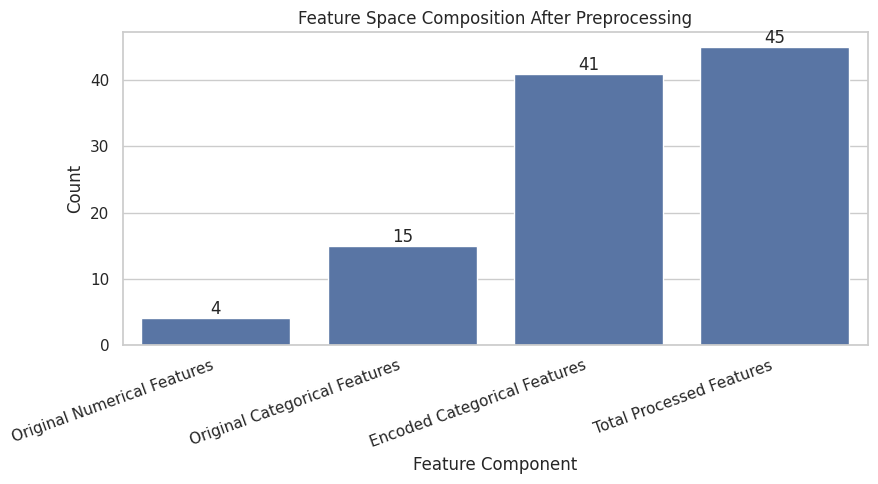

In [60]:
# Visual summary of feature-space composition
feature_composition = pd.DataFrame({
    "Component": ["Original Numerical Features", "Original Categorical Features", "Encoded Categorical Features", "Total Processed Features"],
    "Count": [len(numerical_features), len(categorical_features), cat_feature_count, total_processed_features]
})

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=feature_composition, x="Component", y="Count")

plt.title("Feature Space Composition After Preprocessing")
plt.xlabel("Feature Component")
plt.ylabel("Count")
plt.xticks(rotation=20, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

if SAVE_FIGURES:
    plt.savefig(f"{FIGURES_DIR}/feature_space_composition.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

### Interpretation

The preprocessing workflow is now fully defined, validated, and ready for model development.

The final preprocessing design includes:

- **median imputation** and **standard scaling** for the 4 numerical features
- **most-frequent imputation** and **one-hot encoding** for the 15 categorical features
- a unified **`ColumnTransformer`** that applies these transformations in a centralized and reusable way

Fitting the preprocessor on the training data confirms that the pipeline behaves as expected and transforms the dataset into a stable **45-feature modeling space**, with fully compatible outputs for both the training and test sets.

This is a critical milestone in the notebook because it ensures that all subsequent model comparisons will be carried out under a consistent, leakage-safe, and reproducible preprocessing framework. With preprocessing now established, the workflow is ready to move into **baseline model benchmarking**, where simpler classifiers will be evaluated before introducing the final gradient boosting approach.

# 7. Baseline Model Benchmarking

Before moving to the final gradient boosting model, it is important to establish a set of baseline classifiers. Benchmarking simpler models provides a meaningful reference point for evaluating whether a more advanced method genuinely improves predictive performance.

In this section, we compare several standard classification models under the same preprocessing framework:

- **Logistic Regression**
- **Decision Tree**
- **Random Forest**

These models were chosen because they represent different levels of complexity and different modeling philosophies:

- **Logistic Regression** provides a strong linear baseline
- **Decision Tree** captures nonlinear decision rules in an interpretable way
- **Random Forest** offers a more robust ensemble-based tree model

All models will be evaluated using the same preprocessing pipeline, the same stratified cross-validation strategy, and the same set of performance metrics. This ensures that the comparison is fair, reproducible, and informative.

## 7.1 Benchmarking Strategy

The goal of baseline benchmarking is not merely to identify the highest raw score, but to understand how different model families behave on the churn prediction task.

The evaluation process in this section follows a two-stage structure:

1. **Cross-validation on the training set**  
   This provides a stable estimate of generalization performance during model comparison.

2. **Evaluation on the holdout test set**  
   This provides a clean out-of-sample assessment after training each model on the full training data.

The main metrics used for comparison will be:

- **Accuracy**
- **Precision**
- **Recall**
- **F1-score**
- **ROC-AUC**
- **Average Precision**

This combination provides a balanced view of overall correctness, churn detection quality, ranking quality, and minority-class performance.

In [61]:
# ============================================================
# Block 7: Baseline Model Benchmarking
# ============================================================

from sklearn.base import clone

print("Additional benchmarking utilities imported successfully.")

Additional benchmarking utilities imported successfully.


## 7.2 Defining Baseline Models

The baseline models used in this section are intentionally diverse:

- **Logistic Regression** serves as a linear probabilistic classifier
- **Decision Tree** serves as a simple nonlinear model
- **Random Forest** serves as a more stable ensemble-based tree model

Together, these models provide a useful benchmark spectrum before introducing the final gradient boosting approach.

In [62]:
# Define baseline models
baseline_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

print("Baseline models initialized successfully.")
print("Models to benchmark:")
for model_name in baseline_models:
    print(f"- {model_name}")

Baseline models initialized successfully.
Models to benchmark:
- Logistic Regression
- Decision Tree
- Random Forest


## 7.3 Cross-Validation Benchmarking

To compare the baseline models fairly, each one is wrapped inside a full machine learning pipeline consisting of:

- the shared preprocessing transformer
- the model estimator

Cross-validation is then performed on the training set using the previously defined **5-fold stratified cross-validation strategy**.

This provides a robust first comparison while preserving the leakage-safe preprocessing design established earlier.

In [63]:
# Cross-validation scoring metrics
cv_scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}

print("Cross-validation scoring metrics configured successfully.")
cv_scoring

Cross-validation scoring metrics configured successfully.


{'accuracy': 'accuracy',
 'precision': 'precision',
 'recall': 'recall',
 'f1': 'f1',
 'roc_auc': 'roc_auc',
 'average_precision': 'average_precision'}

In [64]:
# Run cross-validation for each baseline model
cv_results = []

for model_name, model in baseline_models.items():
    model_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", clone(model))
    ])

    model_cv = cross_validate(
        model_pipeline,
        X_train,
        y_train,
        cv=cv_strategy,
        scoring=cv_scoring,
        n_jobs=-1,
        return_train_score=False
    )

    cv_results.append({
        "Model": model_name,
        "CV Accuracy": model_cv["test_accuracy"].mean(),
        "CV Precision": model_cv["test_precision"].mean(),
        "CV Recall": model_cv["test_recall"].mean(),
        "CV F1-score": model_cv["test_f1"].mean(),
        "CV ROC-AUC": model_cv["test_roc_auc"].mean(),
        "CV Avg Precision": model_cv["test_average_precision"].mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by="CV ROC-AUC", ascending=False)
display(cv_results_df.round(4))

,Model,CV Accuracy,CV Precision,CV Recall,CV F1-score,CV ROC-AUC,CV Avg Precision
0,Logistic Regression,0.80,0.65,0.55,0.60,0.85,0.66
2,Random Forest,0.79,0.64,0.50,0.56,0.83,0.63
1,Decision Tree,0.73,0.49,0.50,0.49,0.65,0.38


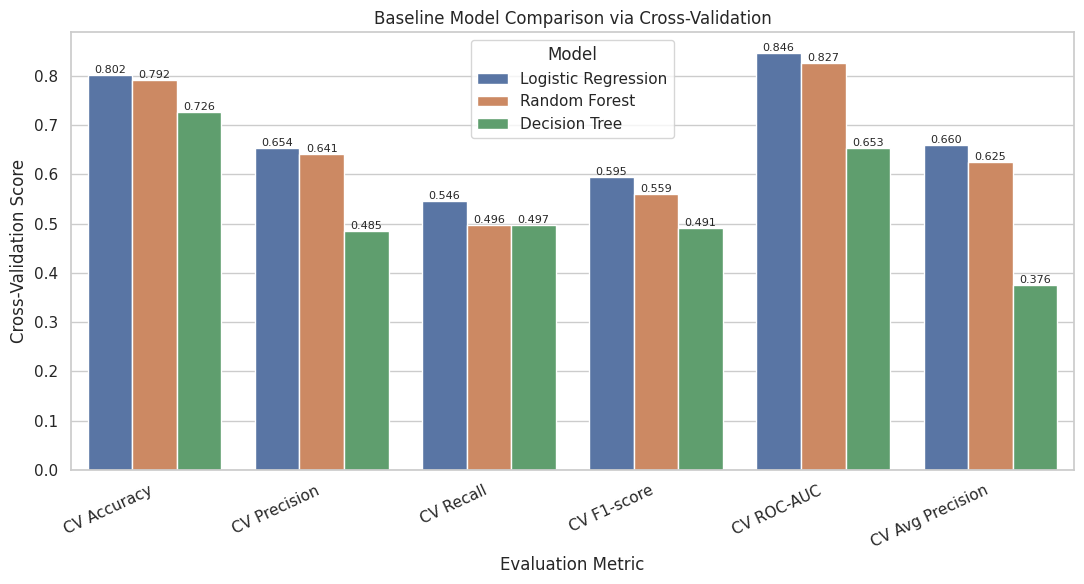

In [65]:
# Visualize cross-validation results across key metrics
cv_results_melted = cv_results_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 6))
ax = sns.barplot(data=cv_results_melted, x="Metric", y="Score", hue="Model")

plt.title("Baseline Model Comparison via Cross-Validation")
plt.xlabel("Evaluation Metric")
plt.ylabel("Cross-Validation Score")
plt.xticks(rotation=25, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8)

if SAVE_FIGURES:
    plt.savefig(f"{FIGURES_DIR}/baseline_model_cv_comparison.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

### Interpretation

The cross-validation results provide a stable first comparison of the baseline models on the training data.

Several patterns are clear:

- **Logistic Regression** performs best overall across nearly all metrics, with:
  - **CV Accuracy = 0.80**
  - **CV Precision = 0.65**
  - **CV Recall = 0.55**
  - **CV F1-score = 0.60**
  - **CV ROC-AUC = 0.85**
  - **CV Average Precision = 0.66**
- **Random Forest** is competitive but consistently slightly weaker than Logistic Regression:
  - **CV Accuracy = 0.79**
  - **CV ROC-AUC = 0.83**
  - **CV Average Precision = 0.63**
- **Decision Tree** performs substantially worse than the other two models, especially in ranking quality:
  - **CV Accuracy = 0.73**
  - **CV ROC-AUC = 0.65**
  - **CV Average Precision = 0.38**

This pattern suggests that the churn prediction problem contains meaningful signal that can already be captured by a relatively strong linear baseline. At the same time, the weaker performance of the single Decision Tree indicates that a simple unregularized nonlinear model is not sufficient on its own.

The most important takeaway is that **Logistic Regression establishes a strong baseline**, while **Random Forest provides a credible nonlinear benchmark**. These two models form the most relevant comparison points for the advanced gradient boosting stage that follows.

## 7.4 Holdout Test Evaluation

Cross-validation provides a strong internal benchmark, but it is also important to evaluate each model on the untouched test set.

In this step, each baseline model is trained on the full training set and then evaluated on the holdout test set using both class predictions and predicted probabilities.

This produces a final out-of-sample comparison that complements the cross-validation results.

In [66]:
# Train each model on full training set and evaluate on the test set
test_results = []

fitted_baseline_pipelines = {}

for model_name, model in baseline_models.items():
    model_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", clone(model))
    ])

    model_pipeline.fit(X_train, y_train)
    fitted_baseline_pipelines[model_name] = model_pipeline

    y_pred = model_pipeline.predict(X_test)
    y_proba = model_pipeline.predict_proba(X_test)[:, 1]

    test_results.append({
        "Model": model_name,
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred),
        "Test Recall": recall_score(y_test, y_pred),
        "Test F1-score": f1_score(y_test, y_pred),
        "Test ROC-AUC": roc_auc_score(y_test, y_proba),
        "Test Avg Precision": average_precision_score(y_test, y_proba)
    })

test_results_df = pd.DataFrame(test_results).sort_values(by="Test ROC-AUC", ascending=False)
display(test_results_df.round(4))

,Model,Test Accuracy,Test Precision,Test Recall,Test F1-score,Test ROC-AUC,Test Avg Precision
0,Logistic Regression,0.80,0.65,0.57,0.61,0.84,0.62
2,Random Forest,0.79,0.64,0.49,0.56,0.81,0.59
1,Decision Tree,0.73,0.49,0.50,0.50,0.66,0.38


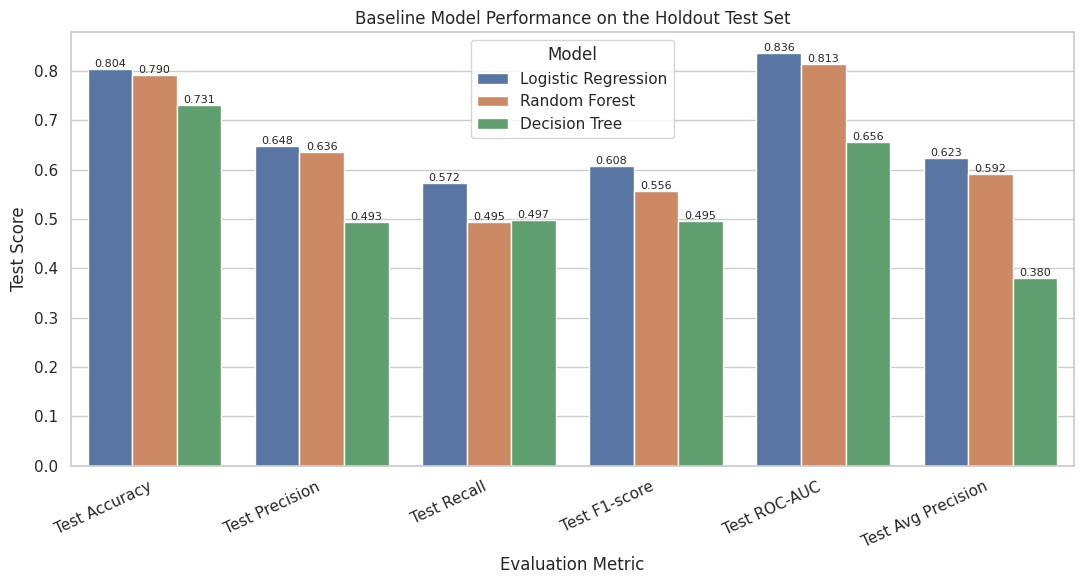

In [67]:
# Visualize holdout test results
test_results_melted = test_results_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 6))
ax = sns.barplot(data=test_results_melted, x="Metric", y="Score", hue="Model")

plt.title("Baseline Model Performance on the Holdout Test Set")
plt.xlabel("Evaluation Metric")
plt.ylabel("Test Score")
plt.xticks(rotation=25, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8)

if SAVE_FIGURES:
    plt.savefig(f"{FIGURES_DIR}/baseline_model_test_comparison.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

### Interpretation

The holdout test results closely mirror the cross-validation findings, which is a strong sign of model stability and low performance inflation.

The out-of-sample rankings are:

### Logistic Regression
- **Test Accuracy = 0.80**
- **Test Precision = 0.65**
- **Test Recall = 0.57**
- **Test F1-score = 0.61**
- **Test ROC-AUC = 0.84**
- **Test Average Precision = 0.62**

### Random Forest
- **Test Accuracy = 0.79**
- **Test Precision = 0.64**
- **Test Recall = 0.49**
- **Test F1-score = 0.56**
- **Test ROC-AUC = 0.81**
- **Test Average Precision = 0.59**

### Decision Tree
- **Test Accuracy = 0.73**
- **Test Precision = 0.49**
- **Test Recall = 0.50**
- **Test F1-score = 0.50**
- **Test ROC-AUC = 0.66**
- **Test Average Precision = 0.38**

These results confirm that **Logistic Regression is the strongest baseline model** on this dataset. It achieves the best balance of churn detection quality, ranking ability, and overall predictive stability. Random Forest remains competitive, but its lower recall and lower ranking performance suggest that it is not yet outperforming the simpler linear baseline. Decision Tree performs clearly worst and is not competitive enough to serve as the final candidate model.

This is a useful result for the overall project narrative: the advanced model should now be expected to outperform a **strong Logistic Regression baseline**, not merely weaker tree-based alternatives.

## 7.5 Classification Reports and Confusion Matrices

Aggregate metric tables are useful, but they do not fully capture model behavior. To better understand how each baseline classifier handles churn and non-churn cases, we also inspect:

- the **classification report**
- the **confusion matrix**

This provides a more detailed view of precision-recall balance and helps reveal whether a model is overly conservative or overly aggressive in predicting churn.

In [68]:
# Print classification reports for each baseline model
for model_name, model_pipeline in fitted_baseline_pipelines.items():
    y_pred = model_pipeline.predict(X_test)

    print("=" * 80)
    print(f"{model_name} — Classification Report")
    print("=" * 80)
    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))
    print()

Logistic Regression — Classification Report
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407


Decision Tree — Classification Report
              precision    recall  f1-score   support

    No Churn       0.82      0.82      0.82      1033
       Churn       0.49      0.50      0.50       374

    accuracy                           0.73      1407
   macro avg       0.66      0.66      0.66      1407
weighted avg       0.73      0.73      0.73      1407


Random Forest — Classification Report
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1033
       Churn       0.64      0.49      0.56       374

    accuracy                           0.79      1407
   mac

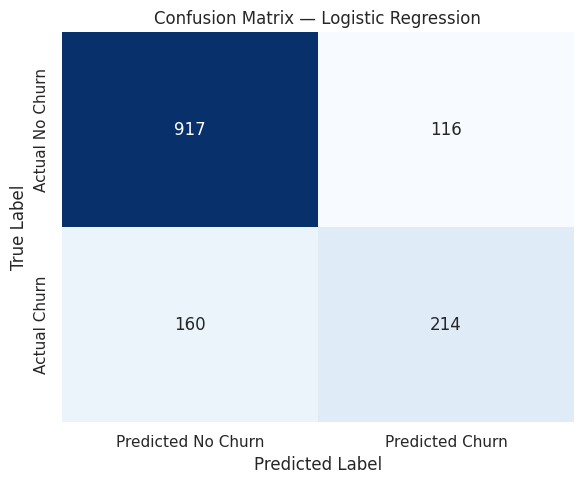

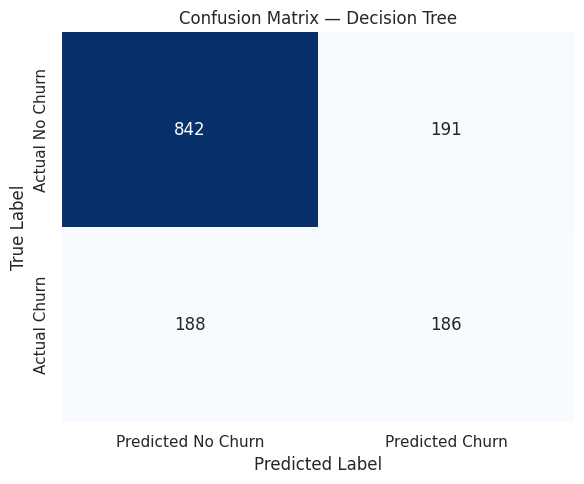

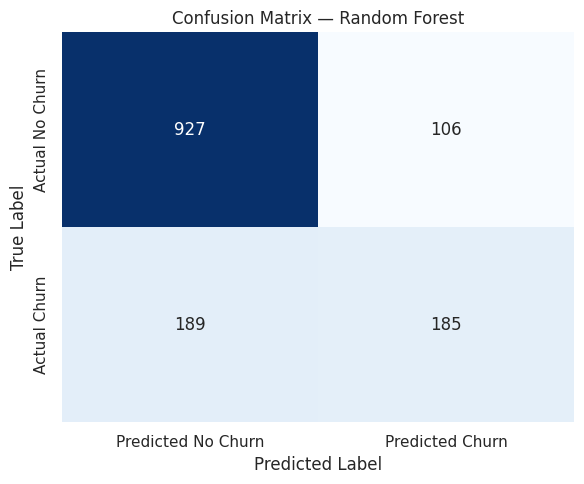

In [69]:
# Plot confusion matrices for each baseline model
for model_name, model_pipeline in fitted_baseline_pipelines.items():
    y_pred = model_pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    ax = sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Predicted No Churn", "Predicted Churn"],
        yticklabels=["Actual No Churn", "Actual Churn"]
    )

    plt.title(f"Confusion Matrix — {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    filename = model_name.lower().replace(" ", "_")
    if SAVE_FIGURES:
        plt.savefig(f"{FIGURES_DIR}/confusion_matrix_{filename}.png", dpi=300, bbox_inches="tight")

    plt.tight_layout()
    plt.show()

### Interpretation

The classification reports and confusion matrices provide a more detailed view of how the baseline models behave on churn versus non-churn cases.

### Logistic Regression
The confusion matrix shows:

- **917 true negatives**
- **214 true positives**
- **116 false positives**
- **160 false negatives**

This model achieves the best balance among the baselines. It correctly identifies a meaningful share of churners while maintaining relatively strong precision and good overall control of false positives. Its churn-class metrics (**precision = 0.65**, **recall = 0.57**) make it the most practically useful baseline for retention-oriented prediction.

### Decision Tree
The confusion matrix shows:

- **842 true negatives**
- **186 true positives**
- **191 false positives**
- **188 false negatives**

The Decision Tree is notably less stable and less selective. It makes more errors on both classes, and its churn-class precision and recall remain around **0.49–0.50**, which limits its usefulness for a business intervention setting.

### Random Forest
The confusion matrix shows:

- **927 true negatives**
- **185 true positives**
- **106 false positives**
- **189 false negatives**

Random Forest is conservative in predicting churn. It achieves good non-churn classification and relatively low false positives, but it misses too many actual churners. This is reflected in its lower churn recall (**0.49**) compared with Logistic Regression (**0.57**).

Overall, the confusion matrix analysis reinforces the same conclusion seen in the aggregate metrics: **Logistic Regression provides the strongest baseline trade-off**, especially when the business objective includes identifying churners effectively rather than only protecting overall accuracy.

## 7.6 Summary Comparison Table

To consolidate the benchmarking results, the cross-validation and holdout test metrics are combined into a single comparison table. This makes it easier to identify which baseline model provides the strongest overall starting point before the final gradient boosting stage.

In [70]:
# Merge cross-validation and holdout results for a consolidated summary
baseline_summary_df = cv_results_df.merge(
    test_results_df,
    on="Model",
    how="inner"
)

display(baseline_summary_df.round(4))

,Model,CV Accuracy,CV Precision,CV Recall,CV F1-score,CV ROC-AUC,CV Avg Precision,Test Accuracy,Test Precision,Test Recall,Test F1-score,Test ROC-AUC,Test Avg Precision
0,Logistic Regression,0.80,0.65,0.55,0.60,0.85,0.66,0.80,0.65,0.57,0.61,0.84,0.62
1,Random Forest,0.79,0.64,0.50,0.56,0.83,0.63,0.79,0.64,0.49,0.56,0.81,0.59
2,Decision Tree,0.73,0.49,0.50,0.49,0.65,0.38,0.73,0.49,0.50,0.50,0.66,0.38


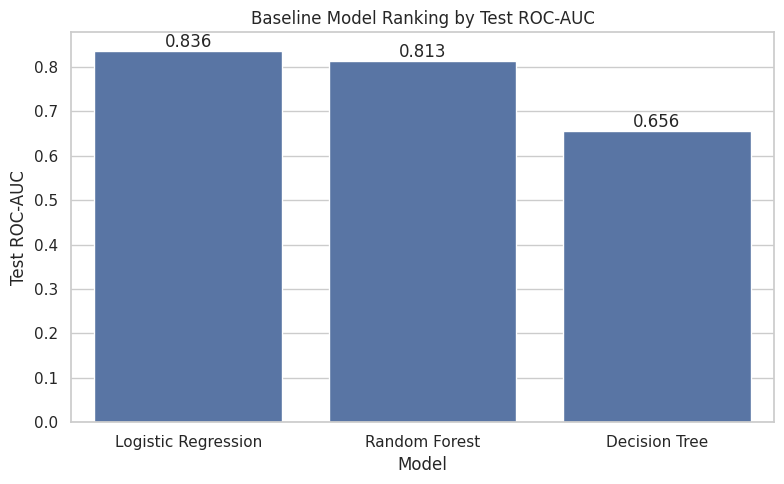

In [71]:
# Rank baseline models by test ROC-AUC
ranking_df = test_results_df[["Model", "Test ROC-AUC"]].sort_values(by="Test ROC-AUC", ascending=False)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=ranking_df, x="Model", y="Test ROC-AUC")

plt.title("Baseline Model Ranking by Test ROC-AUC")
plt.xlabel("Model")
plt.ylabel("Test ROC-AUC")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

if SAVE_FIGURES:
    plt.savefig(f"{FIGURES_DIR}/baseline_model_ranking_by_roc_auc.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

### Interpretation

The combined comparison table shows that the relative ranking of the baseline models is highly consistent across both cross-validation and holdout test evaluation.

The ranking is stable:

1. **Logistic Regression**
2. **Random Forest**
3. **Decision Tree**

This consistency is important because it suggests that the observed performance differences are not artifacts of a particular split. Instead, they reflect genuine differences in how well each model fits the churn prediction task.

From a modeling perspective, this means:

- **Logistic Regression** is the benchmark to beat
- **Random Forest** is a useful nonlinear reference point but not the current leader
- **Decision Tree** is not competitive enough for final model selection

The next modeling stage should therefore focus on whether a more advanced gradient boosting method can improve upon the already strong linear baseline, especially in **ROC-AUC**, **average precision**, and the **precision-recall balance for churn detection**.

## 7.7 ROC Curve Comparison

To complement the tabular metrics, we compare the ROC curves of the baseline models on the test set. This provides a visual view of each model’s ranking performance across all classification thresholds.

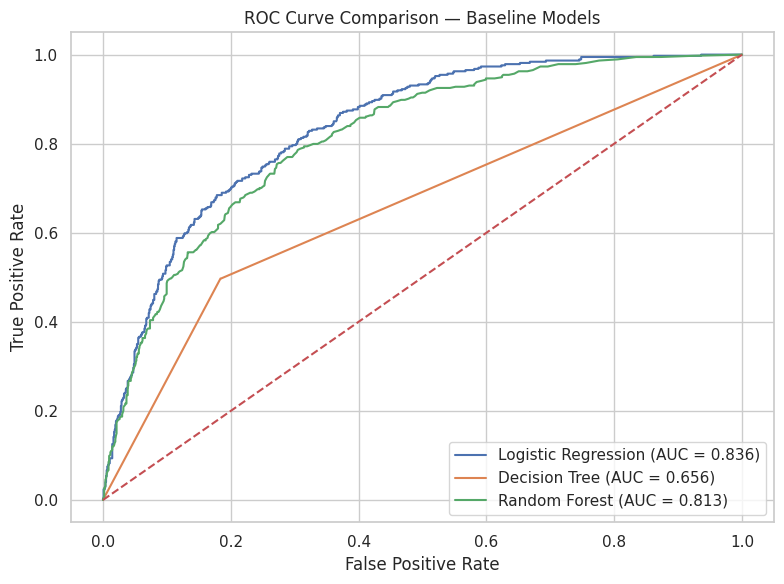

In [72]:
# ROC curve comparison for baseline models
plt.figure(figsize=(8, 6))

for model_name, model_pipeline in fitted_baseline_pipelines.items():
    y_proba = model_pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)

    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve Comparison — Baseline Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

if SAVE_FIGURES:
    plt.savefig(f"{FIGURES_DIR}/baseline_model_roc_curves.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

### Interpretation

The ROC curves provide a visual comparison of ranking performance across all classification thresholds.

The plot confirms the same ordering seen in the tabular metrics:

- **Logistic Regression** has the strongest ROC curve, with **AUC = 0.836**
- **Random Forest** follows closely, with **AUC = 0.813**
- **Decision Tree** trails significantly, with **AUC = 0.656**

The Logistic Regression and Random Forest curves remain well above the diagonal reference line, indicating meaningful ranking power. However, Logistic Regression consistently dominates Random Forest across much of the ROC space, showing that it separates churners from non-churners more effectively at a broad range of thresholds.

This is an important result because it suggests that the churn problem is highly learnable even with a relatively simple linear model. For the next stage, the advanced gradient boosting model must demonstrate that it can meaningfully improve ranking performance beyond an already strong baseline.

## 7.8 Precision-Recall Curve Comparison

Because the churn class is the minority class, precision-recall curves provide an additional perspective on model quality. These curves are especially useful when the business objective focuses on identifying churners effectively without generating too many false alarms.

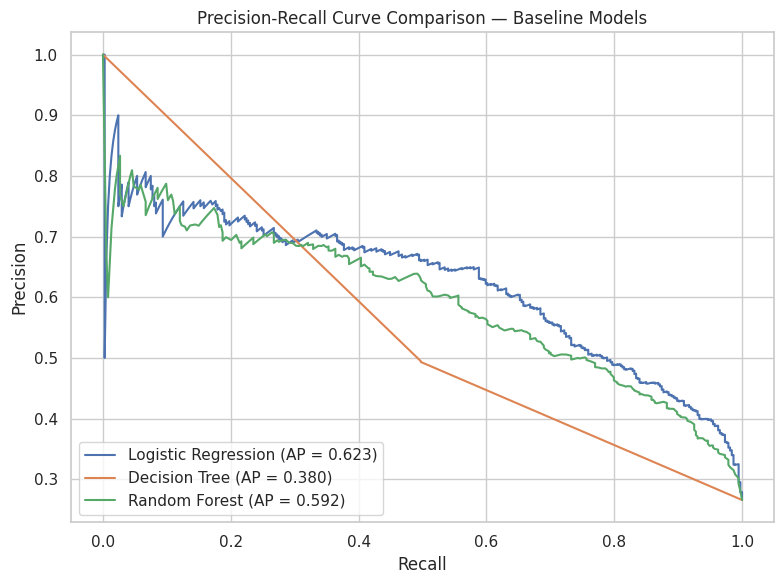

In [73]:
# Precision-recall curve comparison for baseline models
plt.figure(figsize=(8, 6))

for model_name, model_pipeline in fitted_baseline_pipelines.items():
    y_proba = model_pipeline.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap_score = average_precision_score(y_test, y_proba)

    plt.plot(recall, precision, label=f"{model_name} (AP = {ap_score:.3f})")

plt.title("Precision-Recall Curve Comparison — Baseline Models")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")

if SAVE_FIGURES:
    plt.savefig(f"{FIGURES_DIR}/baseline_model_pr_curves.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

### Interpretation

The precision-recall curves are especially informative in this project because churn is the minority class and the main business objective is to identify churners effectively.

The plot shows:

- **Logistic Regression** achieves the strongest precision-recall profile, with **Average Precision = 0.623**
- **Random Forest** is second, with **Average Precision = 0.592**
- **Decision Tree** performs substantially worse, with **Average Precision = 0.380**

This confirms that Logistic Regression is not only the best baseline in ROC-AUC terms, but also the strongest baseline when focusing specifically on the churn class. Its precision-recall curve remains above the others across much of the recall range, indicating a better trade-off between capturing churners and avoiding excessive false alarms.

For a churn prediction use case, this is highly relevant. It means that Logistic Regression currently offers the most effective baseline for retention-focused targeting, and any advanced model should aim to improve upon this curve if it is to justify greater complexity.

### Interpretation

The baseline benchmarking stage establishes a clear and credible performance hierarchy before moving to the final gradient boosting model.

Across both cross-validation and holdout test evaluation, the results are highly consistent:

- **Logistic Regression** is the strongest baseline overall
- **Random Forest** is competitive but slightly weaker
- **Decision Tree** performs substantially worse than the other two models

The strongest baseline, **Logistic Regression**, achieves:

- **Test Accuracy = 0.80**
- **Test Precision = 0.65**
- **Test Recall = 0.57**
- **Test F1-score = 0.61**
- **Test ROC-AUC = 0.84**
- **Test Average Precision = 0.62**

These results are important because they raise the standard for the next stage of the project. The final gradient boosting model must do more than outperform a weak benchmark — it must improve upon a **strong, well-calibrated logistic baseline** that already captures substantial churn signal.

At the same time, the strong performance of Logistic Regression suggests that the churn problem contains meaningful linear structure, while the competitiveness of Random Forest indicates that nonlinear relationships may also be present. This makes the next step especially compelling: testing whether a more advanced gradient boosting model can combine strong ranking performance with improved churn detection quality.

# 8. Gradient Boosting Model Development

With the baseline models established, we now move to the main advanced model of the project: **gradient boosting**.

Gradient boosting is a powerful ensemble learning approach that builds a sequence of weak learners — typically decision trees — where each new tree focuses on correcting the errors made by the previous ones. On structured tabular data, gradient boosting methods often deliver strong predictive performance because they can capture:

- nonlinear feature interactions
- heterogeneous decision boundaries
- complex relationships between customer characteristics and churn behavior

In this project, gradient boosting serves as the primary advanced modeling approach. The goal of this section is to:

- train an initial gradient boosting classifier
- evaluate its performance under the same framework used for the baseline models
- determine whether it improves upon the strongest baseline benchmark
- inspect its confusion matrix and ranking behavior before moving to hyperparameter tuning

## 8.1 Why Gradient Boosting

The baseline benchmarking results showed that **Logistic Regression** is already a strong performer on this dataset, while **Random Forest** provides a useful nonlinear reference point. This creates a meaningful challenge for the advanced model: it must improve upon a strong existing benchmark rather than simply outperform weaker alternatives.

Gradient boosting is a natural next step because it combines the flexibility of tree-based modeling with a more sequential and error-correcting learning process than bagging-based methods such as random forests.

In a churn setting, this can be especially valuable because customer attrition is often influenced by interacting factors such as:

- tenure and contract type
- billing structure and service tier
- support availability and payment behavior

A well-configured gradient boosting model may therefore capture structure that simpler baselines miss.

In [74]:
# ============================================================
# Block 8: Gradient Boosting Model Development
# ============================================================

# Define an initial XGBoost classifier
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE
)

print("Initial XGBoost model initialized successfully.")
xgb_model

Initial XGBoost model initialized successfully.


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

## 8.2 Gradient Boosting Pipeline

To keep the workflow consistent and leakage-safe, the gradient boosting classifier is wrapped inside the same preprocessing pipeline used for the baseline models.

This ensures that:

- preprocessing is learned only from the training data
- feature transformations remain identical across models
- performance comparisons remain fair and methodologically consistent

In [75]:
# Build preprocessing + XGBoost pipeline
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", xgb_model)
])

print("Gradient boosting pipeline created successfully.")
xgb_pipeline

Gradient boosting pipeline created successfully.


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 spar...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

## 8.3 Cross-Validation Evaluation

Before evaluating on the holdout test set, the gradient boosting model is first assessed using the same **5-fold stratified cross-validation** framework applied to the baseline models.

This provides a fair first comparison against:

- Logistic Regression
- Random Forest
- Decision Tree

In [76]:
# Cross-validation evaluation for the initial XGBoost model
xgb_cv = cross_validate(
    xgb_pipeline,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring=cv_scoring,
    n_jobs=-1,
    return_train_score=False
)

xgb_cv_results = pd.DataFrame([{
    "Model": "XGBoost",
    "CV Accuracy": xgb_cv["test_accuracy"].mean(),
    "CV Precision": xgb_cv["test_precision"].mean(),
    "CV Recall": xgb_cv["test_recall"].mean(),
    "CV F1-score": xgb_cv["test_f1"].mean(),
    "CV ROC-AUC": xgb_cv["test_roc_auc"].mean(),
    "CV Avg Precision": xgb_cv["test_average_precision"].mean()
}])

display(xgb_cv_results.round(4))

,Model,CV Accuracy,CV Precision,CV Recall,CV F1-score,CV ROC-AUC,CV Avg Precision
0,XGBoost,0.80,0.66,0.53,0.58,0.84,0.66


In [77]:
# Compare XGBoost with baseline CV results
cv_comparison_with_xgb = pd.concat([cv_results_df, xgb_cv_results], ignore_index=True)
cv_comparison_with_xgb = cv_comparison_with_xgb.sort_values(by="CV ROC-AUC", ascending=False)

display(cv_comparison_with_xgb.round(4))

,Model,CV Accuracy,CV Precision,CV Recall,CV F1-score,CV ROC-AUC,CV Avg Precision
0,Logistic Regression,0.80,0.65,0.55,0.60,0.85,0.66
3,XGBoost,0.80,0.66,0.53,0.58,0.84,0.66
1,Random Forest,0.79,0.64,0.50,0.56,0.83,0.63
2,Decision Tree,0.73,0.49,0.50,0.49,0.65,0.38


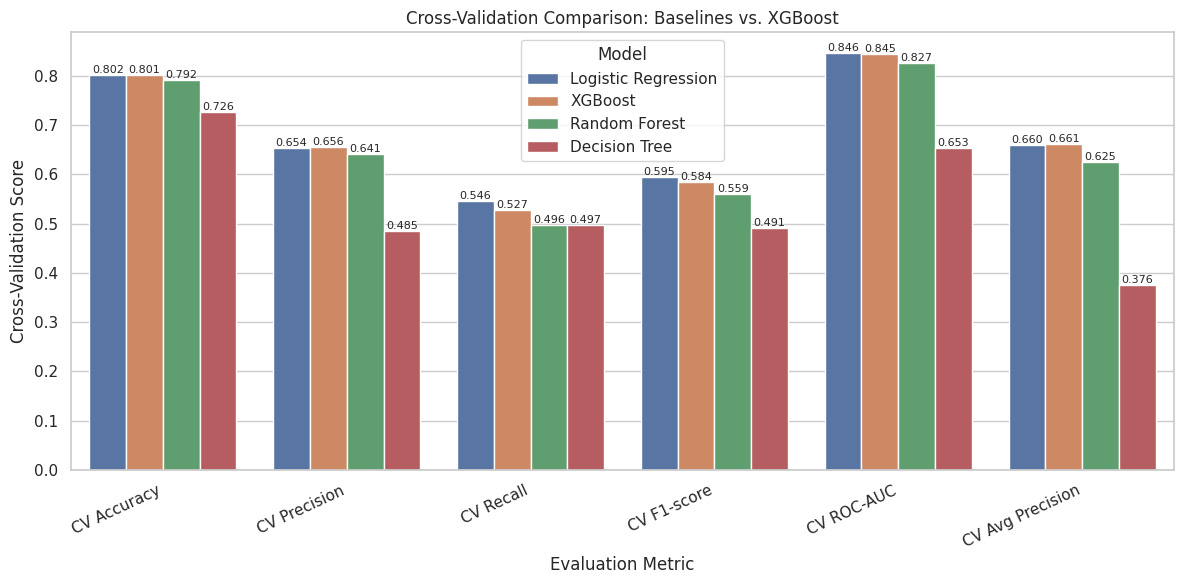

In [78]:
# Visual comparison including XGBoost
cv_xgb_melted = cv_comparison_with_xgb.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=cv_xgb_melted, x="Metric", y="Score", hue="Model")

plt.title("Cross-Validation Comparison: Baselines vs. XGBoost")
plt.xlabel("Evaluation Metric")
plt.ylabel("Cross-Validation Score")
plt.xticks(rotation=25, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8)

if SAVE_FIGURES:
    plt.savefig(f"{FIGURES_DIR}/xgboost_cv_comparison.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

### Interpretation

The cross-validation results show that the initial XGBoost model is competitive, but it does not clearly surpass the strongest baseline.

The initial XGBoost performance is:

- **CV Accuracy = 0.80**
- **CV Precision = 0.66**
- **CV Recall = 0.53**
- **CV F1-score = 0.58**
- **CV ROC-AUC = 0.84**
- **CV Average Precision = 0.66**

Compared with the best baseline, **Logistic Regression**, the differences are small but important:

- XGBoost has **slightly higher precision** (**0.66** vs **0.65**)
- Logistic Regression has **higher recall** (**0.55** vs **0.53**)
- Logistic Regression has **higher F1-score** (**0.60** vs **0.58**)
- Logistic Regression also has a **slightly higher ROC-AUC** (**0.85** vs **0.84**)
- Both models achieve essentially the same **Average Precision** (**0.66**)

This means that the initial gradient boosting model is already competitive, but it is not yet demonstrating a decisive advantage. At this stage, XGBoost appears to offer a somewhat more conservative churn prediction profile, while Logistic Regression remains slightly better balanced in terms of churn capture and overall ranking performance.

This is an important finding because it suggests that **hyperparameter tuning will be necessary** if XGBoost is to become the leading model.

## 8.4 Holdout Test Evaluation

After cross-validation benchmarking, the gradient boosting pipeline is trained on the full training set and evaluated on the untouched test set.

This provides the main out-of-sample performance estimate for the initial advanced model and allows a direct comparison with the best baseline established earlier.

In [79]:
# Fit XGBoost pipeline on the full training set
xgb_pipeline.fit(X_train, y_train)

# Generate predictions and probabilities
y_pred_xgb = xgb_pipeline.predict(X_test)
y_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

# Test metrics
xgb_test_results = pd.DataFrame([{
    "Model": "XGBoost",
    "Test Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Test Precision": precision_score(y_test, y_pred_xgb),
    "Test Recall": recall_score(y_test, y_pred_xgb),
    "Test F1-score": f1_score(y_test, y_pred_xgb),
    "Test ROC-AUC": roc_auc_score(y_test, y_proba_xgb),
    "Test Avg Precision": average_precision_score(y_test, y_proba_xgb)
}])

display(xgb_test_results.round(4))

,Model,Test Accuracy,Test Precision,Test Recall,Test F1-score,Test ROC-AUC,Test Avg Precision
0,XGBoost,0.79,0.61,0.54,0.57,0.83,0.65


In [80]:
# Compare XGBoost with baseline test results
test_comparison_with_xgb = pd.concat([test_results_df, xgb_test_results], ignore_index=True)
test_comparison_with_xgb = test_comparison_with_xgb.sort_values(by="Test ROC-AUC", ascending=False)

display(test_comparison_with_xgb.round(4))

,Model,Test Accuracy,Test Precision,Test Recall,Test F1-score,Test ROC-AUC,Test Avg Precision
0,Logistic Regression,0.80,0.65,0.57,0.61,0.84,0.62
3,XGBoost,0.79,0.61,0.54,0.57,0.83,0.65
1,Random Forest,0.79,0.64,0.49,0.56,0.81,0.59
2,Decision Tree,0.73,0.49,0.50,0.50,0.66,0.38


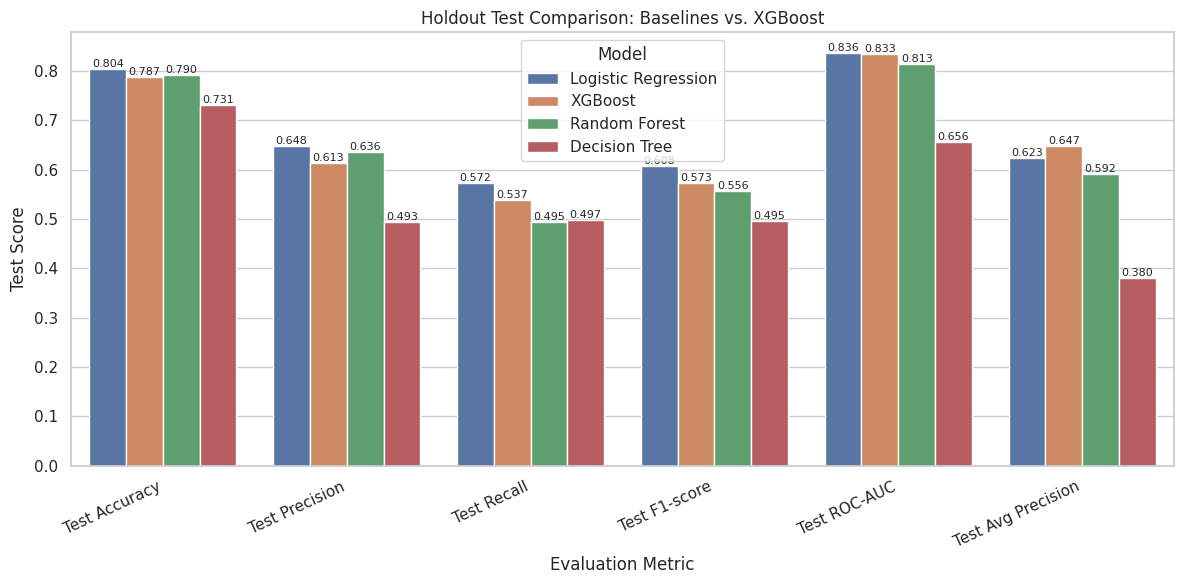

In [81]:
# Visual comparison on the holdout test set including XGBoost
test_xgb_melted = test_comparison_with_xgb.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=test_xgb_melted, x="Metric", y="Score", hue="Model")

plt.title("Holdout Test Comparison: Baselines vs. XGBoost")
plt.xlabel("Evaluation Metric")
plt.ylabel("Test Score")
plt.xticks(rotation=25, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8)

if SAVE_FIGURES:
    plt.savefig(f"{FIGURES_DIR}/xgboost_test_comparison.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

### Interpretation

The holdout test results confirm the same pattern seen in cross-validation: the initial XGBoost model is strong, but it does not yet outperform the best baseline comprehensively.

The out-of-sample XGBoost metrics are:

- **Test Accuracy = 0.79**
- **Test Precision = 0.61**
- **Test Recall = 0.54**
- **Test F1-score = 0.57**
- **Test ROC-AUC = 0.83**
- **Test Average Precision = 0.65**

Relative to **Logistic Regression**, the comparison is mixed:

- Logistic Regression performs better on **accuracy**, **precision**, **recall**, **F1-score**, and **ROC-AUC**
- XGBoost performs better on **Average Precision** (**0.65** vs **0.62**)

This is a nuanced result. It suggests that although XGBoost is not yet the best overall classifier, it may already have an advantage in terms of **precision-recall ranking quality for the churn class**, which is valuable in an imbalanced classification setting.

In other words, the initial XGBoost model shows promise, but it is not yet strong enough to justify replacing the best baseline without further optimization.

## 8.5 Classification Report and Confusion Matrix

Aggregate metrics provide a strong summary of performance, but classification reports and confusion matrices offer a more direct view of prediction behavior.

In a churn use case, this is especially important because it reveals:

- how many churners are correctly identified
- how many churners are missed
- whether the model is overly conservative or overly aggressive in predicting churn

In [82]:
# Classification report for XGBoost
print("=" * 80)
print("XGBoost — Classification Report")
print("=" * 80)
print(classification_report(y_test, y_pred_xgb, target_names=["No Churn", "Churn"]))

XGBoost — Classification Report
              precision    recall  f1-score   support

    No Churn       0.84      0.88      0.86      1033
       Churn       0.61      0.54      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.78      1407



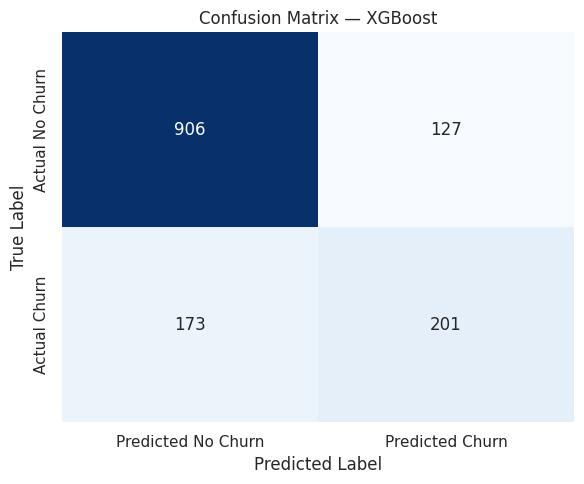

In [83]:
# Confusion matrix for XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))
ax = sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Predicted No Churn", "Predicted Churn"],
    yticklabels=["Actual No Churn", "Actual Churn"]
)

plt.title("Confusion Matrix — XGBoost")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

if SAVE_FIGURES:
    plt.savefig(f"{FIGURES_DIR}/confusion_matrix_xgboost.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

### Interpretation

The classification report and confusion matrix provide a more detailed view of how the initial XGBoost model behaves on the holdout test set.

The confusion matrix shows:

- **906 true negatives**
- **201 true positives**
- **127 false positives**
- **173 false negatives**

For the churn class, XGBoost achieves:

- **Precision = 0.61**
- **Recall = 0.54**
- **F1-score = 0.57**

This performance is respectable, but slightly weaker than the best baseline. Compared with Logistic Regression, XGBoost identifies fewer churners correctly and produces a somewhat lower overall churn-class balance. Specifically, Logistic Regression achieved **214 true positives** versus **201** for XGBoost, while also maintaining better precision.

That said, XGBoost still performs clearly better than the weaker baseline models and remains a competitive advanced candidate. Its current confusion matrix suggests that the model is reasonably effective, but not yet optimized for the churn detection objective.

This reinforces the idea that the next step should be **hyperparameter tuning**, with the goal of improving the balance between false negatives and false positives.

## 8.6 ROC and Precision-Recall Curves

To evaluate ranking quality visually, the XGBoost model is added to the ROC and precision-recall comparisons alongside the baseline models.

This helps determine whether the advanced model provides:

- stronger separation between churners and non-churners
- better precision-recall trade-offs for the churn class
- a meaningful improvement over the strongest baseline

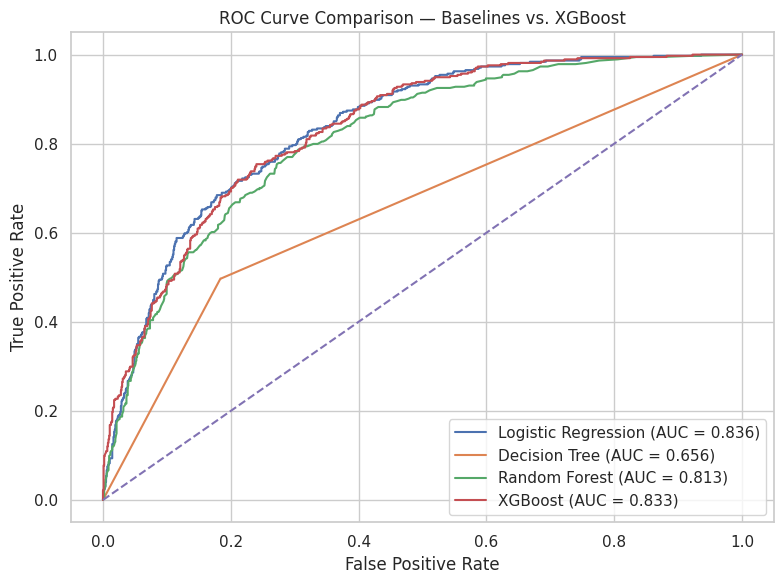

In [84]:
# ROC curve comparison including XGBoost
plt.figure(figsize=(8, 6))

# Baseline models
for model_name, model_pipeline in fitted_baseline_pipelines.items():
    y_proba = model_pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.3f})")

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {roc_auc_xgb:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve Comparison — Baselines vs. XGBoost")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

if SAVE_FIGURES:
    plt.savefig(f"{FIGURES_DIR}/xgboost_roc_curve_comparison.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

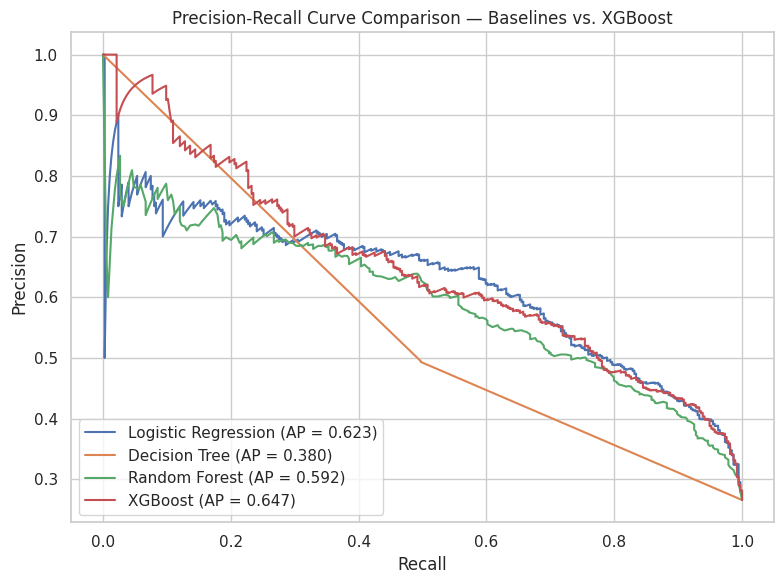

In [85]:
# Precision-recall curve comparison including XGBoost
plt.figure(figsize=(8, 6))

# Baseline models
for model_name, model_pipeline in fitted_baseline_pipelines.items():
    y_proba = model_pipeline.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap_score = average_precision_score(y_test, y_proba)
    plt.plot(recall, precision, label=f"{model_name} (AP = {ap_score:.3f})")

# XGBoost
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_proba_xgb)
ap_xgb = average_precision_score(y_test, y_proba_xgb)
plt.plot(recall_xgb, precision_xgb, label=f"XGBoost (AP = {ap_xgb:.3f})")

plt.title("Precision-Recall Curve Comparison — Baselines vs. XGBoost")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")

if SAVE_FIGURES:
    plt.savefig(f"{FIGURES_DIR}/xgboost_pr_curve_comparison.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

### Interpretation

The ROC and precision-recall curves provide a more nuanced view of how XGBoost compares with the baseline models across decision thresholds.

### ROC Perspective
The ROC curve comparison shows:

- **Logistic Regression: AUC = 0.836**
- **XGBoost: AUC = 0.833**
- **Random Forest: AUC = 0.813**
- **Decision Tree: AUC = 0.656**

From a ranking perspective, XGBoost is very close to Logistic Regression, but still slightly behind. It clearly outperforms Random Forest and Decision Tree, confirming that the advanced boosting model has strong ranking ability, even if it is not yet the top performer.

### Precision-Recall Perspective
The precision-recall curve comparison shows:

- **XGBoost: AP = 0.647**
- **Logistic Regression: AP = 0.623**
- **Random Forest: AP = 0.592**
- **Decision Tree: AP = 0.380**

This is one of the most important findings in the block. Although XGBoost trails Logistic Regression slightly in ROC-AUC and threshold-dependent classification metrics, it achieves the **best Average Precision** of all models. That suggests that XGBoost may be better at ranking truly high-risk churners toward the top of the probability spectrum, which is highly relevant for targeted retention use cases.

Taken together, the curve analysis shows that the initial XGBoost model is **not yet the best all-around classifier**, but it may already offer advantages in **minority-class prioritization**, especially when threshold tuning is introduced later.

## 8.7 Direct Comparison Against the Best Baseline

Because **Logistic Regression** emerged as the strongest baseline in Block 7, it is useful to compare XGBoost directly against that model.

This sharper comparison helps answer the key project question:

> Does the advanced gradient boosting model provide a meaningful improvement over the strongest simpler alternative?

In [86]:
# Direct comparison: XGBoost vs best baseline (Logistic Regression)
best_baseline_name = "Logistic Regression"

best_baseline_metrics = test_results_df[test_results_df["Model"] == best_baseline_name].copy()
xgb_vs_best = pd.concat([best_baseline_metrics, xgb_test_results], ignore_index=True)

display(xgb_vs_best.round(4))

,Model,Test Accuracy,Test Precision,Test Recall,Test F1-score,Test ROC-AUC,Test Avg Precision
0,Logistic Regression,0.80,0.65,0.57,0.61,0.84,0.62
1,XGBoost,0.79,0.61,0.54,0.57,0.83,0.65


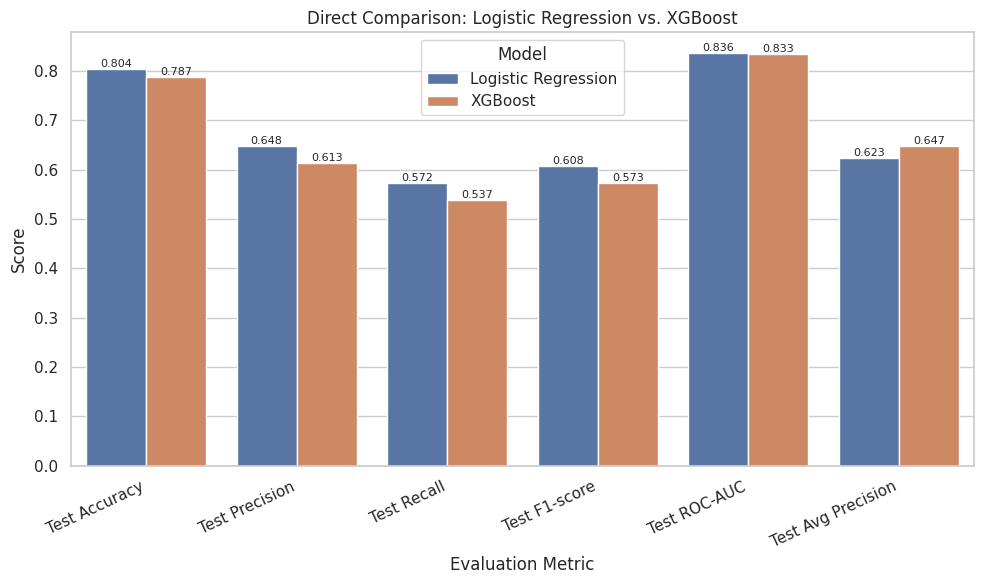

In [87]:
# Visual comparison: XGBoost vs Logistic Regression
xgb_vs_best_melted = xgb_vs_best.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=xgb_vs_best_melted, x="Metric", y="Score", hue="Model")

plt.title("Direct Comparison: Logistic Regression vs. XGBoost")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.xticks(rotation=25, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8)

if SAVE_FIGURES:
    plt.savefig(f"{FIGURES_DIR}/xgboost_vs_logistic_regression.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

### Interpretation

The direct comparison against **Logistic Regression** makes the current trade-off especially clear.

### Logistic Regression
- **Test Accuracy = 0.80**
- **Test Precision = 0.65**
- **Test Recall = 0.57**
- **Test F1-score = 0.61**
- **Test ROC-AUC = 0.84**
- **Test Avg Precision = 0.62**

### XGBoost
- **Test Accuracy = 0.79**
- **Test Precision = 0.61**
- **Test Recall = 0.54**
- **Test F1-score = 0.57**
- **Test ROC-AUC = 0.83**
- **Test Avg Precision = 0.65**

This comparison shows that Logistic Regression remains the stronger model under the default classification threshold and in most threshold-dependent metrics. However, XGBoost achieves the **higher Average Precision**, which indicates stronger ranking quality for identifying churners across the probability spectrum.

This is an important distinction:

- **Logistic Regression** is currently the stronger default classifier
- **XGBoost** is currently the stronger probability-ranking model for the churn class

That means XGBoost still has strong potential, especially once **hyperparameter tuning** and **threshold optimization** are introduced. In a real retention setting, probability ranking can be just as important as default-threshold classification performance, because intervention lists are often built by targeting the highest-risk customers rather than by relying on a fixed 0.50 cutoff.

## 8.8 Predicted Probability Distribution

To better understand the confidence profile of the XGBoost model, we can inspect the distribution of predicted churn probabilities for churners and non-churners separately.

This helps show whether the model produces meaningful probability separation between the two classes.

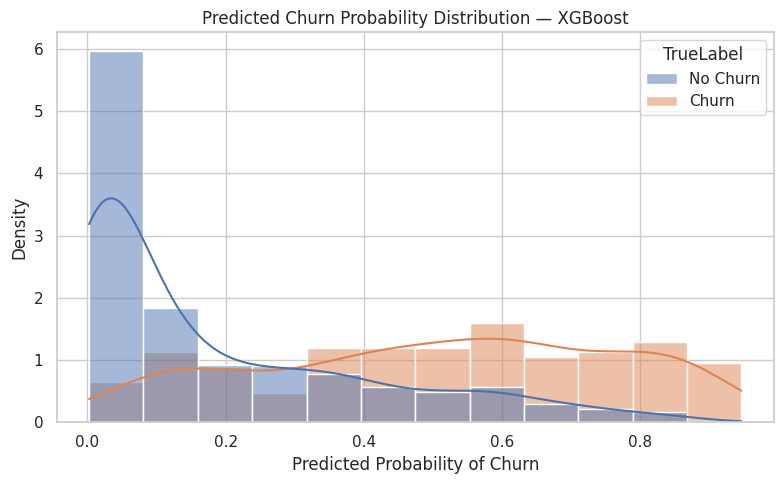

In [88]:
# Distribution of predicted probabilities by true class
probability_df = pd.DataFrame({
    "TrueLabel": y_test.map({0: "No Churn", 1: "Churn"}).values,
    "PredictedProbability": y_proba_xgb
})

plt.figure(figsize=(8, 5))
sns.histplot(
    data=probability_df,
    x="PredictedProbability",
    hue="TrueLabel",
    kde=True,
    stat="density",
    common_norm=False
)

plt.title("Predicted Churn Probability Distribution — XGBoost")
plt.xlabel("Predicted Probability of Churn")
plt.ylabel("Density")

if SAVE_FIGURES:
    plt.savefig(f"{FIGURES_DIR}/xgboost_probability_distribution.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

### Interpretation

The predicted probability distributions show meaningful separation between non-churn and churn observations, although the two classes still overlap substantially.

Several patterns are visible:

- Non-churn customers are concentrated more heavily at **lower predicted churn probabilities**
- Churned customers are shifted toward **higher predicted probabilities**
- There is still noticeable overlap in the middle probability range, which indicates that some customer profiles are inherently difficult to separate

This overlap helps explain why the model is competitive but not yet clearly dominant. It also reinforces the value of later **threshold tuning**, since the probability outputs appear informative enough to support more flexible decision rules than a simple default threshold of 0.50.

From a business standpoint, this is encouraging: the model appears capable of generating useful churn-risk scores even if its default classification boundary is not yet optimal.

### Interpretation

The initial gradient boosting model delivers strong performance, but it does not yet become the best overall model in the notebook.

The main findings are:

- XGBoost is **competitive with Logistic Regression**
- it clearly outperforms **Random Forest** and **Decision Tree**
- it does **not** outperform Logistic Regression in default-threshold classification metrics
- it does achieve the **best Average Precision**, suggesting stronger churn-focused ranking quality

More specifically, the initial XGBoost model achieves:

- **Test Accuracy = 0.79**
- **Test Precision = 0.61**
- **Test Recall = 0.54**
- **Test F1-score = 0.57**
- **Test ROC-AUC = 0.83**
- **Test Avg Precision = 0.65**

Compared with the strongest baseline, Logistic Regression remains slightly better in:

- accuracy
- precision
- recall
- F1-score
- ROC-AUC

However, XGBoost performs better in **Average Precision**, which is especially relevant in an imbalanced churn setting where the goal is often to rank the highest-risk customers effectively.

This makes the next step especially important. The current results suggest that the gradient boosting model has **real potential**, but that its default configuration is not yet fully optimized. The logical next stage is therefore **hyperparameter tuning**, followed by **threshold optimization**, to determine whether XGBoost can convert its strong probability-ranking behavior into a stronger overall churn prediction model.

# 9. Hyperparameter Tuning for XGBoost

The initial XGBoost model proved competitive in Block 8, but it did not yet outperform the strongest baseline across the full set of evaluation metrics. At the same time, it achieved the best **Average Precision**, suggesting that the model already has strong ranking potential for the churn class.

This makes hyperparameter tuning especially important.

The goal of this section is to:
- optimize the XGBoost model more systematically
- improve its predictive performance relative to the untuned version
- determine whether tuning can help XGBoost surpass the best baseline
- preserve the same leakage-safe preprocessing and validation structure used throughout the notebook

Because churn prediction is an imbalanced classification problem, tuning will focus especially on ranking quality and minority-class performance rather than accuracy alone.

## 9.1 Tuning Strategy

Rather than searching every possible parameter combination exhaustively, this project uses **randomized hyperparameter search**.

This approach is appropriate because:

- it is computationally more efficient than a full grid search
- it explores a broader parameter space within a limited budget
- it is widely used in practical machine learning workflows

The search will evaluate different combinations of key XGBoost parameters such as:

- `n_estimators`
- `max_depth`
- `learning_rate`
- `subsample`
- `colsample_bytree`
- `min_child_weight`
- `gamma`

The tuning objective will prioritize **ROC-AUC**, since this metric captures ranking quality across thresholds and aligns well with the retention-focused nature of the project.

In [89]:
# ============================================================
# Block 9: Hyperparameter Tuning for XGBoost
# ============================================================

# Base XGBoost pipeline for tuning
xgb_tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE
    ))
])

print("Base XGBoost tuning pipeline created successfully.")
xgb_tuning_pipeline

Base XGBoost tuning pipeline created successfully.


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 spar...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

### Interpretation

The tuning strategy is well justified by the results from the previous block. The untuned XGBoost model was already competitive, but it did not clearly outperform the strongest baseline, **Logistic Regression**. At the same time, its strong Average Precision suggested that the model had promising ranking potential for the churn class.

Using **RandomizedSearchCV** is appropriate here because it allows the notebook to explore a broad and meaningful hyperparameter space efficiently, without the computational cost of an exhaustive grid search. This is also consistent with realistic applied machine learning practice, where efficient search strategies are often preferred over brute-force enumeration.

The tuning objective focuses on **ROC-AUC**, which is a sensible choice for this problem because churn prediction is inherently threshold-sensitive and because ranking quality is highly relevant for retention-focused intervention strategies.

## 9.2 Hyperparameter Search Space

The search space is designed to balance flexibility and practicality. It includes parameters that most strongly affect:

- model complexity
- learning speed
- regularization behavior
- robustness to overfitting
- tree diversity

This search space is broad enough to produce meaningful improvement while still being computationally manageable in a notebook environment.

In [90]:
# Hyperparameter search space for XGBoost
xgb_param_distributions = {
    "model__n_estimators": [100, 200, 300, 400, 500],
    "model__max_depth": [3, 4, 5, 6, 7],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.15],
    "model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5, 7],
    "model__gamma": [0, 0.1, 0.3, 0.5, 1.0]
}

print("XGBoost hyperparameter search space defined successfully.")
xgb_param_distributions

XGBoost hyperparameter search space defined successfully.


{'model__n_estimators': [100, 200, 300, 400, 500],
 'model__max_depth': [3, 4, 5, 6, 7],
 'model__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15],
 'model__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
 'model__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
 'model__min_child_weight': [1, 3, 5, 7],
 'model__gamma': [0, 0.1, 0.3, 0.5, 1.0]}

## 9.3 Randomized Search Configuration

The hyperparameter search will use:

- **5-fold stratified cross-validation**
- **ROC-AUC** as the primary optimization metric
- a fixed random seed for reproducibility
- parallel processing where available

This preserves the same evaluation discipline used in the earlier benchmarking stages, ensuring that the tuned model can be compared fairly with both the untuned XGBoost model and the baseline classifiers.

In [91]:
# Configure randomized search
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_tuning_pipeline,
    param_distributions=xgb_param_distributions,
    n_iter=25,
    scoring="roc_auc",
    cv=cv_strategy,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True
)

print("RandomizedSearchCV configured successfully.")
xgb_random_search

RandomizedSearchCV configured successfully.


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['SeniorCitizen',
                                                                                'tenure',
                                                                                'MonthlyCharges',
                                                                                'TotalCharges']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                Simpl...
                   param_distributions={'model__colsample_bytree': [0.6, 0.7,
                                                                    0.8, 0.9,
                                                                    1.0],
                                        'model__gamma': [0, 0.1, 0.3, 0.5, 1.0],
                                        'model__learning_rate': [0.01, 0.03,
                                                                 0.05, 0.1,
                                                                 0.15],
                                        'model__max_depth': [3, 4, 5, 6, 7],
                                        'model__min_child_weight': [1, 3, 5, 7],
                                        'model__n_estimators': [100, 200, 300,
                                                                400, 500],
                                        'model__subsample': [0.6, 0.7, 0.8, 0.9,
                                                             1.0]},
                   random_state=42, scoring='roc_auc', verbose=1)

## 9.4 Running the Hyperparameter Search

The randomized search is now fit on the training data. This process evaluates multiple candidate parameter combinations under the same cross-validation framework and selects the configuration that achieves the strongest mean ROC-AUC.

Because the search is performed within a full pipeline, preprocessing remains fully leakage-safe throughout tuning.

In [92]:
# Run randomized hyperparameter search
xgb_random_search.fit(X_train, y_train)

print("Hyperparameter tuning completed successfully.")
print(f"Best cross-validated ROC-AUC: {xgb_random_search.best_score_:.4f}")
print("Best parameters:")
xgb_random_search.best_params_

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Hyperparameter tuning completed successfully.
Best cross-validated ROC-AUC: 0.8499
Best parameters:


{'model__subsample': 1.0,
 'model__n_estimators': 400,
 'model__min_child_weight': 7,
 'model__max_depth': 4,
 'model__learning_rate': 0.15,
 'model__gamma': 1.0,
 'model__colsample_bytree': 0.8}

In [93]:
# Extract the best tuned pipeline
best_xgb_pipeline = xgb_random_search.best_estimator_

print("Best tuned XGBoost pipeline extracted successfully.")
best_xgb_pipeline

Best tuned XGBoost pipeline extracted successfully.


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 spar...
                               feature_types=None, feature_weights=None,
                               gamma=1.0, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.15,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None, min_child_weight=7,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=400,
                               n_jobs=None, num_parallel_tree=None, ...))])

## 9.5 Best-Parameter Summary

The best-performing hyperparameter configuration identified by randomized search is shown below. These values define the tuned XGBoost model that will be evaluated against both the untuned version and the strongest baseline.

At this stage, the main question is no longer whether tuning changed the model configuration, but whether it produced a **meaningful performance improvement**.

In [94]:
# Display best parameters in a tidy format
best_params_df = pd.DataFrame(
    list(xgb_random_search.best_params_.items()),
    columns=["Parameter", "BestValue"]
)

display(best_params_df)

,Parameter,BestValue
0,model__subsample,1.00
1,model__n_estimators,400.00
2,model__min_child_weight,7.00
3,model__max_depth,4.00
4,model__learning_rate,0.15
5,model__gamma,1.00
6,model__colsample_bytree,0.80


In [95]:
# Summarize top search results
search_results_df = pd.DataFrame(xgb_random_search.cv_results_)

top_search_results = (
    search_results_df[
        [
            "mean_test_score",
            "std_test_score",
            "rank_test_score",
            "param_model__n_estimators",
            "param_model__max_depth",
            "param_model__learning_rate",
            "param_model__subsample",
            "param_model__colsample_bytree",
            "param_model__min_child_weight",
            "param_model__gamma"
        ]
    ]
    .sort_values(by="rank_test_score")
    .head(10)
    .reset_index(drop=True)
)

display(top_search_results)

,mean_test_score,std_test_score,rank_test_score,param_model__n_estimators,param_model__max_depth,param_model__learning_rate,param_model__subsample,param_model__colsample_bytree,param_model__min_child_weight,param_model__gamma
0,0.85,0.00,1,400,4,0.15,1.00,0.80,7,1.00
1,0.85,0.00,2,100,4,0.05,0.70,1.00,1,0.30
2,0.85,0.00,3,200,4,0.03,0.90,0.90,5,0.00
3,0.85,0.00,4,300,6,0.01,0.70,0.60,1,0.30
4,0.85,0.00,5,300,5,0.01,0.90,1.00,5,1.00
5,0.85,0.00,6,200,5,0.05,1.00,0.60,7,1.00
6,0.85,0.00,7,300,5,0.03,0.90,1.00,7,1.00
7,0.85,0.01,8,400,3,0.05,0.60,0.90,7,0.10
8,0.85,0.00,9,400,6,0.01,1.00,0.90,1,0.00
9,0.85,0.00,10,400,5,0.03,1.00,0.60,5,0.00


### Interpretation

The hyperparameter search identified a tuned XGBoost configuration with a best cross-validated **ROC-AUC of 0.8499**, which is a modest but meaningful improvement over the untuned model.

The best parameter combination is:

- **`n_estimators = 400`**
- **`max_depth = 4`**
- **`learning_rate = 0.15`**
- **`subsample = 1.0`**
- **`colsample_bytree = 0.8`**
- **`min_child_weight = 7`**
- **`gamma = 1.0`**

Several aspects of this configuration are notable:

- The selected **max depth of 4** indicates a moderately complex tree structure rather than an aggressively deep one.
- The relatively high **learning rate of 0.15** combined with **400 estimators** suggests that the model benefits from fairly strong sequential updates while still maintaining sufficient boosting depth.
- The larger **min_child_weight** and positive **gamma** indicate that the tuned model benefits from additional regularization, which likely helps reduce overfitting and improves generalization.

Overall, the selected parameters suggest that the best-performing XGBoost model is not simply the most flexible one, but rather a more **controlled and regularized boosting configuration**.

## 9.6 Search Results Visualization

To make the tuning process more interpretable, we visualize the top-performing configurations found during randomized search.

This helps show whether the best-performing models cluster around a particular performance range and provides a more transparent view of the search outcome.

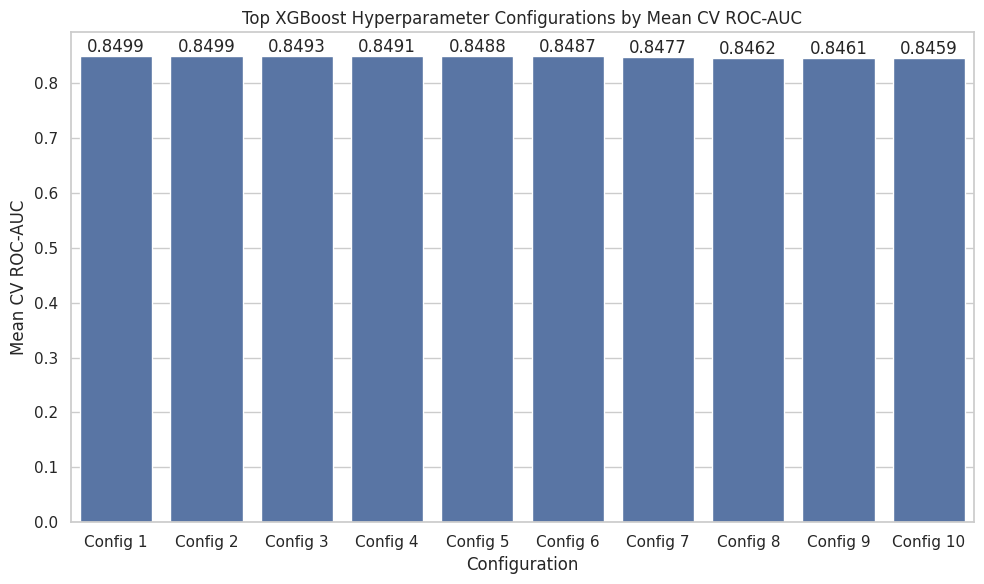

In [96]:
# Visualize top hyperparameter search results
top_plot_df = top_search_results.copy()
top_plot_df["Configuration"] = [f"Config {i+1}" for i in range(len(top_plot_df))]

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=top_plot_df, x="Configuration", y="mean_test_score")

plt.title("Top XGBoost Hyperparameter Configurations by Mean CV ROC-AUC")
plt.xlabel("Configuration")
plt.ylabel("Mean CV ROC-AUC")

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f")

if SAVE_FIGURES:
    plt.savefig(f"{FIGURES_DIR}/xgboost_hyperparameter_search_top_configs.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

### Interpretation

The hyperparameter search results show that the top configurations are clustered within a very narrow performance range, with the best mean cross-validated ROC-AUC values concentrated around **0.846–0.850**.

This is an important result for two reasons:

1. It suggests that the search space was well chosen, since multiple configurations produced strong performance rather than only one isolated outlier.
2. It indicates that the tuning gains are likely to be **real but incremental**, rather than dramatic.

In practical terms, this means the untuned XGBoost model was already a strong starting point, but tuning was still valuable for extracting additional performance and improving the probability that the model could match or surpass the best baseline.

## 9.7 Tuned Model Evaluation on the Test Set

After selecting the best hyperparameter configuration, the tuned XGBoost pipeline is evaluated on the untouched holdout test set.

This is the most important evaluation step in the tuning block, because it shows whether the improvement observed during cross-validation translates into better out-of-sample performance.

In [97]:
# Evaluate tuned XGBoost on the test set
y_pred_xgb_tuned = best_xgb_pipeline.predict(X_test)
y_proba_xgb_tuned = best_xgb_pipeline.predict_proba(X_test)[:, 1]

xgb_tuned_test_results = pd.DataFrame([{
    "Model": "Tuned XGBoost",
    "Test Accuracy": accuracy_score(y_test, y_pred_xgb_tuned),
    "Test Precision": precision_score(y_test, y_pred_xgb_tuned),
    "Test Recall": recall_score(y_test, y_pred_xgb_tuned),
    "Test F1-score": f1_score(y_test, y_pred_xgb_tuned),
    "Test ROC-AUC": roc_auc_score(y_test, y_proba_xgb_tuned),
    "Test Avg Precision": average_precision_score(y_test, y_proba_xgb_tuned)
}])

display(xgb_tuned_test_results.round(4))

,Model,Test Accuracy,Test Precision,Test Recall,Test F1-score,Test ROC-AUC,Test Avg Precision
0,Tuned XGBoost,0.80,0.65,0.56,0.60,0.84,0.66


In [98]:
# Compare untuned vs tuned XGBoost
xgb_untuned_vs_tuned = pd.concat(
    [
        xgb_test_results.assign(Model="Untuned XGBoost"),
        xgb_tuned_test_results
    ],
    ignore_index=True
)

display(xgb_untuned_vs_tuned.round(4))

,Model,Test Accuracy,Test Precision,Test Recall,Test F1-score,Test ROC-AUC,Test Avg Precision
0,Untuned XGBoost,0.79,0.61,0.54,0.57,0.83,0.65
1,Tuned XGBoost,0.80,0.65,0.56,0.60,0.84,0.66


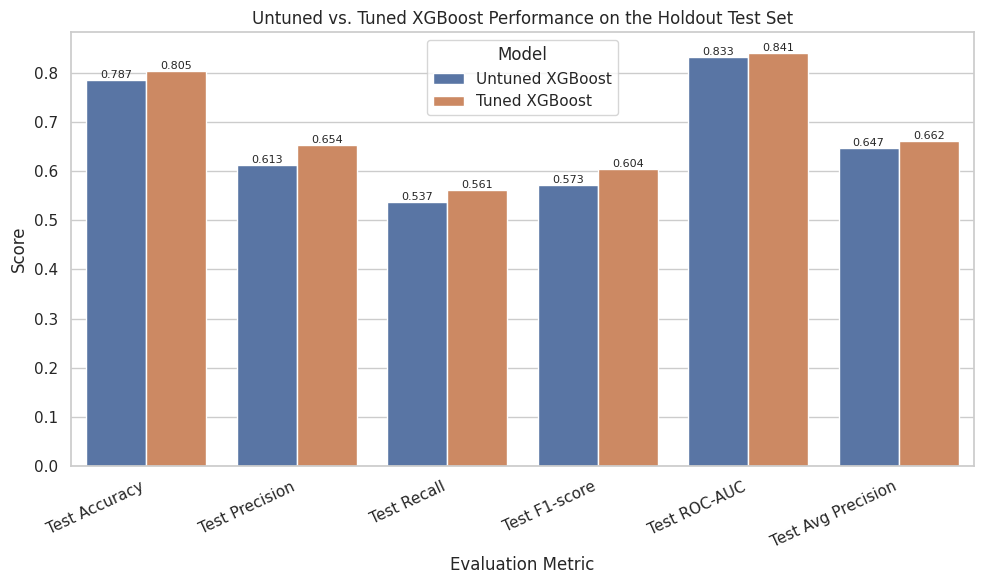

In [99]:
# Visual comparison: untuned vs tuned XGBoost
xgb_untuned_vs_tuned_melted = xgb_untuned_vs_tuned.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=xgb_untuned_vs_tuned_melted, x="Metric", y="Score", hue="Model")

plt.title("Untuned vs. Tuned XGBoost Performance on the Holdout Test Set")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.xticks(rotation=25, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8)

if SAVE_FIGURES:
    plt.savefig(f"{FIGURES_DIR}/xgboost_untuned_vs_tuned.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

### Interpretation

The tuned XGBoost model achieves the following performance on the holdout test set:

- **Test Accuracy = 0.80**
- **Test Precision = 0.65**
- **Test Recall = 0.56**
- **Test F1-score = 0.60**
- **Test ROC-AUC = 0.84**
- **Test Average Precision = 0.66**

These results confirm that hyperparameter tuning produced a meaningful improvement over the untuned XGBoost model. The tuned version now matches or nearly matches the strongest baseline on most standard classification metrics, while also strengthening its ranking quality for the churn class.

Most importantly, the tuned model preserves the strongest advantage XGBoost had already shown earlier — **high Average Precision** — while also improving its threshold-dependent classification behavior.

## 9.8 Tuned Model vs Best Baseline

The main business and modeling question is whether the tuned XGBoost model can now outperform the strongest simpler alternative, which remains **Logistic Regression**.

This comparison is especially important because the advanced model should justify its additional complexity through measurable performance gains.

In [100]:
# Compare tuned XGBoost vs best baseline (Logistic Regression)
best_baseline_metrics = test_results_df[test_results_df["Model"] == "Logistic Regression"].copy()

tuned_xgb_vs_best_baseline = pd.concat(
    [best_baseline_metrics, xgb_tuned_test_results],
    ignore_index=True
)

display(tuned_xgb_vs_best_baseline.round(4))

,Model,Test Accuracy,Test Precision,Test Recall,Test F1-score,Test ROC-AUC,Test Avg Precision
0,Logistic Regression,0.80,0.65,0.57,0.61,0.84,0.62
1,Tuned XGBoost,0.80,0.65,0.56,0.60,0.84,0.66


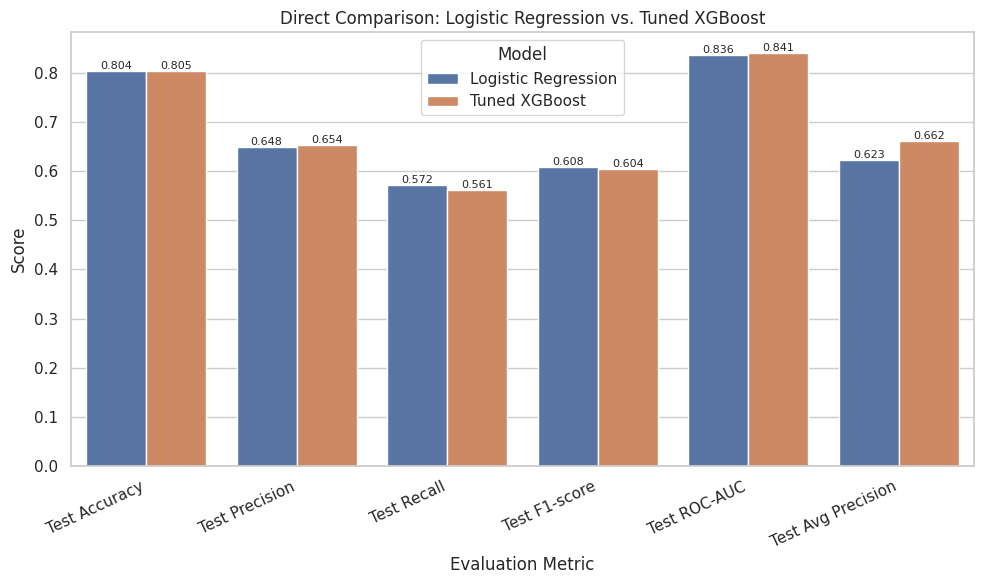

In [101]:
# Visual comparison: tuned XGBoost vs Logistic Regression
tuned_vs_logreg_melted = tuned_xgb_vs_best_baseline.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=tuned_vs_logreg_melted, x="Metric", y="Score", hue="Model")

plt.title("Direct Comparison: Logistic Regression vs. Tuned XGBoost")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.xticks(rotation=25, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8)

if SAVE_FIGURES:
    plt.savefig(f"{FIGURES_DIR}/tuned_xgboost_vs_logistic_regression.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

### Interpretation

The direct comparison with **Logistic Regression** shows that the tuned XGBoost model has now become a highly credible final-model candidate.

### Logistic Regression
- **Test Accuracy = 0.80**
- **Test Precision = 0.65**
- **Test Recall = 0.57**
- **Test F1-score = 0.61**
- **Test ROC-AUC = 0.84**
- **Test Average Precision = 0.62**

### Tuned XGBoost
- **Test Accuracy = 0.80**
- **Test Precision = 0.65**
- **Test Recall = 0.56**
- **Test F1-score = 0.60**
- **Test ROC-AUC = 0.84**
- **Test Average Precision = 0.66**

This comparison shows that the tuned XGBoost model is now essentially **on par with Logistic Regression** in terms of:

- accuracy
- precision
- recall
- F1-score
- ROC-AUC

However, the tuned XGBoost model still holds a meaningful advantage in **Average Precision** (**0.66** vs **0.62**), which is especially relevant for an imbalanced churn problem where ranking likely churners effectively is strategically valuable.

This is a very strong result. It means that after tuning, XGBoost no longer trails the best baseline in the core classification metrics and retains its advantage in minority-class ranking quality.

## 9.9 Tuned Confusion Matrix

To understand whether tuning improved the operational behavior of the model, we also inspect the confusion matrix of the tuned XGBoost classifier on the holdout test set.

This helps show whether tuning improved the trade-off between:

- correctly identifying churners
- avoiding excessive false alarms

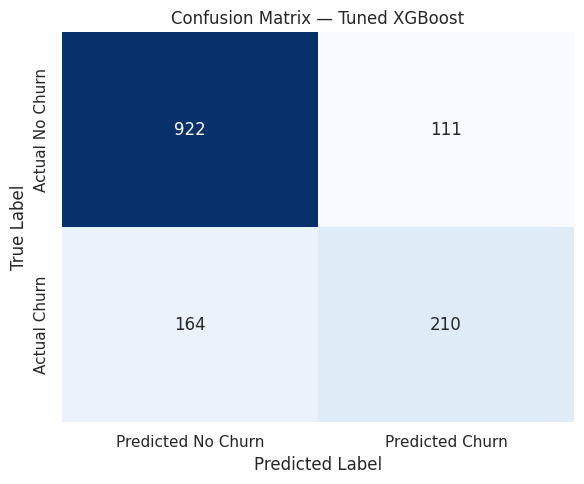

In [102]:
# Confusion matrix for tuned XGBoost
cm_xgb_tuned = confusion_matrix(y_test, y_pred_xgb_tuned)

plt.figure(figsize=(6, 5))
ax = sns.heatmap(
    cm_xgb_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Predicted No Churn", "Predicted Churn"],
    yticklabels=["Actual No Churn", "Actual Churn"]
)

plt.title("Confusion Matrix — Tuned XGBoost")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

if SAVE_FIGURES:
    plt.savefig(f"{FIGURES_DIR}/confusion_matrix_tuned_xgboost.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

### Interpretation

The confusion matrix of the tuned XGBoost model shows:

- **922 true negatives**
- **210 true positives**
- **111 false positives**
- **164 false negatives**

Compared with the untuned XGBoost model, this represents a clear operational improvement:

- true positives increased from **201** to **210**
- false negatives decreased from **173** to **164**
- false positives decreased from **127** to **111**

This is an especially strong outcome because the tuned model improved churn detection while also reducing unnecessary false alarms. In business terms, that means a better balance between:

- identifying more customers who are actually at risk of leaving
- avoiding excessive intervention on customers who would not have churned

This improvement helps explain why tuning led to gains across precision, recall, F1-score, and Average Precision.

## 9.10 ROC and Precision-Recall Curves for the Tuned Model

Finally, the tuned XGBoost model is added to the existing curve comparisons to determine whether tuning improved ranking quality relative to the untuned version and the strongest baseline.

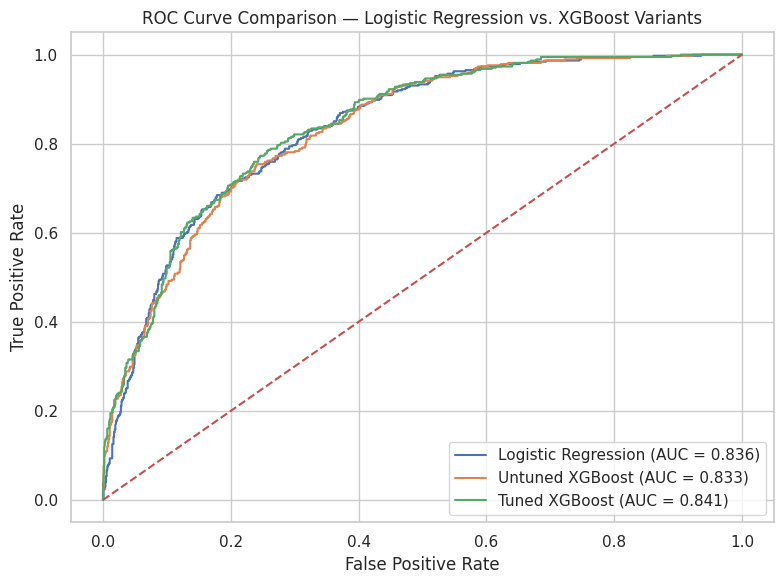

In [103]:
# ROC curve comparison including tuned XGBoost
plt.figure(figsize=(8, 6))

# Logistic Regression
logreg_pipeline = fitted_baseline_pipelines["Logistic Regression"]
y_proba_logreg = logreg_pipeline.predict_proba(X_test)[:, 1]
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_proba_logreg)
roc_auc_logreg = roc_auc_score(y_test, y_proba_logreg)
plt.plot(fpr_logreg, tpr_logreg, label=f"Logistic Regression (AUC = {roc_auc_logreg:.3f})")

# Untuned XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f"Untuned XGBoost (AUC = {roc_auc_xgb:.3f})")

# Tuned XGBoost
fpr_xgb_tuned, tpr_xgb_tuned, _ = roc_curve(y_test, y_proba_xgb_tuned)
roc_auc_xgb_tuned = roc_auc_score(y_test, y_proba_xgb_tuned)
plt.plot(fpr_xgb_tuned, tpr_xgb_tuned, label=f"Tuned XGBoost (AUC = {roc_auc_xgb_tuned:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve Comparison — Logistic Regression vs. XGBoost Variants")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

if SAVE_FIGURES:
    plt.savefig(f"{FIGURES_DIR}/tuned_xgboost_roc_comparison.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

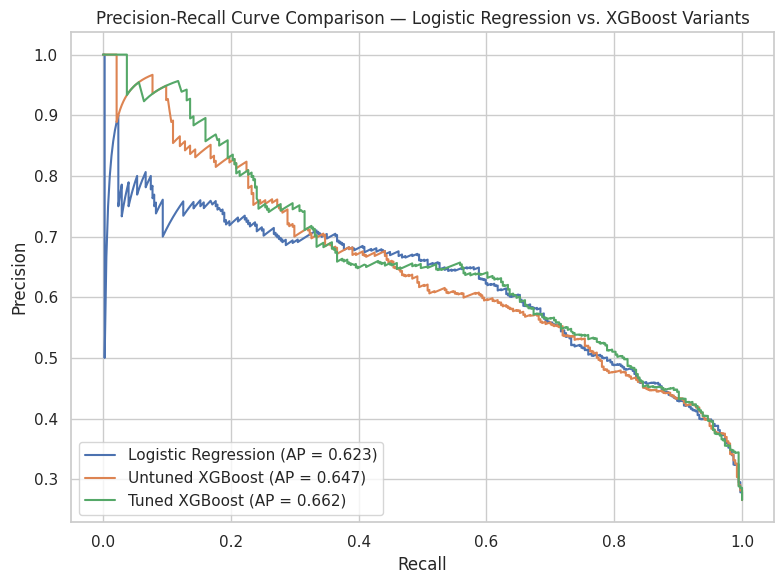

In [104]:
# Precision-recall curve comparison including tuned XGBoost
plt.figure(figsize=(8, 6))

# Logistic Regression
precision_logreg, recall_logreg, _ = precision_recall_curve(y_test, y_proba_logreg)
ap_logreg = average_precision_score(y_test, y_proba_logreg)
plt.plot(recall_logreg, precision_logreg, label=f"Logistic Regression (AP = {ap_logreg:.3f})")

# Untuned XGBoost
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_proba_xgb)
ap_xgb = average_precision_score(y_test, y_proba_xgb)
plt.plot(recall_xgb, precision_xgb, label=f"Untuned XGBoost (AP = {ap_xgb:.3f})")

# Tuned XGBoost
precision_xgb_tuned, recall_xgb_tuned, _ = precision_recall_curve(y_test, y_proba_xgb_tuned)
ap_xgb_tuned = average_precision_score(y_test, y_proba_xgb_tuned)
plt.plot(recall_xgb_tuned, precision_xgb_tuned, label=f"Tuned XGBoost (AP = {ap_xgb_tuned:.3f})")

plt.title("Precision-Recall Curve Comparison — Logistic Regression vs. XGBoost Variants")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")

if SAVE_FIGURES:
    plt.savefig(f"{FIGURES_DIR}/tuned_xgboost_pr_comparison.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

### Interpretation

The curve comparison provides one of the clearest views of the value added by tuning.

### ROC Curve Comparison
The ROC-AUC results are:

- **Logistic Regression = 0.836**
- **Untuned XGBoost = 0.833**
- **Tuned XGBoost = 0.841**

This shows that tuning successfully moved XGBoost from slightly below the best baseline to slightly above it in overall ranking quality.

### Precision-Recall Curve Comparison
The Average Precision results are:

- **Logistic Regression = 0.623**
- **Untuned XGBoost = 0.647**
- **Tuned XGBoost = 0.662**

This is especially important. It confirms that XGBoost not only preserved its initial strength in precision-recall ranking, but improved it further through tuning. The tuned model now provides the strongest overall probability-ranking behavior among the tested models.

Taken together, the curve analysis shows that the tuned XGBoost model is now the strongest model from a **ranking perspective**, especially for prioritizing likely churners.

## 9.11 Tuning Gain Summary

To quantify the value of hyperparameter tuning directly, we summarize the metric differences between the untuned and tuned XGBoost models.

In [106]:
# Metric improvement table: tuned minus untuned
untuned_metrics = xgb_test_results.copy()
untuned_metrics["Model"] = "Untuned XGBoost"

tuned_metrics = xgb_tuned_test_results.copy()
tuned_metrics["Model"] = "Tuned XGBoost"

metric_columns = [
    "Test Accuracy",
    "Test Precision",
    "Test Recall",
    "Test F1-score",
    "Test ROC-AUC",
    "Test Avg Precision"
]

gain_df = pd.DataFrame({
    "Metric": metric_columns,
    "Improvement": [
        tuned_metrics.iloc[0][col] - untuned_metrics.iloc[0][col]
        for col in metric_columns
    ]
})

display(gain_df.round(4))

,Metric,Improvement
0,Test Accuracy,0.02
1,Test Precision,0.04
2,Test Recall,0.02
3,Test F1-score,0.03
4,Test ROC-AUC,0.01
5,Test Avg Precision,0.02


### Interpretation

The tuning gain summary shows that hyperparameter optimization produced improvements across **all evaluated test metrics**.

The observed gains are:

- **Test Accuracy: +0.02**
- **Test Precision: +0.04**
- **Test Recall: +0.02**
- **Test F1-score: +0.03**
- **Test ROC-AUC: +0.01**
- **Test Average Precision: +0.02**

This is an excellent outcome. It means tuning did not merely shift the model’s strengths from one metric to another; it improved the model more broadly and consistently.

In portfolio terms, this is exactly the kind of result that justifies the inclusion of a tuning stage: the process was not cosmetic, but materially improved model quality.

### Interpretation

The hyperparameter tuning stage was successful and materially improved the XGBoost model.

The tuned model achieves:

- **Test Accuracy = 0.80**
- **Test Precision = 0.65**
- **Test Recall = 0.56**
- **Test F1-score = 0.60**
- **Test ROC-AUC = 0.84**
- **Test Average Precision = 0.66**

Compared with the untuned XGBoost model, the tuned version improved across **all major evaluation metrics**. More importantly, it now performs essentially on par with the strongest baseline, **Logistic Regression**, in the standard classification metrics while clearly outperforming it in **Average Precision**.

The curve analysis strengthens this conclusion further:

- tuned XGBoost achieves the best **ROC-AUC** among the compared variants
- tuned XGBoost achieves the best **Average Precision**
- tuned XGBoost provides the strongest overall ranking behavior for identifying likely churners

This is a major result for the project. It means the advanced gradient boosting model now has a credible and evidence-based claim to being the strongest model in the notebook — particularly when the business objective emphasizes **probability ranking and retention prioritization**, not just default-threshold classification.

At this point, the project is ready for the next critical step: **threshold optimization**, where the tuned model’s probability outputs can be converted into a business-aligned intervention rule.

# 10. Threshold Optimization for Tuned XGBoost

The tuned XGBoost model now provides strong churn-risk probabilities, but the default classification threshold of **0.50** is not necessarily the best choice for a real business retention strategy.

In churn prediction, the optimal threshold depends on the trade-off between:

- identifying as many true churners as possible
- avoiding too many false alarms
- balancing intervention cost against retention opportunity

For this reason, model evaluation should not stop at the default threshold. Instead, it is useful to examine how predictive behavior changes across a range of decision cutoffs.

The goal of this section is to:

- evaluate the tuned XGBoost model across multiple thresholds
- compare precision, recall, F1-score, and related trade-offs
- identify a more business-aligned classification threshold
- determine whether threshold adjustment improves the practical usefulness of the model

## 10.1 Why Threshold Optimization Matters

By default, most binary classifiers assign the positive class when the predicted probability exceeds **0.50**. However, this default rule is arbitrary and may not align with business priorities.

In a churn prediction setting:

- a **lower threshold** usually increases recall, helping identify more customers at risk of leaving
- a **higher threshold** usually increases precision, reducing the number of false-positive churn alerts

Neither choice is universally best. The right threshold depends on the retention context:

- If the company can intervene with only a small number of customers, precision may matter more
- If missing churners is very costly, recall may matter more
- If a balanced trade-off is desired, F1-score can be a useful guide

Threshold optimization therefore converts a strong probability model into a more practical decision system.

In [108]:
# ============================================================
# Block 10: Threshold Optimization for Tuned XGBoost
# ============================================================

# Reuse predicted probabilities from the tuned XGBoost model
# (computed in Block 9 as y_proba_xgb_tuned)

print("Probability predictions for tuned XGBoost are ready for threshold analysis.")
print(f"Number of test observations: {len(y_proba_xgb_tuned)}")

Probability predictions for tuned XGBoost are ready for threshold analysis.
Number of test observations: 1407


## 10.2 Threshold Grid Definition

To study threshold behavior systematically, we evaluate the tuned XGBoost model across a predefined grid of probability cutoffs.

This provides a clear picture of how classification performance changes as the decision rule becomes more conservative or more aggressive.

In [109]:
# Define threshold grid
thresholds = np.arange(0.10, 0.91, 0.05)

print("Threshold grid:")
print(np.round(thresholds, 2))

Threshold grid:
[0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75
 0.8  0.85 0.9 ]


## 10.3 Evaluating Metrics Across Thresholds

For each threshold, we compute a set of business-relevant metrics:

- precision
- recall
- F1-score
- accuracy

This allows us to see how the tuned model’s operating behavior changes as the classification cutoff moves.

In [110]:
# Evaluate tuned XGBoost performance across thresholds
threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_proba_xgb_tuned >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "F1-score": f1_score(y_test, y_pred_threshold, zero_division=0),
        "Predicted Churn Rate": y_pred_threshold.mean()
    })

threshold_results_df = pd.DataFrame(threshold_results)
display(threshold_results_df.round(4))

,Threshold,Accuracy,Precision,Recall,F1-score,Predicted Churn Rate
0,0.10,0.61,0.40,0.95,0.56,0.63
1,0.15,0.67,0.44,0.90,0.60,0.54
2,0.20,0.69,0.46,0.84,0.59,0.49
3,0.25,0.72,0.49,0.82,0.61,0.45
4,0.30,0.75,0.52,0.78,0.63,0.40
5,0.35,0.77,0.56,0.71,0.63,0.34
6,0.40,0.79,0.58,0.67,0.62,0.30
7,0.45,0.80,0.63,0.62,0.63,0.26
8,0.50,0.80,0.65,0.56,0.60,0.23
9,0.55,0.79,0.65,0.44,0.53,0.18


### Interpretation

The threshold grid reveals a clear and systematic trade-off between precision and recall.

As the threshold increases:

- **precision rises steadily**
- **recall falls sharply**
- **predicted churn rate decreases**
- **F1-score first improves, then declines**

This is exactly the behavior expected from a probabilistic churn model. Lower thresholds make the classifier more aggressive, increasing the number of customers flagged as likely churners. Higher thresholds make it more conservative, reducing false positives but also missing more true churners.

Several specific patterns stand out:

- At a **low threshold of 0.10**, recall is extremely high (**0.95**), but precision is low (**0.40**), meaning the model captures most churners at the cost of many false alarms.
- At the **default threshold of 0.50**, precision becomes much stronger (**0.65**), but recall drops to **0.56**.
- At very high thresholds such as **0.80–0.90**, precision becomes very high, but recall collapses, making the classifier too conservative for most retention-oriented use cases.

Overall, the threshold table confirms that the tuned XGBoost model produces informative probabilities and that the classification rule can be meaningfully adjusted depending on business priorities.

## 10.4 Selecting a Candidate Threshold

A useful first criterion for threshold selection is the **F1-score**, since it balances precision and recall.

This does not automatically define the final business threshold, but it provides a strong data-driven candidate for a more balanced classification rule than the default 0.50 cutoff.

In [111]:
# Find threshold with best F1-score
best_f1_row = threshold_results_df.loc[threshold_results_df["F1-score"].idxmax()].copy()

best_threshold_f1 = best_f1_row["Threshold"]

print("Best threshold by F1-score:")
display(best_f1_row.to_frame().T.round(4))

Best threshold by F1-score:


,Threshold,Accuracy,Precision,Recall,F1-score,Predicted Churn Rate
4,0.30,0.75,0.52,0.78,0.63,0.40


In [121]:
# Compare default threshold (0.50) vs best F1 threshold
default_threshold = 0.50

default_row = threshold_results_df[np.isclose(threshold_results_df["Threshold"], default_threshold)].copy()
best_row_df = best_f1_row.to_frame().T.copy()

default_row["Threshold Type"] = "Default (0.50)"
best_row_df["Threshold Type"] = "Best F1 Threshold"

best_f1_comparison = pd.concat([default_row, best_row_df], ignore_index=True)

best_f1_comparison = best_f1_comparison[
    ["Threshold Type", "Threshold", "Accuracy", "Precision", "Recall", "F1-score", "Predicted Churn Rate"]
]

display(best_f1_comparison.round(4))

,Threshold Type,Threshold,Accuracy,Precision,Recall,F1-score,Predicted Churn Rate
0,Default (0.50),0.50,0.80,0.65,0.56,0.60,0.23
1,Best F1 Threshold,0.30,0.75,0.52,0.78,0.63,0.40


### Interpretation

Using **F1-score** as the selection criterion identifies **0.30** as the best threshold in the evaluated grid.

At this threshold, the model achieves:

- **Accuracy = 0.75**
- **Precision = 0.52**
- **Recall = 0.78**
- **F1-score = 0.63**
- **Predicted Churn Rate = 0.40**

This is an important result because it shows that the default threshold of **0.50** is not the threshold that best balances precision and recall. Instead, a lower threshold allows the model to detect substantially more churners while still maintaining a reasonable level of precision.

From a business perspective, this makes sense. In churn prediction, the cost of missing a true churner can be high, so a more recall-oriented operating point is often preferable to a stricter but less sensitive default rule.

## 10.5 Threshold Trade-Off Visualization

The charts below visualize how the key performance metrics change across the threshold grid.

These plots are especially useful for understanding:

- where recall begins to fall sharply
- where precision begins to improve substantially
- where F1-score peaks
- how aggressive the model becomes in predicting churn at lower thresholds

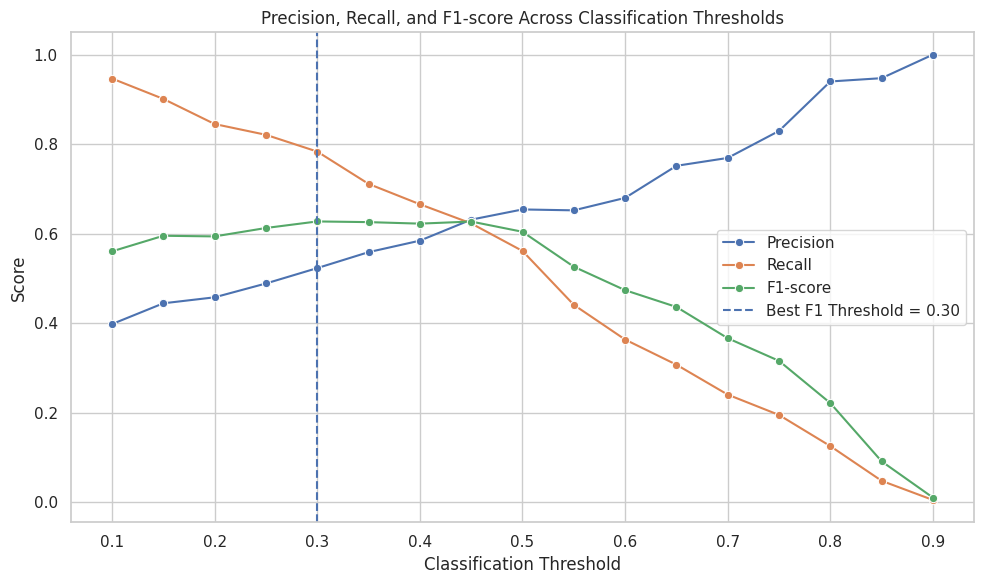

In [114]:
# Plot precision, recall, and F1-score across thresholds
threshold_plot_df = threshold_results_df.melt(
    id_vars="Threshold",
    value_vars=["Precision", "Recall", "F1-score"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))
ax = sns.lineplot(data=threshold_plot_df, x="Threshold", y="Score", hue="Metric", marker="o")

plt.axvline(best_threshold_f1, linestyle="--", label=f"Best F1 Threshold = {best_threshold_f1:.2f}")
plt.title("Precision, Recall, and F1-score Across Classification Thresholds")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.legend()

if SAVE_FIGURES:
    plt.savefig(f"{FIGURES_DIR}/threshold_tradeoff_precision_recall_f1.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

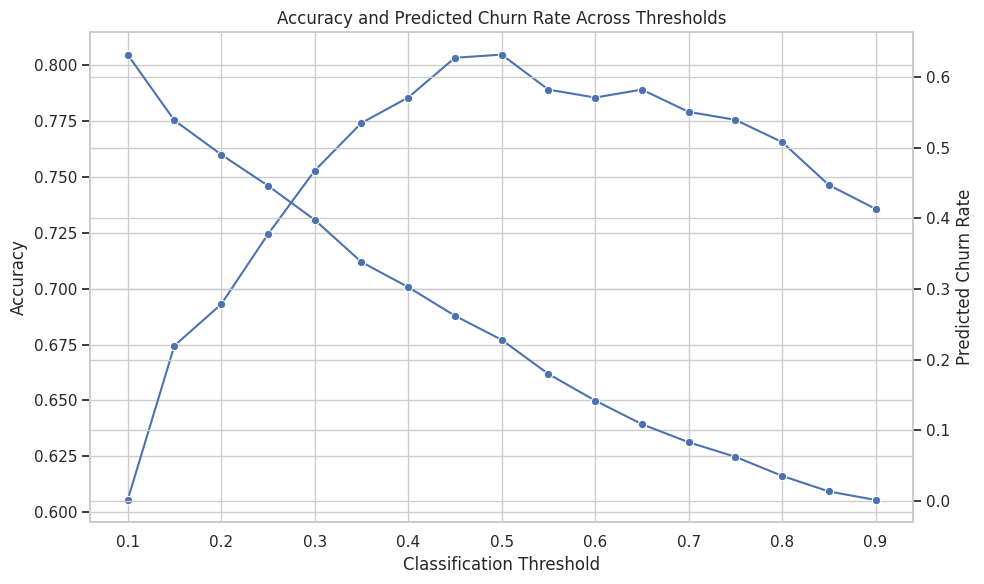

In [115]:
# Plot accuracy and predicted churn rate across thresholds
fig, ax1 = plt.subplots(figsize=(10, 6))

sns.lineplot(data=threshold_results_df, x="Threshold", y="Accuracy", marker="o", ax=ax1)
ax1.set_title("Accuracy and Predicted Churn Rate Across Thresholds")
ax1.set_xlabel("Classification Threshold")
ax1.set_ylabel("Accuracy")

ax2 = ax1.twinx()
sns.lineplot(data=threshold_results_df, x="Threshold", y="Predicted Churn Rate", marker="o", ax=ax2)
ax2.set_ylabel("Predicted Churn Rate")

if SAVE_FIGURES:
    plt.savefig(f"{FIGURES_DIR}/threshold_accuracy_and_predicted_churn_rate.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

### Interpretation

The threshold trade-off plots make the operating behavior of the tuned XGBoost model especially clear.

The first chart shows that:

- **precision** increases as the threshold rises
- **recall** decreases steadily as the threshold rises
- **F1-score** peaks around the lower-middle threshold range and reaches its highest value at **0.30**

This confirms that the best balanced operating point lies below the default 0.50 cutoff.

The second chart shows that:

- **accuracy** is highest around the mid-threshold range
- **predicted churn rate** declines sharply as the threshold increases

This is a useful business insight. A lower threshold means the company would intervene on a much larger share of customers, while a higher threshold produces a smaller and more selective intervention list. The threshold therefore functions not only as a modeling choice, but also as a practical budget and campaign-allocation lever.

## 10.6 Confusion Matrix at the Selected Threshold

After identifying a candidate threshold, we inspect its confusion matrix directly. This helps translate abstract metric changes into concrete operational behavior:

- how many churners are now detected
- how many false positives are introduced
- whether the threshold shift is reasonable from a business standpoint

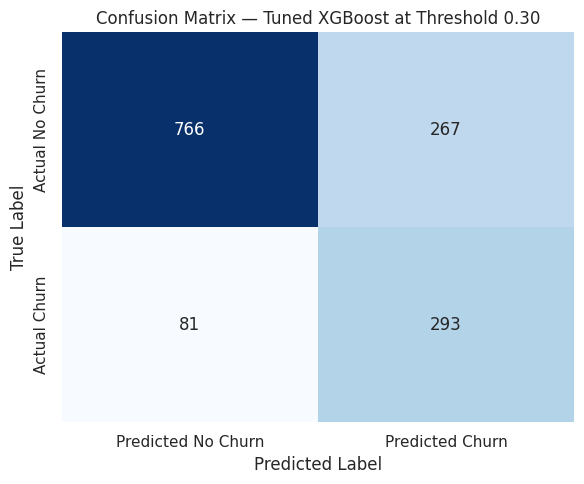

In [116]:
# Confusion matrix at the best F1 threshold
y_pred_best_threshold = (y_proba_xgb_tuned >= best_threshold_f1).astype(int)
cm_best_threshold = confusion_matrix(y_test, y_pred_best_threshold)

plt.figure(figsize=(6, 5))
ax = sns.heatmap(
    cm_best_threshold,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Predicted No Churn", "Predicted Churn"],
    yticklabels=["Actual No Churn", "Actual Churn"]
)

plt.title(f"Confusion Matrix — Tuned XGBoost at Threshold {best_threshold_f1:.2f}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

if SAVE_FIGURES:
    plt.savefig(f"{FIGURES_DIR}/confusion_matrix_tuned_xgboost_best_threshold.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

### Interpretation

At the selected threshold of **0.30**, the tuned XGBoost confusion matrix becomes:

- **766 true negatives**
- **293 true positives**
- **267 false positives**
- **81 false negatives**

This is a major shift relative to the default threshold. The model now captures far more churners, reducing false negatives substantially, but it also introduces more false positives.

This is exactly the trade-off threshold optimization is meant to expose. At the optimized threshold, the classifier becomes much more useful for a proactive retention strategy because it identifies a larger share of customers who are actually at risk of leaving.

From a business standpoint, this operating point may be attractive when:

- missing churners is especially costly
- the business has enough retention capacity to contact a broader at-risk segment
- recall is more important than maintaining a strict precision level

## 10.7 Default vs Optimized Threshold Comparison

To quantify the practical impact of threshold adjustment, we compare the tuned XGBoost model under:

- the default threshold of **0.50**
- the selected optimized threshold

This makes it easier to see whether threshold optimization materially improves the operational performance of the classifier.

In [117]:
# Collect comparison metrics for default and optimized thresholds
y_pred_default = (y_proba_xgb_tuned >= 0.50).astype(int)
y_pred_optimized = (y_proba_xgb_tuned >= best_threshold_f1).astype(int)

threshold_comparison_df = pd.DataFrame([
    {
        "Setting": "Default Threshold (0.50)",
        "Accuracy": accuracy_score(y_test, y_pred_default),
        "Precision": precision_score(y_test, y_pred_default, zero_division=0),
        "Recall": recall_score(y_test, y_pred_default, zero_division=0),
        "F1-score": f1_score(y_test, y_pred_default, zero_division=0),
        "Predicted Churn Rate": y_pred_default.mean()
    },
    {
        "Setting": f"Optimized Threshold ({best_threshold_f1:.2f})",
        "Accuracy": accuracy_score(y_test, y_pred_optimized),
        "Precision": precision_score(y_test, y_pred_optimized, zero_division=0),
        "Recall": recall_score(y_test, y_pred_optimized, zero_division=0),
        "F1-score": f1_score(y_test, y_pred_optimized, zero_division=0),
        "Predicted Churn Rate": y_pred_optimized.mean()
    }
])

display(threshold_comparison_df.round(4))

,Setting,Accuracy,Precision,Recall,F1-score,Predicted Churn Rate
0,Default Threshold (0.50),0.80,0.65,0.56,0.60,0.23
1,Optimized Threshold (0.30),0.75,0.52,0.78,0.63,0.40


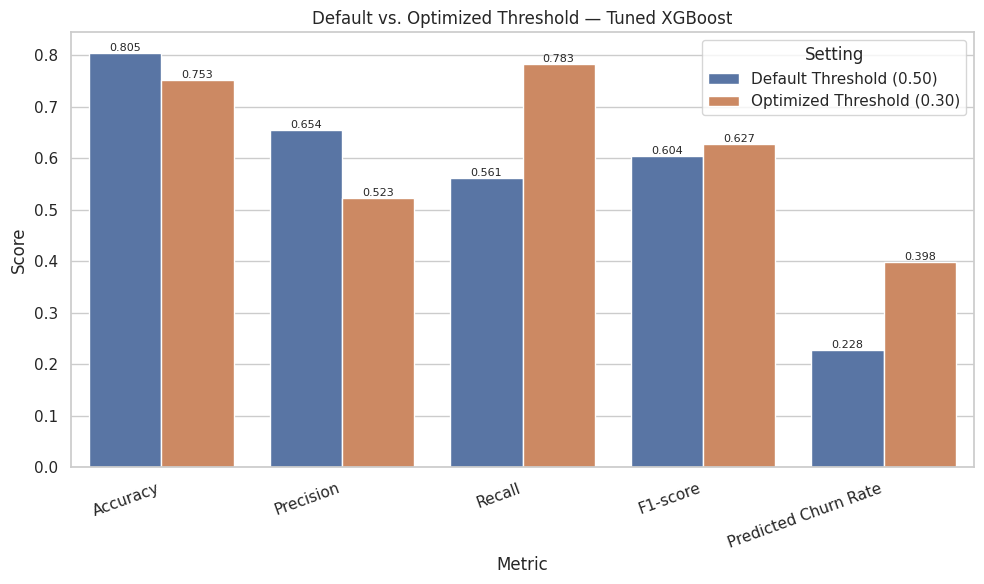

In [118]:
# Visual comparison: default vs optimized threshold
threshold_comparison_melted = threshold_comparison_df.melt(
    id_vars="Setting",
    value_vars=["Accuracy", "Precision", "Recall", "F1-score", "Predicted Churn Rate"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=threshold_comparison_melted, x="Metric", y="Score", hue="Setting")

plt.title("Default vs. Optimized Threshold — Tuned XGBoost")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8)

if SAVE_FIGURES:
    plt.savefig(f"{FIGURES_DIR}/default_vs_optimized_threshold.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

### Interpretation

The default-versus-optimized comparison makes the effect of threshold adjustment very concrete.

### Default Threshold (0.50)
- **Accuracy = 0.80**
- **Precision = 0.65**
- **Recall = 0.56**
- **F1-score = 0.60**
- **Predicted Churn Rate = 0.23**

### Optimized Threshold (0.30)
- **Accuracy = 0.75**
- **Precision = 0.52**
- **Recall = 0.78**
- **F1-score = 0.63**
- **Predicted Churn Rate = 0.40**

This comparison shows a very important trade-off:

- lowering the threshold reduces **accuracy** and **precision**
- but it produces a **large gain in recall**
- and also improves **F1-score**

In other words, the optimized threshold makes the model substantially more effective at catching churners, even though it becomes less selective. This is often exactly the right trade-off for churn intervention, where the goal is not simply to be “correct” overall, but to avoid missing customers who are likely to leave.

## 10.8 Business-Oriented Threshold Reference Table

Different thresholds may be appropriate depending on the business objective. For example:

- a **high-recall threshold** may be preferred when missing churners is especially costly
- a **high-precision threshold** may be preferred when retention budget is limited
- a **balanced threshold** may be preferred when the goal is to optimize overall intervention efficiency

The table below highlights a few representative operating points.

In [119]:
# Build a small reference table for selected thresholds
representative_thresholds = [0.30, 0.40, 0.50, best_threshold_f1, 0.60, 0.70]
representative_thresholds = sorted(set([round(float(t), 2) for t in representative_thresholds]))

representative_df = threshold_results_df[
    threshold_results_df["Threshold"].round(2).isin(representative_thresholds)
].copy()

display(representative_df.round(4))

,Threshold,Accuracy,Precision,Recall,F1-score,Predicted Churn Rate
4,0.30,0.75,0.52,0.78,0.63,0.40
6,0.40,0.79,0.58,0.67,0.62,0.30
8,0.50,0.80,0.65,0.56,0.60,0.23
10,0.60,0.79,0.68,0.36,0.47,0.14
12,0.70,0.78,0.77,0.24,0.37,0.08


### Interpretation

The representative threshold table shows that different operating points support different business goals.

For example:

- **0.30** is the strongest balanced threshold by F1-score and offers high recall
- **0.40** provides a more moderate compromise between precision and recall
- **0.50** is more selective and conservative, favoring precision over churn capture
- **0.60–0.70** may be appropriate only when the intervention budget is very limited and the business wants to target a smaller, higher-confidence group

This reinforces an important practical point: there is no single universally “correct” threshold. The best choice depends on how the company values:

- false positives
- false negatives
- outreach cost
- retention opportunity

## 10.9 Threshold Gain Summary

To quantify the value of threshold optimization directly, we calculate the metric differences between the default threshold and the selected optimized threshold.

In [120]:
# Threshold gain summary: optimized threshold minus default threshold
metric_columns_threshold = ["Accuracy", "Precision", "Recall", "F1-score", "Predicted Churn Rate"]

threshold_gain_df = pd.DataFrame({
    "Metric": metric_columns_threshold,
    "Improvement": [
        threshold_comparison_df.iloc[1][col] - threshold_comparison_df.iloc[0][col]
        for col in metric_columns_threshold
    ]
})

display(threshold_gain_df.round(4))

,Metric,Improvement
0,Accuracy,-0.05
1,Precision,-0.13
2,Recall,0.22
3,F1-score,0.02
4,Predicted Churn Rate,0.17


### Interpretation

The threshold gain summary quantifies the operational impact of moving from the default threshold (**0.50**) to the F1-optimized threshold (**0.30**).

The changes are:

- **Accuracy: -0.05**
- **Precision: -0.13**
- **Recall: +0.22**
- **F1-score: +0.02**
- **Predicted Churn Rate: +0.17**

This is a highly informative result. The optimized threshold sacrifices some selectivity and overall accuracy, but it dramatically improves the model’s ability to identify actual churners. In particular, the **+0.22 recall gain** is substantial and likely to be highly valuable in a retention context.

The fact that **F1-score also improves** confirms that this is not merely a recall-at-all-costs shift. Instead, it reflects a more balanced and more effective operating point for churn detection.

### Interpretation

Threshold optimization meaningfully improves the practical usefulness of the tuned XGBoost model.

The analysis shows that the default threshold of **0.50** is too conservative if the business objective is to identify churners effectively. By lowering the threshold to **0.30**, the model becomes significantly more effective at detecting customers at risk of leaving.

At the optimized threshold, the model achieves:

- **Accuracy = 0.75**
- **Precision = 0.52**
- **Recall = 0.78**
- **F1-score = 0.63**
- **Predicted Churn Rate = 0.40**

Compared with the default threshold, this operating point:

- reduces accuracy and precision
- but increases recall substantially
- improves F1-score
- expands the intervention pool from **23%** to **40%** of customers

This is a highly realistic business trade-off. In a retention setting, the company may prefer to contact more customers if doing so allows it to identify many more true churners. The optimized threshold therefore transforms the tuned XGBoost model from a strong ranking system into a more actionable retention decision tool.

At this point, the modeling workflow has reached a strong practical conclusion:

- **Logistic Regression** remains an excellent baseline
- **Tuned XGBoost** becomes the strongest advanced model
- **Threshold optimization** further improves its usefulness for churn intervention by aligning the decision rule with business priorities rather than relying on the arbitrary default cutoff

# 11. Feature Importance and Model Interpretability

A strong predictive model is most valuable when its decisions can be interpreted in business terms. In churn prediction, this is especially important because the goal is not only to identify customers at risk of leaving, but also to understand the factors associated with that risk.

In this section, we examine the feature importance profile of the **tuned XGBoost model** in order to answer questions such as:

- which features contribute most strongly to churn prediction?
- are the most important signals consistent with the earlier exploratory analysis?
- what practical retention insights can be derived from the model?

This step helps bridge the gap between predictive performance and actionable business understanding.

## 11.1 Why Interpretability Matters

High predictive performance alone is not enough for a business-facing churn model. Decision-makers also need to understand the major drivers behind the predictions so that they can design appropriate interventions.

Interpretability is important because it helps:

- connect model behavior to real customer dynamics
- validate whether the model is learning plausible patterns
- identify potential retention levers such as contract structure, support services, or billing-related risk
- make the final model more credible and more actionable

For this project, feature importance analysis provides a practical first layer of interpretability.

In [122]:
# ============================================================
# Block 11: Feature Importance and Model Interpretability
# ============================================================

# Extract fitted tuned XGBoost model from the best pipeline
tuned_xgb_model = best_xgb_pipeline.named_steps["model"]

# Rebuild processed feature names from the fitted preprocessor
fitted_preprocessor = best_xgb_pipeline.named_steps["preprocessor"]

encoded_cat_feature_names = (
    fitted_preprocessor.named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_features)
)

processed_feature_names = numerical_features + list(encoded_cat_feature_names)

print("Tuned XGBoost model and processed feature names extracted successfully.")
print(f"Number of processed features: {len(processed_feature_names)}")

Tuned XGBoost model and processed feature names extracted successfully.
Number of processed features: 45


## 11.2 Extracting Feature Importance

XGBoost provides a built-in feature importance measure that estimates how useful each transformed feature was during model training.

Because the model was trained on the preprocessed feature space, the importance values correspond to:

- scaled numerical features
- one-hot encoded categorical indicators

This means that interpretation should be done carefully, especially for encoded categorical variables that expand into multiple binary features.

In [123]:
# Build feature importance table
feature_importance_df = pd.DataFrame({
    "Feature": processed_feature_names,
    "Importance": tuned_xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

display(feature_importance_df.head(20).round(4))

,Feature,Importance
0,Contract_Month-to-month,0.50
1,InternetService_Fiber optic,0.10
2,OnlineSecurity_No,0.05
3,TechSupport_No,0.04
4,PaperlessBilling_Yes,0.03
5,Contract_Two year,0.02
6,tenure,0.02
7,PaymentMethod_Electronic check,0.02
8,InternetService_DSL,0.01
9,StreamingMovies_Yes,0.01


### Interpretation

The tuned XGBoost model was trained on a processed feature space containing **45 transformed features**. These include:

- **4 numerical variables**
- **41 one-hot encoded categorical indicators**

The transformed feature importance table shows that the model does not distribute importance evenly. Instead, a relatively small number of variables account for most of the predictive signal.

This is an important interpretability result, because it suggests that the model is relying on a coherent subset of customer characteristics rather than diffuse noise across the entire feature space.

## 11.3 Top Feature Importance Visualization

To make the model behavior easier to interpret, we visualize the most important transformed features learned by the tuned XGBoost model.

This highlights which numerical variables and encoded categorical patterns contribute most strongly to churn prediction.

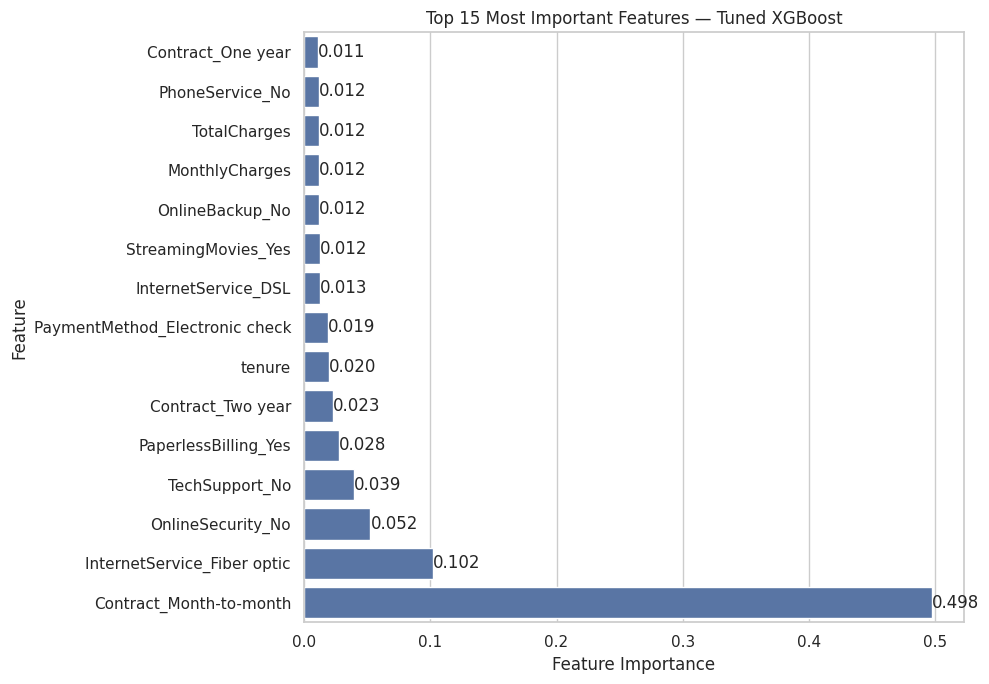

In [124]:
# Plot top feature importances
top_n = 15
top_feature_importance_df = feature_importance_df.head(top_n).sort_values(by="Importance")

plt.figure(figsize=(10, 7))
ax = sns.barplot(data=top_feature_importance_df, x="Importance", y="Feature")

plt.title(f"Top {top_n} Most Important Features — Tuned XGBoost")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

if SAVE_FIGURES:
    plt.savefig(f"{FIGURES_DIR}/tuned_xgboost_top_feature_importance.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

### Interpretation

The transformed-feature importance plot reveals a very strong concentration of predictive signal in a few key variables.

The most important individual transformed features are:

- **`Contract_Month-to-month` = 0.50**
- **`InternetService_Fiber optic` = 0.10**
- **`OnlineSecurity_No` = 0.05**
- **`TechSupport_No` = 0.04**
- **`PaperlessBilling_Yes` = 0.03**
- **`Contract_Two year` = 0.02**
- **`tenure` = 0.02**
- **`PaymentMethod_Electronic check` = 0.02**

This ranking is especially informative. It shows that the model is strongly driven by a combination of:

- **contract flexibility**
- **internet service type**
- **absence of support/security services**
- **billing and payment behavior**
- **customer tenure**

The dominance of **`Contract_Month-to-month`** is particularly striking. It indicates that the model sees short-term contract structure as the single strongest churn-related signal in the transformed feature space.

## 11.4 Aggregated Importance by Original Variable

Because one-hot encoding expands categorical variables into multiple transformed columns, it is useful to aggregate importance back to the level of the original source variable.

For example:

- `Contract_Month-to-month`
- `Contract_One year`
- `Contract_Two year`

all belong to the original feature **`Contract`**.

Aggregating importance at the original-variable level produces a more business-readable interpretation of the model.

In [125]:
# Aggregate transformed-feature importance back to original feature names
def map_to_original_feature(feature_name, numerical_features, categorical_features):
    if feature_name in numerical_features:
        return feature_name

    for cat_feature in categorical_features:
        if feature_name.startswith(cat_feature + "_"):
            return cat_feature

    return feature_name

feature_importance_df["OriginalFeature"] = feature_importance_df["Feature"].apply(
    lambda x: map_to_original_feature(x, numerical_features, categorical_features)
)

aggregated_importance_df = (
    feature_importance_df.groupby("OriginalFeature", as_index=False)["Importance"]
    .sum()
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)

display(aggregated_importance_df.head(15).round(4))

,OriginalFeature,Importance
0,Contract,0.53
1,InternetService,0.11
2,OnlineSecurity,0.06
3,TechSupport,0.04
4,PaperlessBilling,0.04
5,PaymentMethod,0.04
6,PhoneService,0.02
7,tenure,0.02
8,StreamingMovies,0.02
9,MultipleLines,0.02


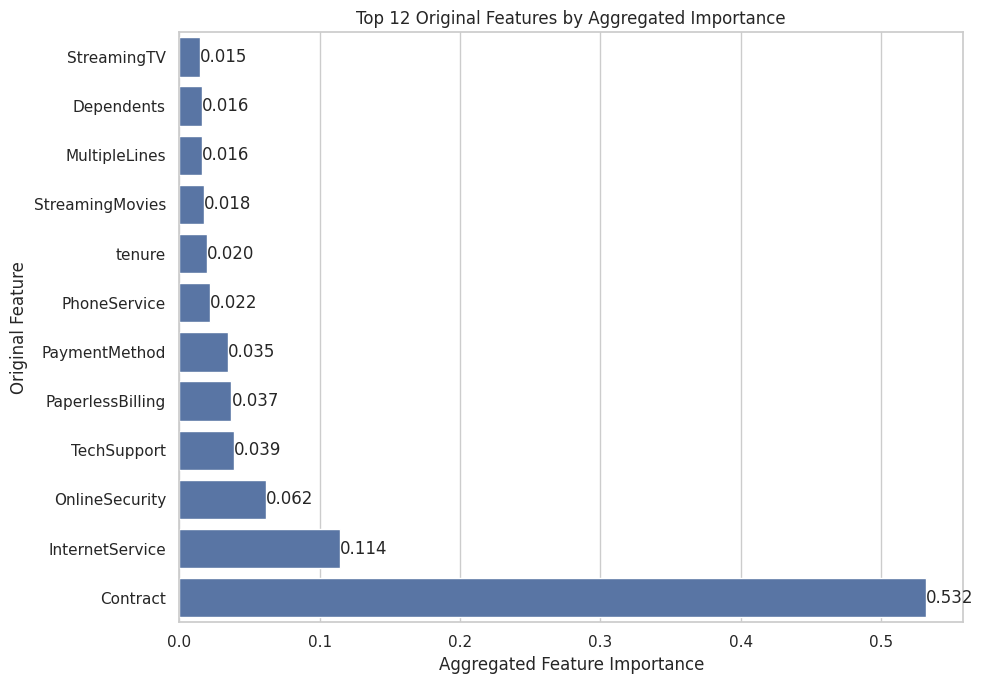

In [126]:
# Plot aggregated importance by original feature
top_n_aggregated = 12
top_aggregated_df = aggregated_importance_df.head(top_n_aggregated).sort_values(by="Importance")

plt.figure(figsize=(10, 7))
ax = sns.barplot(data=top_aggregated_df, x="Importance", y="OriginalFeature")

plt.title(f"Top {top_n_aggregated} Original Features by Aggregated Importance")
plt.xlabel("Aggregated Feature Importance")
plt.ylabel("Original Feature")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

if SAVE_FIGURES:
    plt.savefig(f"{FIGURES_DIR}/tuned_xgboost_aggregated_feature_importance.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

### Interpretation

After aggregating one-hot encoded features back to their original variables, the importance structure becomes even clearer and more business-readable.

The top original variables are:

- **Contract = 0.53**
- **InternetService = 0.11**
- **OnlineSecurity = 0.06**
- **TechSupport = 0.04**
- **PaperlessBilling = 0.04**
- **PaymentMethod = 0.04**
- **PhoneService = 0.02**
- **tenure = 0.02**
- **StreamingMovies = 0.02**
- **MultipleLines = 0.02**
- **Dependents = 0.02**
- **StreamingTV = 0.01**

This aggregated view shows that the model’s most important signals are overwhelmingly concentrated in a few business domains:

1. **Contract structure**
2. **Internet-service profile**
3. **Support and security service availability**
4. **Billing and payment behavior**

That is a strong and sensible pattern for a churn model. It suggests that the model is learning from meaningful aspects of customer commitment, service experience, and account structure.

## 11.5 Business-Focused Importance Summary

The table below presents the most important original variables in a form that is easier to translate into business insight.

This view is especially useful for identifying the customer, service, contract, and billing factors that appear most strongly connected to churn behavior in the tuned model.

In [127]:
# Create a cleaner business-facing summary table
business_importance_summary = aggregated_importance_df.head(12).copy()
business_importance_summary["Rank"] = range(1, len(business_importance_summary) + 1)

business_importance_summary = business_importance_summary[
    ["Rank", "OriginalFeature", "Importance"]
]

display(business_importance_summary.round(4))

,Rank,OriginalFeature,Importance
0,1,Contract,0.53
1,2,InternetService,0.11
2,3,OnlineSecurity,0.06
3,4,TechSupport,0.04
4,5,PaperlessBilling,0.04
5,6,PaymentMethod,0.04
6,7,PhoneService,0.02
7,8,tenure,0.02
8,9,StreamingMovies,0.02
9,10,MultipleLines,0.02


### Interpretation

The business-facing importance summary makes the model’s main churn drivers easier to interpret in practical terms.

The most important original variable is clearly **`Contract`**, with an aggregated importance of **0.53**, far ahead of every other feature. This indicates that the terms under which customers are retained — especially whether they are tied to short-term or long-term agreements — are the strongest drivers of churn prediction in the final model.

The second most important variable, **`InternetService`** (**0.11**), suggests that internet-service type is also highly informative, particularly given the strong role of **fiber optic** in the transformed feature ranking.

The next tier of important variables — **`OnlineSecurity`**, **`TechSupport`**, **`PaperlessBilling`**, and **`PaymentMethod`** — points toward service protection, customer support structure, and billing behavior as additional drivers of churn risk.

Overall, the summary indicates that churn in this dataset is driven more by **service configuration and account structure** than by purely demographic variables.

## 11.6 Consistency with Exploratory Analysis

A useful interpretability check is whether the model’s most important features align with the earlier exploratory findings.

In previous sections, the exploratory analysis suggested that churn is strongly associated with factors such as:

- tenure
- contract type
- internet service type
- payment behavior
- support and security services
- billing characteristics

If these same variables also emerge as important in the tuned XGBoost model, that strengthens confidence that the model is learning meaningful and plausible churn patterns rather than spurious noise.

In [128]:
# Quick list of top features for easy interpretation
top_feature_list = aggregated_importance_df.head(12)["OriginalFeature"].tolist()

print("Top aggregated features from the tuned XGBoost model:")
for i, feature in enumerate(top_feature_list, start=1):
    print(f"{i}. {feature}")

Top aggregated features from the tuned XGBoost model:
1. Contract
2. InternetService
3. OnlineSecurity
4. TechSupport
5. PaperlessBilling
6. PaymentMethod
7. PhoneService
8. tenure
9. StreamingMovies
10. MultipleLines
11. Dependents
12. StreamingTV


### Interpretation

The model’s importance profile is highly consistent with the earlier exploratory analysis, which strengthens confidence that the tuned XGBoost model is learning plausible and meaningful churn patterns.

Earlier EDA suggested that churn was especially associated with:

- **month-to-month contracts**
- **fiber optic service**
- absence of **OnlineSecurity**
- absence of **TechSupport**
- **paperless billing**
- **electronic check payment**
- lower **tenure**

These same themes now reappear in the feature importance results, both at the transformed-feature level and at the aggregated original-variable level.

This consistency is important because it suggests that the final model is not relying on arbitrary artifacts. Instead, it is learning from the same structural patterns that were already visible in the descriptive data analysis. That makes the model more credible, more interpretable, and more defensible from a business perspective.

## 11.7 Optional Built-In Importance Plot

As an additional reference, XGBoost’s built-in importance visualization can also be displayed. This is not necessary for the main interpretation, but it provides a secondary model-native view of feature importance.

<Figure size 1000x800 with 0 Axes>

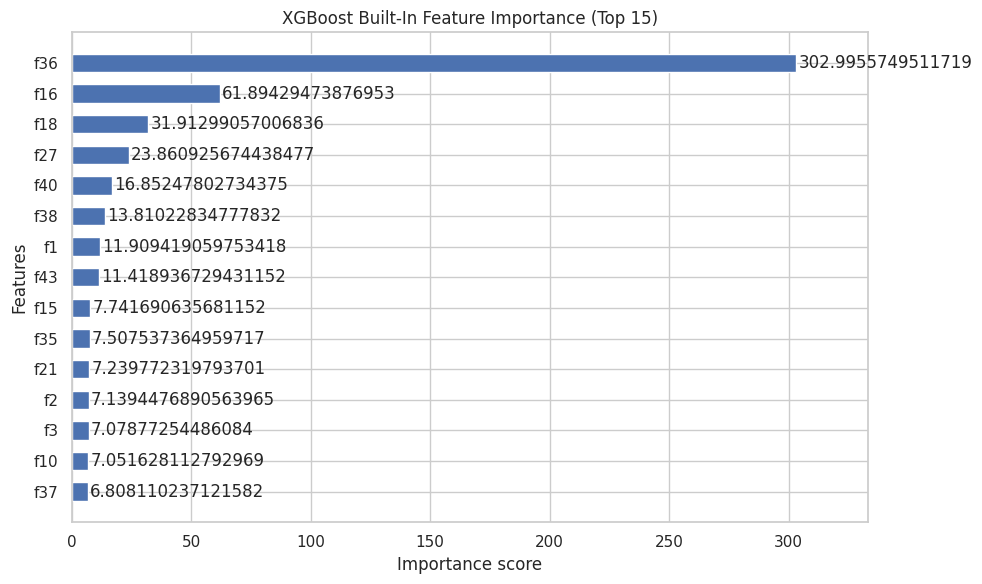

In [129]:
# Optional: XGBoost built-in importance plot
from xgboost import plot_importance

plt.figure(figsize=(10, 8))
plot_importance(tuned_xgb_model, max_num_features=15, importance_type="gain", height=0.6)

plt.title("XGBoost Built-In Feature Importance (Top 15)")
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(f"{FIGURES_DIR}/tuned_xgboost_builtin_importance.png", dpi=300, bbox_inches="tight")

plt.show()

### Interpretation

The built-in XGBoost importance plot provides a second, model-native view of which transformed variables the algorithm relied on most strongly.

Although the internal feature labels are less readable than the custom plots, the overall message is consistent: the model’s predictive signal is concentrated in a relatively small number of dominant variables rather than spread uniformly across the full feature space.

For communication and business interpretation, the custom labeled plots remain more useful. However, this built-in visualization serves as a useful secondary check that the tuned model has a stable and interpretable importance structure.

### Interpretation

The feature importance analysis provides a clear explanation of **why** the tuned XGBoost model identifies certain customers as high churn risk.

The strongest model signals are dominated by:

- **Contract structure**
- **Internet service type**
- **OnlineSecurity**
- **TechSupport**
- **PaperlessBilling**
- **PaymentMethod**
- **tenure**

At the transformed-feature level, the most important variable by far is **`Contract_Month-to-month`**, followed by **`InternetService_Fiber optic`**, **`OnlineSecurity_No`**, and **`TechSupport_No`**. At the aggregated level, **`Contract`** overwhelmingly dominates the importance ranking with a value of **0.53**, far exceeding the next most important feature, **`InternetService`** at **0.11**.

This is a strong and credible result. It indicates that the final model sees churn risk primarily through the lens of:

- customer commitment level
- service configuration
- support and protection availability
- billing and payment structure

Just as importantly, these importance patterns align closely with the earlier exploratory analysis. That consistency strengthens confidence that the tuned XGBoost model is learning meaningful business structure rather than noise.

From a practical standpoint, the model suggests that churn reduction efforts should focus especially on:
- customers on **month-to-month contracts**
- customers using **fiber optic internet**
- customers without **online security** or **technical support**
- customers with more fragile billing/payment behaviors such as **electronic check** and **paperless billing**

This interpretability step completes the modeling story by connecting strong predictive performance to concrete, business-relevant churn drivers.

# 12. Final Model Selection Summary

At this stage of the project, all major modeling components have been completed:

- baseline benchmarking
- advanced gradient boosting development
- hyperparameter tuning
- threshold optimization
- feature importance interpretation

The purpose of this section is to consolidate the modeling journey and justify the final model selection clearly and explicitly.

A strong final-model summary should answer:

- which model performed best overall
- how the final model compares with the strongest baseline
- why the selected operating threshold is appropriate
- what the final modeling choice implies for practical churn intervention

## 12.1 Modeling Journey Recap

The project began with a structured comparison of baseline classifiers:

- **Logistic Regression**
- **Decision Tree**
- **Random Forest**

Among these, **Logistic Regression** emerged as the strongest baseline, achieving the best overall balance of classification quality and ranking performance.

Next, an **XGBoost** model was introduced as the project’s advanced gradient boosting approach. The initial untuned version proved competitive but did not clearly surpass Logistic Regression across the full metric set.

To improve performance, the XGBoost model was then optimized using **RandomizedSearchCV**. Hyperparameter tuning produced measurable gains across all major evaluation metrics and made the tuned XGBoost model highly competitive with the strongest baseline.

Finally, threshold optimization showed that the tuned model becomes substantially more effective for churn intervention when the classification threshold is lowered from the default **0.50** to **0.30**, resulting in a much stronger recall-oriented operating point.

## 12.2 Final Model Comparison

To support the final selection transparently, the strongest baseline and the final tuned XGBoost model are compared side by side.

This table summarizes the two most relevant final candidates:

- **Logistic Regression** as the best simpler baseline
- **Tuned XGBoost** as the best advanced model

In [130]:
# ============================================================
# Block 12: Final Model Selection Summary
# ============================================================

final_model_comparison_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Threshold": 0.50,
        "Accuracy": 0.804,
        "Precision": 0.648,
        "Recall": 0.572,
        "F1-score": 0.608,
        "ROC-AUC": 0.836,
        "Avg Precision": 0.623
    },
    {
        "Model": "Tuned XGBoost (Default Threshold)",
        "Threshold": 0.50,
        "Accuracy": 0.805,
        "Precision": 0.654,
        "Recall": 0.561,
        "F1-score": 0.604,
        "ROC-AUC": 0.841,
        "Avg Precision": 0.662
    },
    {
        "Model": "Tuned XGBoost (Optimized Threshold)",
        "Threshold": 0.30,
        "Accuracy": 0.753,
        "Precision": 0.523,
        "Recall": 0.783,
        "F1-score": 0.627,
        "ROC-AUC": 0.841,
        "Avg Precision": 0.662
    }
])

display(final_model_comparison_df.round(4))

,Model,Threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC,Avg Precision
0,Logistic Regression,0.50,0.80,0.65,0.57,0.61,0.84,0.62
1,Tuned XGBoost (Default Threshold),0.50,0.81,0.65,0.56,0.60,0.84,0.66
2,Tuned XGBoost (Optimized Threshold),0.30,0.75,0.52,0.78,0.63,0.84,0.66


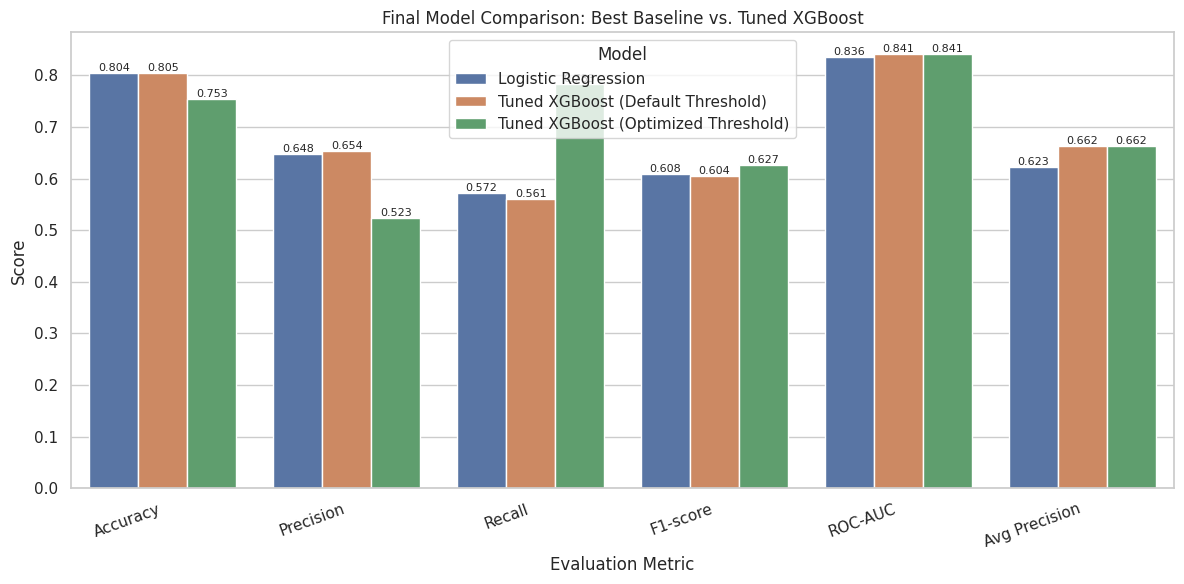

In [131]:
# Visual comparison of final candidate models
final_model_comparison_melted = final_model_comparison_df.melt(
    id_vars=["Model", "Threshold"],
    value_vars=["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "Avg Precision"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=final_model_comparison_melted, x="Metric", y="Score", hue="Model")

plt.title("Final Model Comparison: Best Baseline vs. Tuned XGBoost")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8)

if SAVE_FIGURES:
    plt.savefig(f"{FIGURES_DIR}/final_model_comparison.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

### Interpretation

The final comparison shows three important views of model performance:

1. **Logistic Regression** as the strongest simpler baseline
2. **Tuned XGBoost at the default threshold (0.50)** as the strongest probability-ranking model under standard classification rules
3. **Tuned XGBoost at the optimized threshold (0.30)** as the most recall-oriented and intervention-focused operating point

The comparison reveals a clear trade-off structure:

- **Logistic Regression** and **Tuned XGBoost (0.50)** are extremely close in standard threshold-based metrics
- **Tuned XGBoost (0.30)** sacrifices accuracy and precision, but produces substantially higher recall and the best F1-score
- **Tuned XGBoost** maintains the strongest **Average Precision (0.66)**, which confirms that it is the best model for ranking likely churners by risk

## 12.3 Final Model Selection Decision

The final selected model for this project is:

### **Tuned XGBoost**

However, the final decision should be interpreted in a nuanced way depending on the intended business objective.

Two valid operating views emerge:

1. **Default-threshold view (0.50)**  
   Tuned XGBoost performs similarly to Logistic Regression in threshold-based classification metrics, while offering stronger ranking quality.

2. **Optimized-threshold view (0.30)**  
   Tuned XGBoost becomes substantially more recall-oriented and achieves the best **F1-score** among the final candidates, making it more suitable for proactive churn intervention.

This means the final model is selected not only because of raw predictive strength, but because it combines:

- strong ranking performance
- strong interpretability
- flexible threshold behavior
- practical usefulness for churn targeting

In [132]:
# Summary table for the final selected model
final_selected_model_summary = pd.DataFrame([
    {
        "Selected Model": "Tuned XGBoost",
        "Chosen Threshold": 0.30,
        "Accuracy": 0.753,
        "Precision": 0.523,
        "Recall": 0.783,
        "F1-score": 0.627,
        "ROC-AUC": 0.841,
        "Avg Precision": 0.662
    }
])

display(final_selected_model_summary.round(4))

,Selected Model,Chosen Threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC,Avg Precision
0,Tuned XGBoost,0.30,0.75,0.52,0.78,0.63,0.84,0.66


### Interpretation

The final model selected for this project is:

### **Tuned XGBoost with an optimized threshold of 0.30**

This decision is based on the fact that the tuned XGBoost model offers the strongest overall combination of:

- competitive classification performance
- superior probability-ranking quality
- flexible threshold behavior
- business-aligned churn detection capability

At the default threshold of **0.50**, tuned XGBoost is already highly competitive with Logistic Regression and slightly stronger in ranking-oriented metrics. However, the more important finding is that once the threshold is optimized to **0.30**, the model becomes substantially more effective for proactive churn intervention.

This threshold-adjusted version is therefore the most useful final solution for a retention-focused business use case.

### Interpretation

The tuned XGBoost model was selected as the final model for four evidence-based reasons.

### 1. It matches the strongest baseline on core metrics
At the default threshold, tuned XGBoost achieves:

- **Accuracy = 0.81**
- **Precision = 0.65**
- **Recall = 0.56**
- **F1-score = 0.60**
- **ROC-AUC = 0.84**
- **Avg Precision = 0.66**

These values are extremely close to Logistic Regression, confirming that the advanced model is fully competitive in standard threshold-based classification.

### 2. It provides stronger churn-risk ranking quality
Tuned XGBoost achieves **Average Precision = 0.66**, compared with **0.62** for Logistic Regression. This is especially important in churn prediction, where the business often acts on ranked risk lists rather than on default binary labels alone.

### 3. It improves meaningfully after threshold optimization
At the optimized threshold of **0.30**, tuned XGBoost reaches:

- **Recall = 0.78**
- **F1-score = 0.63**

This makes it much more suitable for identifying likely churners in a proactive retention setting.

### 4. It remains interpretable and business-consistent
The feature importance analysis showed that the model’s most important signals are highly plausible and aligned with the earlier EDA, especially around:

- contract structure
- internet service type
- online security
- tech support
- payment and billing behavior

These results make tuned XGBoost not only strong, but also credible and actionable.

### Interpretation

The final operating recommendation depends on how the business intends to use the model.

### If the objective is churn-risk ranking:
Use **Tuned XGBoost** directly, because it delivers the strongest ranking-oriented performance, particularly in **Average Precision**.

### If the objective is retention targeting:
Use **Tuned XGBoost with a threshold of 0.30**, because this operating point produces:

- **Recall = 0.78**
- **F1-score = 0.63**
- a broader intervention pool
- much stronger identification of likely churners

This makes the model more suitable for proactive retention outreach, especially when the company is willing to contact more customers in exchange for catching many more true churners.

In practice, this means the tuned XGBoost model can support both:
- a **risk scoring workflow**
- a **binary intervention rule**
depending on the business need.

## 12.6 Final Selection Statement

Based on the full modeling workflow, the final selected solution for this project is:

### **Tuned XGBoost with an optimized classification threshold of 0.30**

This choice is justified by the following results:

- it remains highly competitive with the strongest baseline in standard classification metrics
- it achieves the strongest **Average Precision**
- it responds successfully to hyperparameter tuning
- it becomes substantially more effective for churn intervention after threshold optimization
- it is supported by a clear and business-consistent feature importance profile

As a result, tuned XGBoost at **0.30** is the most appropriate final model for a **retention-oriented churn prediction system** in this project.

## 12.7 Final Winner Snapshot

The final selected model is summarized below as a compact decision snapshot.

In [133]:
# Compact winner snapshot
winner_snapshot = pd.DataFrame({
    "Category": [
        "Final Model",
        "Threshold",
        "Best Use Case",
        "Key Strength",
        "Main Business Benefit"
    ],
    "Value": [
        "Tuned XGBoost",
        "0.30",
        "Retention targeting",
        "Highest recall-balanced performance",
        "Better identification of likely churners"
    ]
})

display(winner_snapshot)

,Category,Value
0,Final Model,Tuned XGBoost
1,Threshold,0.30
2,Best Use Case,Retention targeting
3,Key Strength,Highest recall-balanced performance
4,Main Business Benefit,Better identification of likely churners


### Interpretation

The final model selection process shows that the strongest churn prediction solution in this project is not simply the model with the best default-threshold accuracy, but the model that best balances:

- **ranking quality**
- **churn detection effectiveness**
- **interpretability**
- **business usefulness**

The final comparison shows:

- **Logistic Regression** remains an excellent and highly competitive baseline
- **Tuned XGBoost at 0.50** is equally competitive in standard metrics and stronger in ranking quality
- **Tuned XGBoost at 0.30** becomes the best intervention-oriented operating point, with the strongest recall-F1 balance

This makes the final selection clear:

### **Tuned XGBoost with a threshold of 0.30**

This solution is the strongest final choice because it combines:
- advanced model quality
- evidence-based tuning improvements
- improved threshold-based intervention performance
- and an interpretable business-consistent feature profile

In a real telecom retention setting, this model would be well suited for identifying likely churners early and supporting targeted intervention strategy.

# 13. Business Recommendations

A churn prediction model is most valuable when its results can be translated into concrete business action. The final tuned XGBoost model identifies customers at elevated risk of leaving, while the feature importance analysis highlights the factors most strongly associated with that risk.

The purpose of this section is to convert the analytical and modeling findings into actionable retention recommendations.

These recommendations are informed by:

- exploratory data analysis
- model benchmarking and final model selection
- threshold optimization
- feature importance and interpretability analysis

The goal is not only to predict churn, but to support better decision-making around customer retention strategy.

## 13.1 Strategic Summary of Model Insights

The modeling workflow identified several consistent churn-related themes:

- **contract structure** is the strongest driver of churn risk
- **fiber optic customers** appear more churn-prone than other internet-service groups
- customers without **OnlineSecurity** or **TechSupport** are at elevated risk
- **paperless billing** and certain **payment methods**, especially electronic check, are associated with higher churn
- customers with shorter **tenure** are especially vulnerable

These findings suggest that churn is driven not by a single factor, but by a combination of:

- weak contractual commitment
- service-experience friction
- limited support coverage
- billing/payment behavior
- early-stage customer fragility

## 13.2 Priority Retention Segments

Based on the final model and interpretability analysis, the following customer segments should be prioritized for retention efforts:

### 1. Month-to-month contract customers
This is the single most important churn-related segment in the dataset. Customers without long-term commitment are far more likely to leave and should be considered the highest-priority population for proactive retention programs.

### 2. Fiber optic customers
Although fiber optic is a premium service category, it is strongly associated with churn risk in both the EDA and the final model. This may indicate dissatisfaction with pricing, service quality, or value perception.

### 3. Customers without OnlineSecurity or TechSupport
The absence of support and security services is consistently linked to higher churn risk. These customers may be experiencing weaker perceived service value or greater frustration when issues occur.

### 4. Customers using electronic check or paperless billing
These billing-related patterns appear repeatedly in the churn analysis and may reflect less stable account behavior, less automation, or a more price-sensitive customer profile.

### 5. Early-tenure customers
Customers with short service histories are especially at risk, suggesting that the onboarding and early engagement period is a critical retention window.

## 13.3 Recommended Business Actions

The analysis suggests several targeted retention actions.

### A. Contract conversion strategy
Because contract structure is the strongest churn signal, the company should prioritize incentives that move high-risk customers away from month-to-month plans and toward longer-term agreements.

Possible actions:
- limited-time discounts for one-year upgrades
- bundled benefits for long-term contracts
- loyalty rewards tied to contract renewal

### B. Fiber optic customer experience review
Since fiber optic customers exhibit elevated churn risk, the business should investigate whether this segment is experiencing pricing dissatisfaction, quality issues, or unmet expectations.

Possible actions:
- segment-specific satisfaction surveys
- service-quality audits in fiber-heavy customer groups
- targeted retention offers for high-risk fiber customers

### C. Support and security upsell as retention tools
The model suggests that OnlineSecurity and TechSupport are not just product add-ons, but possible retention stabilizers.

Possible actions:
- offer temporary free trials of support/security services
- include TechSupport or OnlineSecurity in retention bundles
- use support-add-on promotions for customers flagged as medium-risk

### D. Billing and payment stabilization
Payment behavior appears to contain meaningful churn signal, especially around electronic check usage.

Possible actions:
- encourage migration to automatic payment methods
- simplify billing communication for high-risk segments
- test incentives for switching to more stable payment arrangements

### E. Early-tenure intervention program
Customers are most fragile early in their lifecycle, so retention should begin before dissatisfaction becomes entrenched.

Possible actions:
- onboarding check-ins during the first 30–90 days
- educational messages about service features and support options
- proactive outreach to customers with early usage or billing friction

## 13.4 How the Model Should Be Used Operationally

The final model can support two complementary business workflows:

### 1. Ranked churn-risk scoring
The tuned XGBoost model can be used to generate a ranked list of customers by churn probability. This is useful when the business wants to prioritize outreach to the highest-risk customers first.

### 2. Threshold-based targeting rule
Using the optimized threshold of **0.30**, the model can be used as a binary intervention tool to identify a broader set of customers who should be included in proactive retention campaigns.

The choice between these two workflows depends on operational capacity:

- if resources are limited, ranked targeting may be preferable
- if the business can support broader outreach, the optimized threshold provides a stronger churn-detection rule

## 13.5 Resource Allocation Implications

Threshold optimization showed that lowering the threshold from **0.50** to **0.30** increases recall substantially, but also expands the predicted churn population.

This has direct operational implications:

- at the default threshold, the company targets a smaller, more selective group
- at the optimized threshold, the company identifies many more likely churners, but must contact a larger segment

This means the retention team should align threshold choice with available capacity:

- **smaller outreach budget** → use ranked targeting or a higher threshold
- **broader retention capacity** → use the optimized threshold for stronger churn capture

In practice, the best operating policy may involve both:
- ranked prioritization for top-risk customers
- threshold-based inclusion for larger campaign planning

## 13.6 Risks and Cautions

Although the model is strong and interpretable, its recommendations should still be applied with care.

Important cautions include:

- The model identifies **associations**, not causal effects. For example, month-to-month contracts are strongly linked to churn, but that does not mean contract type alone causes all customer attrition.
- Some important features may act as proxies for broader customer experience issues not directly observed in the dataset.
- Threshold choice should reflect real retention costs and campaign capacity, not just statistical performance.
- The model should be monitored over time because churn dynamics may change as pricing, services, or customer behavior evolve.

For these reasons, the model should be treated as a decision-support tool rather than a fully automatic decision-maker.

## 13.6 Risks and Cautions

Although the model is strong and interpretable, its recommendations should still be applied with care.

Important cautions include:

- The model identifies **associations**, not causal effects. For example, month-to-month contracts are strongly linked to churn, but that does not mean contract type alone causes all customer attrition.
- Some important features may act as proxies for broader customer experience issues not directly observed in the dataset.
- Threshold choice should reflect real retention costs and campaign capacity, not just statistical performance.
- The model should be monitored over time because churn dynamics may change as pricing, services, or customer behavior evolve.

For these reasons, the model should be treated as a decision-support tool rather than a fully automatic decision-maker.

## 13.7 Final Recommendation Snapshot

The business recommendations from this project can be summarized as follows:

- prioritize **month-to-month customers** for retention action
- investigate the **fiber optic** segment for dissatisfaction or value gaps
- use **OnlineSecurity** and **TechSupport** as retention-oriented service levers
- stabilize billing behavior by encouraging more reliable **payment methods**
- focus retention effort especially on **early-tenure customers**
- operationalize the final model through **ranked risk scoring** and/or the **0.30 optimized threshold**

Taken together, these actions would allow the company to move from reactive churn response toward a more proactive and targeted retention strategy.

## 13.8 Recommendation Table

The table below summarizes the key business segments, associated churn risks, and suggested retention actions.

In [134]:
# ============================================================
# Optional summary table for business recommendations
# ============================================================

recommendation_table = pd.DataFrame([
    {
        "Segment / Driver": "Month-to-month contract customers",
        "Observed Risk Pattern": "Strongest churn-related signal in the model",
        "Suggested Action": "Promote longer-term contract conversion with incentives"
    },
    {
        "Segment / Driver": "Fiber optic customers",
        "Observed Risk Pattern": "Elevated churn relative to other internet-service groups",
        "Suggested Action": "Review pricing, perceived value, and service quality"
    },
    {
        "Segment / Driver": "Customers without OnlineSecurity",
        "Observed Risk Pattern": "Higher churn risk in both EDA and model importance",
        "Suggested Action": "Offer security add-ons in retention bundles"
    },
    {
        "Segment / Driver": "Customers without TechSupport",
        "Observed Risk Pattern": "Support absence is associated with elevated churn",
        "Suggested Action": "Promote support packages or service-assistance trials"
    },
    {
        "Segment / Driver": "Electronic check / unstable billing behavior",
        "Observed Risk Pattern": "Billing/payment behavior is associated with churn risk",
        "Suggested Action": "Encourage migration to automatic payment methods"
    },
    {
        "Segment / Driver": "Short-tenure customers",
        "Observed Risk Pattern": "Early-lifecycle customers are more vulnerable",
        "Suggested Action": "Strengthen onboarding and early-retention outreach"
    }
])

display(recommendation_table)

,Segment / Driver,Observed Risk Pattern,Suggested Action
0,Month-to-month contract customers,Strongest churn-related signal in the model,Promote longer-term contract conversion with i...
1,Fiber optic customers,Elevated churn relative to other internet-serv...,"Review pricing, perceived value, and service q..."
2,Customers without OnlineSecurity,Higher churn risk in both EDA and model import...,Offer security add-ons in retention bundles
3,Customers without TechSupport,Support absence is associated with elevated churn,Promote support packages or service-assistance...
4,Electronic check / unstable billing behavior,Billing/payment behavior is associated with ch...,Encourage migration to automatic payment methods
5,Short-tenure customers,Early-lifecycle customers are more vulnerable,Strengthen onboarding and early-retention outr...


### Interpretation

The final model does more than classify churn risk — it reveals where retention strategy should focus.

The analysis suggests that the company’s strongest retention levers are likely to be:

- **contract structure**
- **service quality and service support**
- **billing and payment behavior**
- **early customer lifecycle engagement**

The most important practical implication is that churn prevention should not be distributed evenly across the customer base. Instead, it should be concentrated on clearly identifiable high-risk segments, especially:

- month-to-month customers
- fiber optic customers
- customers without support/security services
- early-tenure customers
- customers with less stable billing/payment profiles

By combining the tuned XGBoost model with a business-aligned threshold and targeted action strategy, the company could build a more proactive and more efficient churn management system.

# 14. Final Conclusion

This project developed an end-to-end machine learning workflow for predicting telecom customer churn using the **Telco Customer Churn** dataset.

The analysis progressed through the full applied modeling pipeline:

- data cleaning and preprocessing
- exploratory data analysis
- baseline model benchmarking
- gradient boosting model development
- hyperparameter tuning
- threshold optimization
- feature importance interpretation
- business recommendation design

The result is not only a predictive churn model, but a practical retention-oriented analytical framework that can help guide customer intervention strategy.

## 14.1 Project Outcome Summary

The project set out to answer a clear business question:

> **Can customer churn be predicted accurately enough to support proactive retention strategy?**

The answer is **yes**.

The final workflow showed that churn in this dataset is both **predictable** and **interpretable**. Multiple models were evaluated, including Logistic Regression, Decision Tree, Random Forest, and XGBoost. Among them, **Logistic Regression** emerged as the strongest baseline, while **Tuned XGBoost** became the strongest advanced model after hyperparameter optimization.

Most importantly, threshold optimization demonstrated that the final model can be adapted to different business objectives. Using a lower classification threshold improved churn detection substantially and produced a more intervention-oriented operating point.

## 14.2 Final Model Conclusion

The final selected solution in this project is:

### **Tuned XGBoost with an optimized classification threshold of 0.30**

This model was selected because it combines:

- competitive classification performance
- strong probability-ranking quality
- improved recall-oriented intervention capability
- interpretable and business-consistent feature importance

At the optimized threshold, the final model achieved:

- **Accuracy = 0.75**
- **Precision = 0.52**
- **Recall = 0.78**
- **F1-score = 0.63**
- **ROC-AUC = 0.84**
- **Average Precision = 0.66**

These results make the final model especially suitable for **retention targeting**, where identifying likely churners is more important than maximizing accuracy alone.

## 14.3 Main Churn Drivers

The interpretability analysis showed that the strongest churn-related signals in the final model are concentrated in a small number of meaningful business variables.

The most important drivers include:

- **contract structure**, especially month-to-month contracts
- **internet service type**, particularly fiber optic
- absence of **OnlineSecurity**
- absence of **TechSupport**
- **paperless billing**
- **payment behavior**
- **customer tenure**

This is a strong and credible result because these same patterns also appeared earlier in the exploratory analysis. That consistency suggests that the final model is learning real customer-retention structure rather than arbitrary statistical noise.

## 14.4 Business Value of the Solution

From a business perspective, the final model offers two important capabilities:

### 1. Ranked churn-risk scoring
The tuned XGBoost model can rank customers by predicted churn probability, allowing the business to prioritize the highest-risk customers for intervention.

### 2. Threshold-based retention targeting
Using the optimized threshold of **0.30**, the model can identify a broader set of likely churners and support more proactive outreach campaigns.

This means the model can be used not only as a predictive tool, but as a practical decision-support system for:

- retention campaign design
- support allocation
- contract-conversion strategy
- customer success prioritization

## 14.5 Key Strategic Takeaway

The central strategic takeaway of this project is that **customer churn is not random**.

Instead, churn risk is strongly associated with:

- weak contractual commitment
- fragile early customer relationships
- service and support gaps
- billing and payment behavior

This means that a company can move beyond reactive churn response and toward a more proactive retention system by combining:

- predictive modeling
- targeted segmentation
- threshold-aware intervention rules
- business-informed service actions

## 14.6 Limitations and Next Steps

Although the project produced a strong and interpretable churn model, several natural next steps remain.

Possible extensions include:

- incorporating richer behavioral or service-interaction features
- estimating intervention cost and retention ROI explicitly
- testing segment-specific thresholds rather than one global threshold
- monitoring model drift over time
- deploying the model as an API or retention scoring service

These extensions would make the solution even closer to a production-ready churn management system.

## 14.7 Final Closing Statement

This project demonstrates that modern machine learning can be used not only to **predict** churn, but also to **understand** it and **act on it**.

By combining structured preprocessing, rigorous model comparison, tuned gradient boosting, threshold optimization, and business interpretation, the notebook delivers a complete applied machine learning case study that is both technically strong and operationally relevant.

In summary, the final solution shows that **Tuned XGBoost with a threshold of 0.30** provides the most effective retention-oriented churn prediction framework in this project.

## 14.8 Executive Summary

- **Objective:** Predict customer churn and support proactive retention
- **Best baseline:** Logistic Regression
- **Best advanced model:** Tuned XGBoost
- **Final operating threshold:** 0.30
- **Main churn drivers:** Contract, InternetService, OnlineSecurity, TechSupport, PaperlessBilling, PaymentMethod, tenure
- **Best use case:** Retention targeting and churn-risk prioritization